# [1] 사이킷런으로 시작하는 머신러닝

In [ ]:
pip install scikit-learn==1.0.2

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import sklearn

print(sklearn.__version__)

1.0.2


- 지도학습은 학습을 위한 다양한 **피처**와 분류 결정값인 **레이블** 데이터로 모델을 학습한 뒤,(Train set)
- 별도의 테스트 데이터 세트에서 미지의 레이블을 예측
- **하이퍼 파라미터** : 머신러닝 알고리즘별로 최적의 학습을 위해 직접 입력하는 파라미터

예측 프로세스
1. 데이터 세트 분리 : 데이터를 학습 데이터와 테스트 데이터로 분리
2. 모델 학습 : 학습 데이터를 기반으로 ML 알고리즘을 적용해 모델을 학습시킴
3. 예측 수행 : 학습된 ML 모델을 이용해 테스트 데이터의 분류를 예측
4. 평가 : 예측된 결괏값과 테스트 데이터의 실제 결괏값을 비교해 모델 성능 평가

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd

iris = load_iris()

iris_data = iris.data

iris_label = iris.target

iris_df = pd.DataFrame(data = iris_data, columns = iris.feature_names)
iris_df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [ ]:
# train 데이터와 test 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size = 0.2, random_state = 11)

In [ ]:
# DecisionTreeClassifier 생성
dt_clf = DecisionTreeClassifier(random_state = 11)

# 학습 수행
dt_clf.fit(X_train, y_train)

# 학습 완료된 DecisionTreeCalssifier 객체에서 테스트 데이터 세트로 예측 수행
pred = dt_clf.predict(X_test)

# 정확도 살펴보기
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.9333333333333333

## 1. 사이킷런 기반 프레임워크 익히기

- 모델 학습을 위해서 fit()
- 학습된 모델의 예측을 위해 predict() 메서드를 제공

- Classifier : 분류 알고리즘을 구현한 클래스
- Regressor : 회귀 알고리즘을 구현한 클래스
- Estimator : Classifier + Regressor

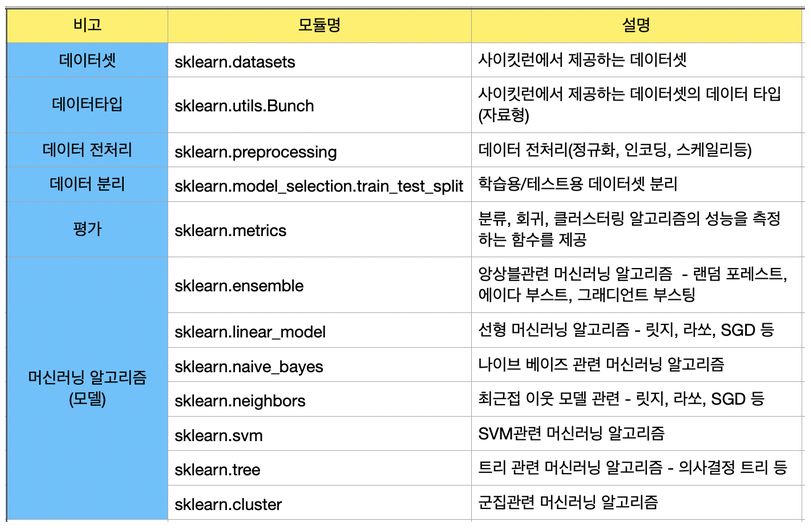

## 2. Model Selection 모듈 소개

학습/테스트 데이터 세트 분리 - train_test_split()
- test_size : 전체 데이터에서 테스트 데이터 세트 크기를 얼마로 샘플링 할 것인가를 결정
- shuffle : 데이터를 분리하기 전에 데이터를 미리 섞을지를 결정
- random_state : 호출할 때마다 동일한 학습/테스트용 데이터 세트를 생성하기 위해 주어지는 난수 값

### 교차 검증
- 과적합 : 모델이 학습 데이터에만 과도하게 최적화되어, 실제 예측을 다른 데이터로 수행할 경우 예측 성능이 과도하게 떨어지는 것을 말함
- 과적합 문제를 개선하기 위해 교차 검증을 이용해 다양한 학습과 평가 수행
- 교차 검증 : 데이터 편중을 막기 위해서 별도의 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습과 평가를 수행하는 것

### K 폴드 교차 검증
- 가장 보편적
- 먼저 K개의 데이터 폴드 세트를 만들어서 K번만큼 각 폴드 세트에 학습과 검증 평가를 반복적으로 수행하는 방법

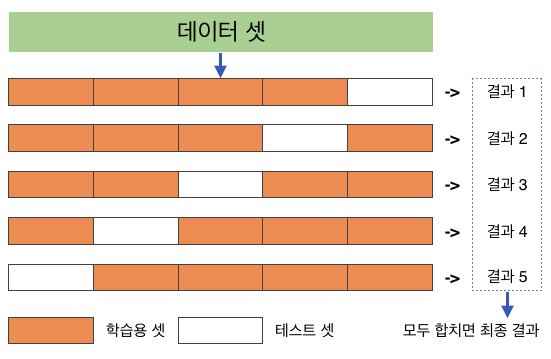

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state = 156)

kfold = KFold(n_splits = 5)
cv_accuracy = []
n_iter = 0

for train_index, test_index in kfold.split(features):
  X_train, X_test = features[train_index], features[test_index]
  y_train, y_test = label[train_index], label[test_index]

  dt_clf.fit(X_train, y_train)

  pred = dt_clf.predict(X_test)
  n_iter += 1

  accuracy = np.round(accuracy_score(y_test, pred), 4)
  train_size = X_train.shape[0]
  test_size = X_test.shape
  print(f'\n{n_iter} 교차 검증 정확도 : {accuracy}, 학습 데이터 크기 : {train_size}, 검증 데이터 크기 : {test_size}')

  cv_accuracy.append(accuracy)

print(f'\n## 평균 검증 정확도 : {np.mean(cv_accuracy)}')


1 교차 검증 정확도 : 1.0, 학습 데이터 크기 : 120, 검증 데이터 크기 : (30, 4)

2 교차 검증 정확도 : 0.9667, 학습 데이터 크기 : 120, 검증 데이터 크기 : (30, 4)

3 교차 검증 정확도 : 0.8667, 학습 데이터 크기 : 120, 검증 데이터 크기 : (30, 4)

4 교차 검증 정확도 : 0.9333, 학습 데이터 크기 : 120, 검증 데이터 크기 : (30, 4)

5 교차 검증 정확도 : 0.7333, 학습 데이터 크기 : 120, 검증 데이터 크기 : (30, 4)

## 평균 검증 정확도 : 0.9


### Stratified K 폴드
- 원본 데이터와 유사한 레이블 값의 분포를 학습/테스트 세트에도 유지하는 것이 중요함
- Stratified K 폴드는 레이블 데이터 집합이 원본 데이터 집합의 레이블 분포를 학습 및 테스트 세트에 제대로 분배하지 못하는 경우의 문제를 해결해줌
- StratifiedKFold는 레이블 데이터 분포도에 따라 학습/검증 데이터를 나누기 때문에 split() 메서드에 인자로 피처 데이터 세트 뿐만 아니라 레이블 데이터 세트도 반드시 필요함

In [ ]:
from sklearn.model_selection import StratifiedKFold

iris_df['label'] = iris.target

skf = StratifiedKFold(n_splits = 3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
  n_iter += 1
  label_train = iris_df['label'].iloc[train_index]
  label_test = iris_df['label'].iloc[test_index]
  print('## 교차 검증 :', n_iter)
  print('학습 레이블 데이터 분포 :\n', label_train.value_counts())
  print('검증 레이블 데이터 분포 :\n', label_test.value_counts())

## 교차 검증 : 1
학습 레이블 데이터 분포 :
 2    34
0    33
1    33
Name: label, dtype: int64
검증 레이블 데이터 분포 :
 0    17
1    17
2    16
Name: label, dtype: int64
## 교차 검증 : 2
학습 레이블 데이터 분포 :
 1    34
0    33
2    33
Name: label, dtype: int64
검증 레이블 데이터 분포 :
 0    17
2    17
1    16
Name: label, dtype: int64
## 교차 검증 : 3
학습 레이블 데이터 분포 :
 0    34
1    33
2    33
Name: label, dtype: int64
검증 레이블 데이터 분포 :
 1    17
2    17
0    16
Name: label, dtype: int64


- 일반적으로 분류(Classification)엣의 교차 검증은 Stratified K 폴드로 분할돼야 함
- 회귀(Regression)에서는 Stratified K 폴드가 지원되지 않음
- 회귀의 결정값은 이산값 형태의 레이블이 아니라 연속된 숫자값이기 때문에 결정값별로 분포를 정하는 의미가 없기 때문임

### 교차 검증을 보다 간편하게 - cross_val_score()
- 교차 검증을 편리하게 수행할 수 있게 해주는 API

*cross_val_score(estimator, X, y = None, cv = None, n_jobs = 1, verbose = 0, fit_params = None, pre_dispatch = '2*n_jobs')*

- estimator, X, y, scoring, cv가 주요 파라미터임

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate

score = cross_val_score(dt_clf, iris.data, iris.target, scoring = 'accuracy', cv = 3)
score

array([0.98, 0.94, 0.98])

### GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에
- 사이킷런은 GridSearchCV API를 이용해 Classifier나 Regressor와 같은 알고리즘에 사용되는 하이퍼 파라미터를 순차적으로 입력하면서 편리하게 최적의 파라미터를 도출할 수 있는 방안을 제공함


In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size = 0.2, random_state = 121)

dtree = DecisionTreeClassifier()

parameters = {'max_depth' : [1, 2, 3], 'min_samples_split' : [2, 3]}

import pandas as pd

grid_dtree = GridSearchCV(dtree, param_grid = parameters, cv = 3, refit = True)

grid_dtree.fit(X_train, y_train)

scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000972,0.000382,0.000354,0.000091,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.700,0.7,0.70,0.700000,1.110223e-16,5
1,0.000481,0.000022,0.000243,0.000002,1,3,"{'max_depth': 1, 'min_samples_split': 3}",0.700,0.7,0.70,0.700000,1.110223e-16,5
2,0.000466,0.000006,0.000270,0.000016,2,2,"{'max_depth': 2, 'min_samples_split': 2}",0.925,1.0,0.95,0.958333,3.118048e-02,3
3,0.000498,0.000010,0.000250,0.000008,2,3,"{'max_depth': 2, 'min_samples_split': 3}",0.925,1.0,0.95,0.958333,3.118048e-02,3
4,0.000479,0.000011,0.000242,0.000001,3,2,"{'max_depth': 3, 'min_samples_split': 2}",0.975,1.0,0.95,0.975000,2.041241e-02,1
5,0.000471,0.000007,0.000269,0.000003,3,3,"{'max_depth': 3, 'min_samples_split': 3}",0.975,1.0,0.95,0.975000,2.041241e-02,1


## 3. 데이터 전처리

- Garbage in Garbage out
- 결손값(NaN, Null)은 허용되지 않음
- 문자열 값을 입력값으로 허용하지 않음
- 카테고리형 피어 -> 코드 값으로 표현
- 텍스트형 피처 -> 피처 벡터화 or 삭제

### 데이터 인코딩

- 레이블 인코딩과 원-핫 인코딩이 있음

레이블 인코딩
- 카테고리 피처를 코드형 숫자값으로 변환하는 것
- 몇몇 알고리즘에서 숫자 값이 크고 작음에 대한 특성이 작용해 가중치를 부여하면서 예측 성능이 떨어질 수 있음

In [ ]:
from sklearn.preprocessing import LabelEncoder

items = ['TV', 'Refigerator', 'computer', 'fan', 'blender']

encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
labels

array([1, 0, 3, 4, 2])

원-핫 인코딩
- 피처 값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지 칼럼에는 0을 표시하는 방식
- 입력값으로 2차원 데이터가 필요함
- 변환값이 희소 행렬형태이므로 다시 toarray() 메서드를 이용해 밀집 행렬로 반환해야 함

In [ ]:
from sklearn.preprocessing import OneHotEncoder

items = ['TV', 'Refigerator', 'computer', 'fan', 'blender']

# 2차원 array로 변환
items = np.array(items).reshape(-1, 1)

oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

oh_labels.toarray()

array([[0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.]])

In [ ]:
# pandas에서는 원핫 인코딩을 get_dummies()를 사용해 나타낼 수 있음
import pandas as pd

df = pd.DataFrame({'item' : ['TV', 'Refigerator', 'computer', 'fan', 'blender']})

pd.get_dummies(df)

,item_Refigerator,item_TV,item_blender,item_computer,item_fan
0,0,1,0,0,0
1,1,0,0,0,0
2,0,0,0,1,0
3,0,0,0,0,1
4,0,0,1,0,0


### 피처 스케일링과 정규화
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 **피처 스케일링**이라고 함
- 대표적인 방법으로 표준화(Standardization)와 정규화(Normalization)이 있음

표준화
- 데이터의 피처 각각이 평균이 0이고 분산이 1인 가우시안 정규 분포를 가진 값으로 변환하는 것을 의미함

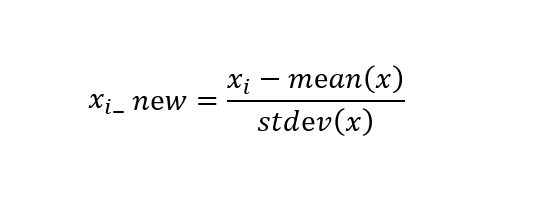

정규화
- 서로 다른 피처의 크기를 통일하기 위해 크기를 변환해주는 개념

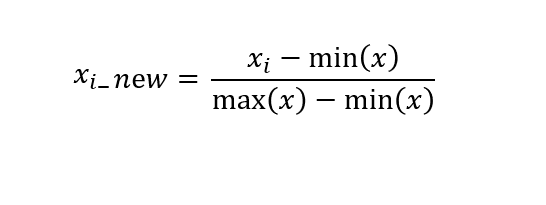

사이킷런 Normalizer
- 선형대수의 정규화 개념이 이용됐으며, 개별 벡터의 크기를 맞추기 위해 변환하는 것을 의미

### StandardScaler
- 개별 피처를 평균이 0이고 분산이 1인 값으로 변환해줌

In [ ]:
iris = load_iris()
features = iris.data
iris_df = pd.DataFrame(data = features, columns = iris.feature_names)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df
                                  )
iris_df_scaled = pd.DataFrame(iris_scaled, columns = iris.feature_names)
iris_df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


### MinMaxScaler
- 데이터값을 0과 1 사이의 범위 값으로 변환함

In [ ]:
lambda x : (x - min(a)) / (max(a) - min(a))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data = iris_scaled, columns = iris.feature_names)
iris_df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


### 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

- 일반적으로 fit()은 데이터 변환을 위한 기준 정보 설정을 적용하며, transform()은 이렇게 설정된 정보를 이용해 데이터를 변환함
- fit_transform()은 fit()과 transform()을 한 번에 적용

- Scaler 객체를 이용해 학습 데이터 세트로 fit()과 transform()을 적용하면 테스트 데이터 세트로는 다시 fit()을 수행하지 않고 학습 데이터 세트로 fit()을 수행한 결과를 이용해 transform() 변환을 적용해야 함
- 그렇지 않으면 학습 데이터와 테스트 데이터의 스케일링 기분 정보가 서로 달라지기 때문에 올바른 예측 결과를 도출하지 못함

1. 가능하다면 전체 데이터의 스케일링 변환을 적용한 뒤 학습과 데이터 세트로 분리

2. 1이 여의치 않다면 테스트 데이터 변환 시에는 fit()이나 fit_transform()을 적용하지 않고 학습 데이터로 이미 fit()된 Scaler 객체를 이용해 transform()으로 변환

# [2] 평가

머신러닝 모델은 여러 가지 방법으로 예측 성능을 평가할 수 있음

성능 평가 지표(Evaluation Matrix)는 일반적으로 모델이 분류냐 회귀냐에 따라 여러 종류로 나뉨
- 예측 오차를 가지고 정규화 수준을 재가공하는 방법이 회귀의 성능 평가 지표 유형
- 분류도 비슷하지만 단순히 정확도에만 의존하면 안됨


분류의 성능 평가 지표
- 정확도(Accuracy)
- 오차 행렬(Confusion Matrix)
- 정밀도(Precision)
- 재현율(Recall)
- F1 Score
- ROC AUC

분류는 결정 클래스 값 종류의 유형에 따라 긍정/부정과 같은 2개의 결괏값만 가지는 이진 분류와 여러 개의 결정 클래스 값을 가지는 멀티 분류로 나뉠 수 있음

## 1. 정확도(Accuracy)

- 정확도는 실제 데이터에서 예측 데이터가 얼마나 같은지를 판단하는 지표
- 정확도(Accuracy) = 예측 결과가 동일한 데이터 건수 / 전체 예측 데이터 건수

In [ ]:
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
  def fit(self, X, y = None):
    pass

  def predict(self, X):
    pred = np.zeros((X.shape[0], 1))
    for i in range(X.shape[0]):
      if X['Sex'].iloc[i] == 1:
        pred[i] = 0
      else:
        pred[i] = 1

    return pred

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

titanic_df = pd.read_csv('titanic_train.csv')

y_label = titanic_df['Survived']
X_features = titanic_df.drop('Survived', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = 0.2, random_state = 0)

myclf = MyDummyClassifier()
myclf.fit(X_train, y_test)

pred = myclf.predict(X_test)

accuracy_score(y_test, pred)

0.3854748603351955

- **정확도 평가 지표는 불균형한 레이블 데이터 세트에서는 성능 수치로 사용돼서는 안됨**
- 정확도가 가지는 분류 평가 지표로서 갖는 한계점을 극복하기 위해 겨러 가지 분류 지표와 함께 적용하여 ML 모델 성능을 평가해야 함

## 2. 오차 행렬(Confusion Matrix)

- 오차행렬은 학습된 분류 모델이 예측을 수행하면서 얼마나 헷갈리고 있는 지도 함께 보여주는 지표
- 이진 분류의 예측 오류가 얼마인지와 더불어 어떠한 유형의 예측 오류가 발생하고 있는지를 함께 나타냄

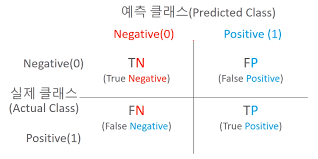

정확도 = 예측 결과와 실제 값이 동일한 건수 / 전체 데이터 건수 = (TN + TP) / (TN + FN + TP + FP)


- 불균형한 이진 분류 데이터 세트에서는 Positive 데이터 건수가 매우 작기 때문에 데이터에 기반한 ML 알고리즘은 Positive보다 Negative로 예측 정확도가 높아지는 경향 발생함
- 결과적으로 정확도 지표는 비대칭한 데이터 세트에서 Positive에 대한 예측 정확도를 판단하지 못한 채 Negative에 대한 예측 정확도만으로도 분류의 정확도가 매우 높게 나타나는 수치적인 판단 오류를 일으키게 됨

## 3. 정밀도와 재현율

- 정밀도와 재현율은 Positive 데이터 세트의 예측 성능에 좀 더 초점을 맞춘 평가 지표

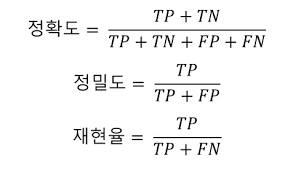

정밀도 - 사이킷런( precision_score() )
- 예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율
- 양성 예측도

재현율 - 사이킷런( recall_score() )
- 실제 값이 Positive인 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율을 뜻함
- 민감도 / TPR(True Positive Rate)

- 재현율이 중요 지표인 경우는 실제 Positive 양성 데이터를 Negative로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우임(보험 사기)
- 정밀도가 더 중요한 지표인 경우는 실제 Negative 음성 데이터를 Positive로 잘못 판단하면 안되는 경우(스팸메일 판단)

재현율과 정밀도 모두 TP를 높이는 데 동일하게 초점을 맞춤
- 재현율은 FN을 낮추는 데
- 정밀도는 FP를 낮추는 데 초점을 맞춤

이와 같은 특성 때문에 재현율과 정밀도는 서로 보완적인 지표로 분류의 성능을 얻음

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  print('오차행렬')
  print(confusion)
  print(f'정확도 : {accuracy}, 정밀도 : {precision}, 재현율 : {recall}')

In [ ]:
from sklearn.preprocessing import LabelEncoder

def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace = True)
    df['Cabin'].fillna('N', inplace = True)
    df['Embarked'].fillna('N', inplace = True)
    df['Fare'].fillna('N', inplace = True)
    return df

def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)
    return df

def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

titanic_df = pd.read_csv('titanic_train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis = 1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size = 0.2, random_state = 0)

lr_clf = LogisticRegression(solver = 'liblinear')

lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

get_clf_eval(y_test, pred)

오차행렬
[[93 17]
 [20 49]]
정확도 : 0.7932960893854749, 정밀도 : 0.7424242424242424, 재현율 : 0.7101449275362319


### 정밀도/재현율 트레이드오프

- 분류하려는 업무의 특성상 정밀도 또는 재현율이 특별히 강조돼야 할 경우 분류의 결정 임곗값을 조정해 정밀도 또는 재현율을 수치를 높일 수 있음|
- 하지만 정밀도와 재현율은 상호 보완적인 평가 지표이기 때문에 어느 한 쪽을 강제로 높인다면 다른 하나의 수치는 떨어지기 쉬움
- 이를 정밀도/재현율의 트레이드오프(trade-off)라고 함


- 사이킷런의 분류 알고리즘은 예측 데이터가 특정 레이블에 속하는 지를 계산하기 위해 먼저 개별 레이블별로 결정 확률을 구함
- 예측 확률이 큰 레이블값으로 예측
- 예를 들어 0일 확률 10%, 1일 확률 90%면 1로 예측

In [ ]:
# predict_proba : 개별 데이터별로 예측 확률을 반환하는 메서드
import numpy as np

pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis = 1)
pred_proba_result[:10]

array([[0.85157347, 0.14842653, 0.        ],
       [0.87164664, 0.12835336, 0.        ],
       [0.9239038 , 0.0760962 , 0.        ],
       [0.08235587, 0.91764413, 1.        ],
       [0.35114951, 0.64885049, 1.        ],
       [0.58232183, 0.41767817, 0.        ],
       [0.08988965, 0.91011035, 1.        ],
       [0.07387902, 0.92612098, 1.        ],
       [0.53027821, 0.46972179, 0.        ],
       [0.340053  , 0.659947  , 1.        ]])

- [0일 확률, 1일 확률, 결과]
- 0일 확률이 높으면 0/ 1일 확률이 높으면 1로 결과 나옴

사이킷런은 분류 결정 임계값을 조절해 정밀도와 재현율의 성능 수치를 상호 보완적으로 조정할 수 있음

In [ ]:
from sklearn.preprocessing import Binarizer

# Binarizer의 threshold 설정값. 분류 결정 임계값
custom_threshold = 0.5

# predict_proba() 반환값의 두 번째 칼럼, 즉 Positive 클래스 칼럼 하나만 추출해 Binarizer를 적용
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차행렬
[[93 17]
 [20 49]]
정확도 : 0.7932960893854749, 정밀도 : 0.7424242424242424, 재현율 : 0.7101449275362319


In [ ]:
custom_threshold = 0.4
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차행렬
[[87 23]
 [14 55]]
정확도 : 0.7932960893854749, 정밀도 : 0.7051282051282052, 재현율 : 0.7971014492753623


- 임곗값을 낮추니 재현율이 올라가고 정밀도 떨어짐
- 분류 결정 임계값은 Positive 예측값을 결정하는 확률의 기준임

- Positive 예측을 너그럽게 하기 때문에 임계값을 낮출수록 True 값이 많아짐
- Positive 예측값이 많아지면 상대적으로 재현율 값이 높아짐
- 양성 예측을 많이 하다보니 실제 양성을 음성으로 예측하는 횟수가 상대적으로 줄어들기 때문임




- 임곗값이 0.5에서 0.4로 낮아지면서
- TP가 47에서 50으로 늘었고
- FN이 14에서 11로 줄어듦


- 재현율이 0.770에서 0.820으로 좋아짐
- 정밀도는 0.825에서 0.704로 나빠짐
- 정확도도 0.866에서 0.821로 나빠짐

In [ ]:
# 테스트를 수행할 모든 임곗값을 리스트 객체로 저장
thresholds = [0.4, 0.45, 0.50, 0.55, 0.6]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    #thresholds list객체 내의 값을 차례로 iteration 하면서 Evaluation 수행
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값: ', custom_threshold)
        get_clf_eval(y_test, custom_predict)


get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임곗값:  0.4
오차행렬
[[87 23]
 [14 55]]
정확도 : 0.7932960893854749, 정밀도 : 0.7051282051282052, 재현율 : 0.7971014492753623
임곗값:  0.45
오차행렬
[[91 19]
 [18 51]]
정확도 : 0.7932960893854749, 정밀도 : 0.7285714285714285, 재현율 : 0.7391304347826086
임곗값:  0.5
오차행렬
[[93 17]
 [20 49]]
정확도 : 0.7932960893854749, 정밀도 : 0.7424242424242424, 재현율 : 0.7101449275362319
임곗값:  0.55
오차행렬
[[98 12]
 [23 46]]
정확도 : 0.8044692737430168, 정밀도 : 0.7931034482758621, 재현율 : 0.6666666666666666
임곗값:  0.6
오차행렬
[[101   9]
 [ 26  43]]
정확도 : 0.8044692737430168, 정밀도 : 0.8269230769230769, 재현율 : 0.6231884057971014


- 임곗값이 0.45일 때 디폴트 0.5인 경우와 비교해서 정확도는 동일하고 정밀도는 약간 떨어졌으며 재현율이 오름
- 재현율을 향상시키면서 다른 수치를 어느 정도 감소한느 희생을 해야 한다면 임곗값 0.45가 가장 적당

In [ ]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
print('반환된 분류 결정 임곗값 배열의 shape: ', thresholds.shape)

# 반환된 임곗값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 step으로 추출
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임곗값 배열의 index 10개: ', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도 : ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율 : ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 shape:  (166,)
샘플 추출을 위한 임곗값 배열의 index 10개:  [  0  15  30  45  60  75  90 105 120 135 150 165]
샘플용 10개의 임곗값:  [0.08 0.12 0.13 0.16 0.19 0.26 0.42 0.54 0.65 0.76 0.87 0.96]
샘플 임계값별 정밀도 :  [0.399 0.418 0.478 0.52  0.585 0.659 0.711 0.754 0.87  1.    1.    1.   ]
샘플 임계값별 재현율 :  [1.    0.957 0.957 0.928 0.899 0.87  0.783 0.667 0.58  0.449 0.232 0.014]


- 추출된 임계값 샘플 10개에 해당하는 정밀도 값과 재현율 값을 살펴보면 임계값이 증가할수록 정밀도 값은 동시에 높아지거나 재현율 값은 낮아짐


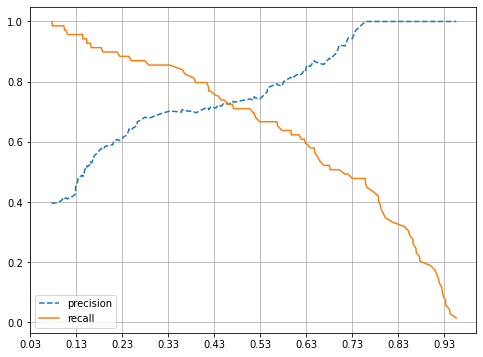

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    # X축을 threshold 값으로 Y축은 정밀도, 재현율 값으로 각각 plot 수행, 정밀도는 점선으로 표시
    plt.figure(figsize = (8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle = '--', label = 'precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label = 'recall')

    # threshold 값 X축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.legend();plt.grid()
    plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

- 정밀도는 점선 / 재현율은 실선
- 임계값이 낮을수록 많은 수의 양성 예측으로 인해 재현율의 값이 극도로 높아지고 정밀도 값이 극도로 낮아짐

### 정밀도와 재현율의 맹점
- Positive 예측의 임곗값을 변경함에 따라 정밀도와 재현율의 수치가 변경됨
- 이러한 변경은 업무 환경에 맞게 두 개의 수치를 상호 보완할 수 있는 수준에서 적용돼야 함
- 단순히 하나의 성능 지표 수치를 높이기 위한 수단으로 사용되어서는 안됨


<정밀도가 100%가 되는 방법>
- 확실한 기준이 되는 경우만 Positive로 예측하고 나머지는 모두 Negative으로 예측


<재현율이 100%가 되는 방법>
- 모든 환자를 Positive로 예측

## 4. F1 스코어

- F1 Score는 정밀도와 재현율을 결합한 지표
- F1 스코어는 정밀도와 재현율이 어느 한 쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가짐
- 높을수록 좋음

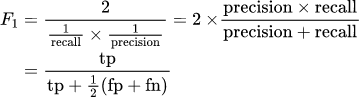

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, pred)
f1

0.725925925925926

## 5. ROC 곡선과 AUC

- ROC 곡선 = 수신자 판단 곡선
- ROC 곡선은 FPR(False Positive Rate)이 변할 때 TPR(True Positive Rate/재현율/민감도)이 어떻게 변하는지를 나타내는 곡선임


- 민감도(TPR)는 실제값 Positive가 정확히 예측돼야 하는 수준을 나타냄(질병이 있는 사람은 질병이 있는 것으로 양성 판정)


- 특이성(TNR)은 실제값 Negative가 정확히 예측돼야 하는 수준을 나타냄(질병이 없는 건강한 사람은 질병이 없는 것으로 판정)



> TNR(특이성) = TN / (FN + TN)

> FPR = FP / (FP + TN) = 1 - TNR = 1 - 특이성






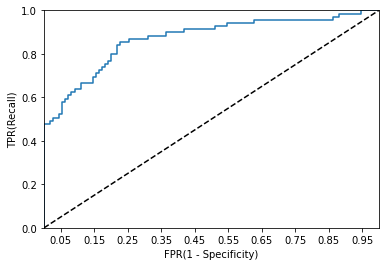

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


def roc_curve_plot(y_test, pred_proba_c1):
    # 임계값에 따른 FPR, TPR 값을 반환받음
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)

    #ROC 곡선을 그래프 곡선으로 그림
    plt.plot(fprs, tprs, label = 'ROC')

    #가운데 대각선 직선을 그림
    plt.plot([0, 1], [0, 1], 'k--', label = 'Random')

    # FBR X 축의 Scale을 0.1 단위로 변경, X, Y축 명 설정 등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('FPR(1 - Specificity)');plt.ylabel('TPR(Recall)')
    plt.legend

roc_curve_plot(y_test, pred_proba[:, 1])

- 가운데 직선은 ROC 곡선의 최저 값
- 왼쪽 하단과 오른쪽 상단을 대각선으로 이은 직선은 동전을 무작위로 던져 앞/뒤를 맞추는 랜덤 수준의 이진 분류의 ROC 직선임


- ROC 곡선이 가운데 직선에 가까울수록 성능이 떨어지는 것이며, 멀어질수록 성능이 뛰어난 것임
- 분류 결정 임계값을 변경해 FPR을 0부터 1까지 변경할 수 있음


- FPR을 0으로 만드려면 임곗값을 1로 지정하면 됨
- 임곗값을 1로 지정하면 Positive 예측 기준이 매우 높기 때문에 분류기가 임곗값보다 높은 확률을 가진 데이터를 Positive로 예측할 수 없음


> FPR = FP / (FP + TN)


- 아예 Positive로 예측하지 않기 때문에 FP 값이 0이 되므로 FPR은 0이 됨
- 반대로 FPR를 1로 만드려면 TN을 0으로 만들면 됨
- TN을 0으로 만드려면 분류 결정 임곗값으 0으로 지정하면 됨


- 임곗값을 1부터 0까지 변화시키면서 FPR을 구하고 이 FPR 값의 변화에 따른 TPR 값을 구하는 것이 ROC 곡선임
- 일반적으로 ROC 곡선 자체는 FPR과 TPR의 변화 값을 보는 데 이용하면 분류의 성능 지표로 사용되는 것은 ROC 곡선 면적에 기반한 AUC 값으로 결정됨
- AUC(Area Under Curve)값은 ROC 곡선 밑의 면적을 구한 것으로 일반적으로 1에 가까울수록 좋은 수치임

In [ ]:
from sklearn.metrics import roc_curve

pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

thr_index = np.arange(1, thresholds.shape[0], 5)

print(np.round(fprs[thr_index], 3))
print(np.round(tprs[thr_index], 3))

[0.    0.027 0.064 0.082 0.145 0.164 0.191 0.218 0.309 0.418 0.527 0.682
 0.864 1.   ]
[0.014 0.507 0.58  0.623 0.667 0.725 0.754 0.841 0.87  0.913 0.928 0.957
 0.971 1.   ]


In [ ]:
from sklearn.metrics import roc_auc_curve

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_curve(y_test, pred_proba)
roc_score

# [3] 분류

- 지도학습 : 레이블(명시적인 정답)이 있는 데이터가 주어진 상태에서 학습하는 머신러닝 방식
- **분류(Classification)** : 학습 데이터로 주어진 데이터의 피처와 레이블값을 머신러닝 알고리즘으로 학습해 모델을 생성하고, 이렇게 생성된 모델에 새로운 데이터 값이 주어졌을 때 미지의 레이블 값을 예측하는 것
- 즉, 기존 데이터가 어떤 레이블에 속하는지 패턴을 알고리즘으로 인지한 뒤에 새롭게 관측된 데이터에 대한 레이블을 판별하는 것

- 앙상블 방법(Ensemble Method)은 분류에서 가장 각광 받는 방법 중 하나(정형 데이터 예측)
- 앙상블을 서로 다른/또는 같은 알고리즘을 단순히 결합한 형태도 있으나
- 일반적으로 **배깅(Bagging)**과 **부스팅(Boosting)** 방식으로 나뉨
- 스태킹(Stacking) : 앙상블의 앙상블



> - 배깅 : 랜덤 포레스트

> - 부스팅 : 그래디언트 부스팅, XGBoost, LightGBM


앙상블의 기본 알고리즘으로 일반적으로 사용하는 것은 결정 트리임
- 결정 트리는 매우 쉽고 유연하게 적용될 수 있는 알고리즘으로 사전 가공의 영향도 적음
- 예측 성능 향상을 위해 복잡한 규칙 구조 필요로하나 과적합 문제 발생할 수 있음


앙상블은 매우 많은 여러 개의 학습기(예측 성능이 상대적으로 떨어지는 학습 알고리즘)를 결합해 확률적 보완과 오류가 발생한 부분에 대한 가중치를 계속 업데이터하면서 예측 성능을 향상시킴
- 결정 트리가 좋은 약한 학습기가 됨

## 1. 결정트리

- ML 알고리즘 중 직관적으로 이해하기 쉬운 알고리즘
- 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리 기반의 분류 규칙을 만드는 것

> - 규칙 노드(Decision Node) : 규칙 조건

> - 리프 노드(Leaf Node) : 결정된 클래스 값

> - 새로운 규칙 조건마다 서브 트리(Sub Tree)가 생성됨

- 데이터 세트에 피처가 있고 이러한 피처가 결합해 규칙 조건을 만들 때마다 규칙 노드가 만들어짐

- 많은 규칙이 있다는 것은 분류를 결정하는 방식이 더욱 복잡해진다는 얘기이며, 이는 곧 과적합으로 이어지기 쉬움

- 트리의 깊이(depth)가 깊어질수록 결정 트리의 예측 성능이 저하될 가능성이 높음

- 가능한 한 적은 결정 노드로 높은 예측 정확도를 가지려면 데이터를 분류할 때 최대한 많은 데이터 세트가 해당 분류에 속할 수 있도록 결정 노드의 규칙이 정해져야 함
- 최대한 균일한 데이터 세트를 구성할 수 있도록 분할하는 것이 필요함


- 데이터 세트의 균일도는 데이터를 구분하는 데 필요한 정보의 양에 영향을 미침
- 결정 노드는 정보 균일도가 높은 데이터 세트를 먼저 선택할 수 있도록 규칙 조건을 만듦


- 정보 균일도를 측정하는 대표적인 방법은 엔트로피를 이용한 정보이득(Information Grain) 지수와 지니 계수가 있음


### 엔트로피와 지니계수
- 정보 이득은 엔트로피라는 개념을 기반으로 함. **엔트로피**는 주어진 데이터 집합의 혼잡도를 의미하는데, 서로 다른 값이 섞여 있으면 엔트로피가 높고, 같은 값이 섞여 있으면 엔트로피가 낮음. **정보이득지수**는 1에서 엔트로피 지수를 뺀 값으로 **1 - 엔트로피 지수**임. 결정 트리는 이 정보 이즉 지수로 분할 기준을 정함. 즉, 정보 이득이 높은 속성을 기준으로 분할함
- **지니 계수**는 불평등 지수를 나타낼 때 사용하는 계수. 0이 가장 평등하고 1로 갈수록 불평등함. 머신러닝에 적용될 때는 **지니 계수가 낮을수록 데이터 균일도가 높은 것**으로 해석해 지니 계수가 낮은 속성을 기준으로 분할함


### 결정 트리 모델의 특징
- 균일도를 기반으로 해서 알고리즘이 쉽고 직관적임
- 결정 트리가 룰이 매우 명확하고, 이에 기반해 어떻게 규칙 노드와 리프 노드가 만들어지는 지 알 수 있고, 시각화도 가능함
- 특별한 경우 제외하고 각 피처의 스케일링과 정규화 같은 전처리 작업이 필요 없음


- 반면에 과적합으로 정확도가 떨어질 수 있음
- 피처 정보의 균일도에 따른 룰 규칙으로 서브 트리를 계속 만들다 보면 피처가 많고 균일도가 다양하게 존재할수록 트리의 깊이가 깊어지고 복잡해짐
-트리의 크기를 사전에 제한하는 것이 오히려 성능 튜닝에 더 도움이 됨

### 결정 트리 파라미터

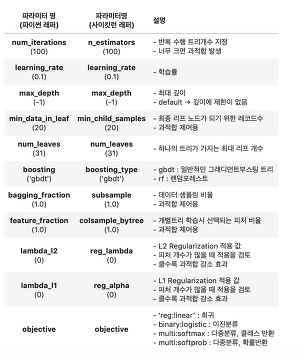

### 결정 트리 모델의 시각화
- Graphviz
- graphviz는 홈페이지 들어가서 별도로 설치 후에 pip install 해야 함
- 홈페이지 참조


In [ ]:
# import graphviz

# with open('tree.dot') as f:
#     dot_graph = f.read()

# graphviz.Source(dot_graph)


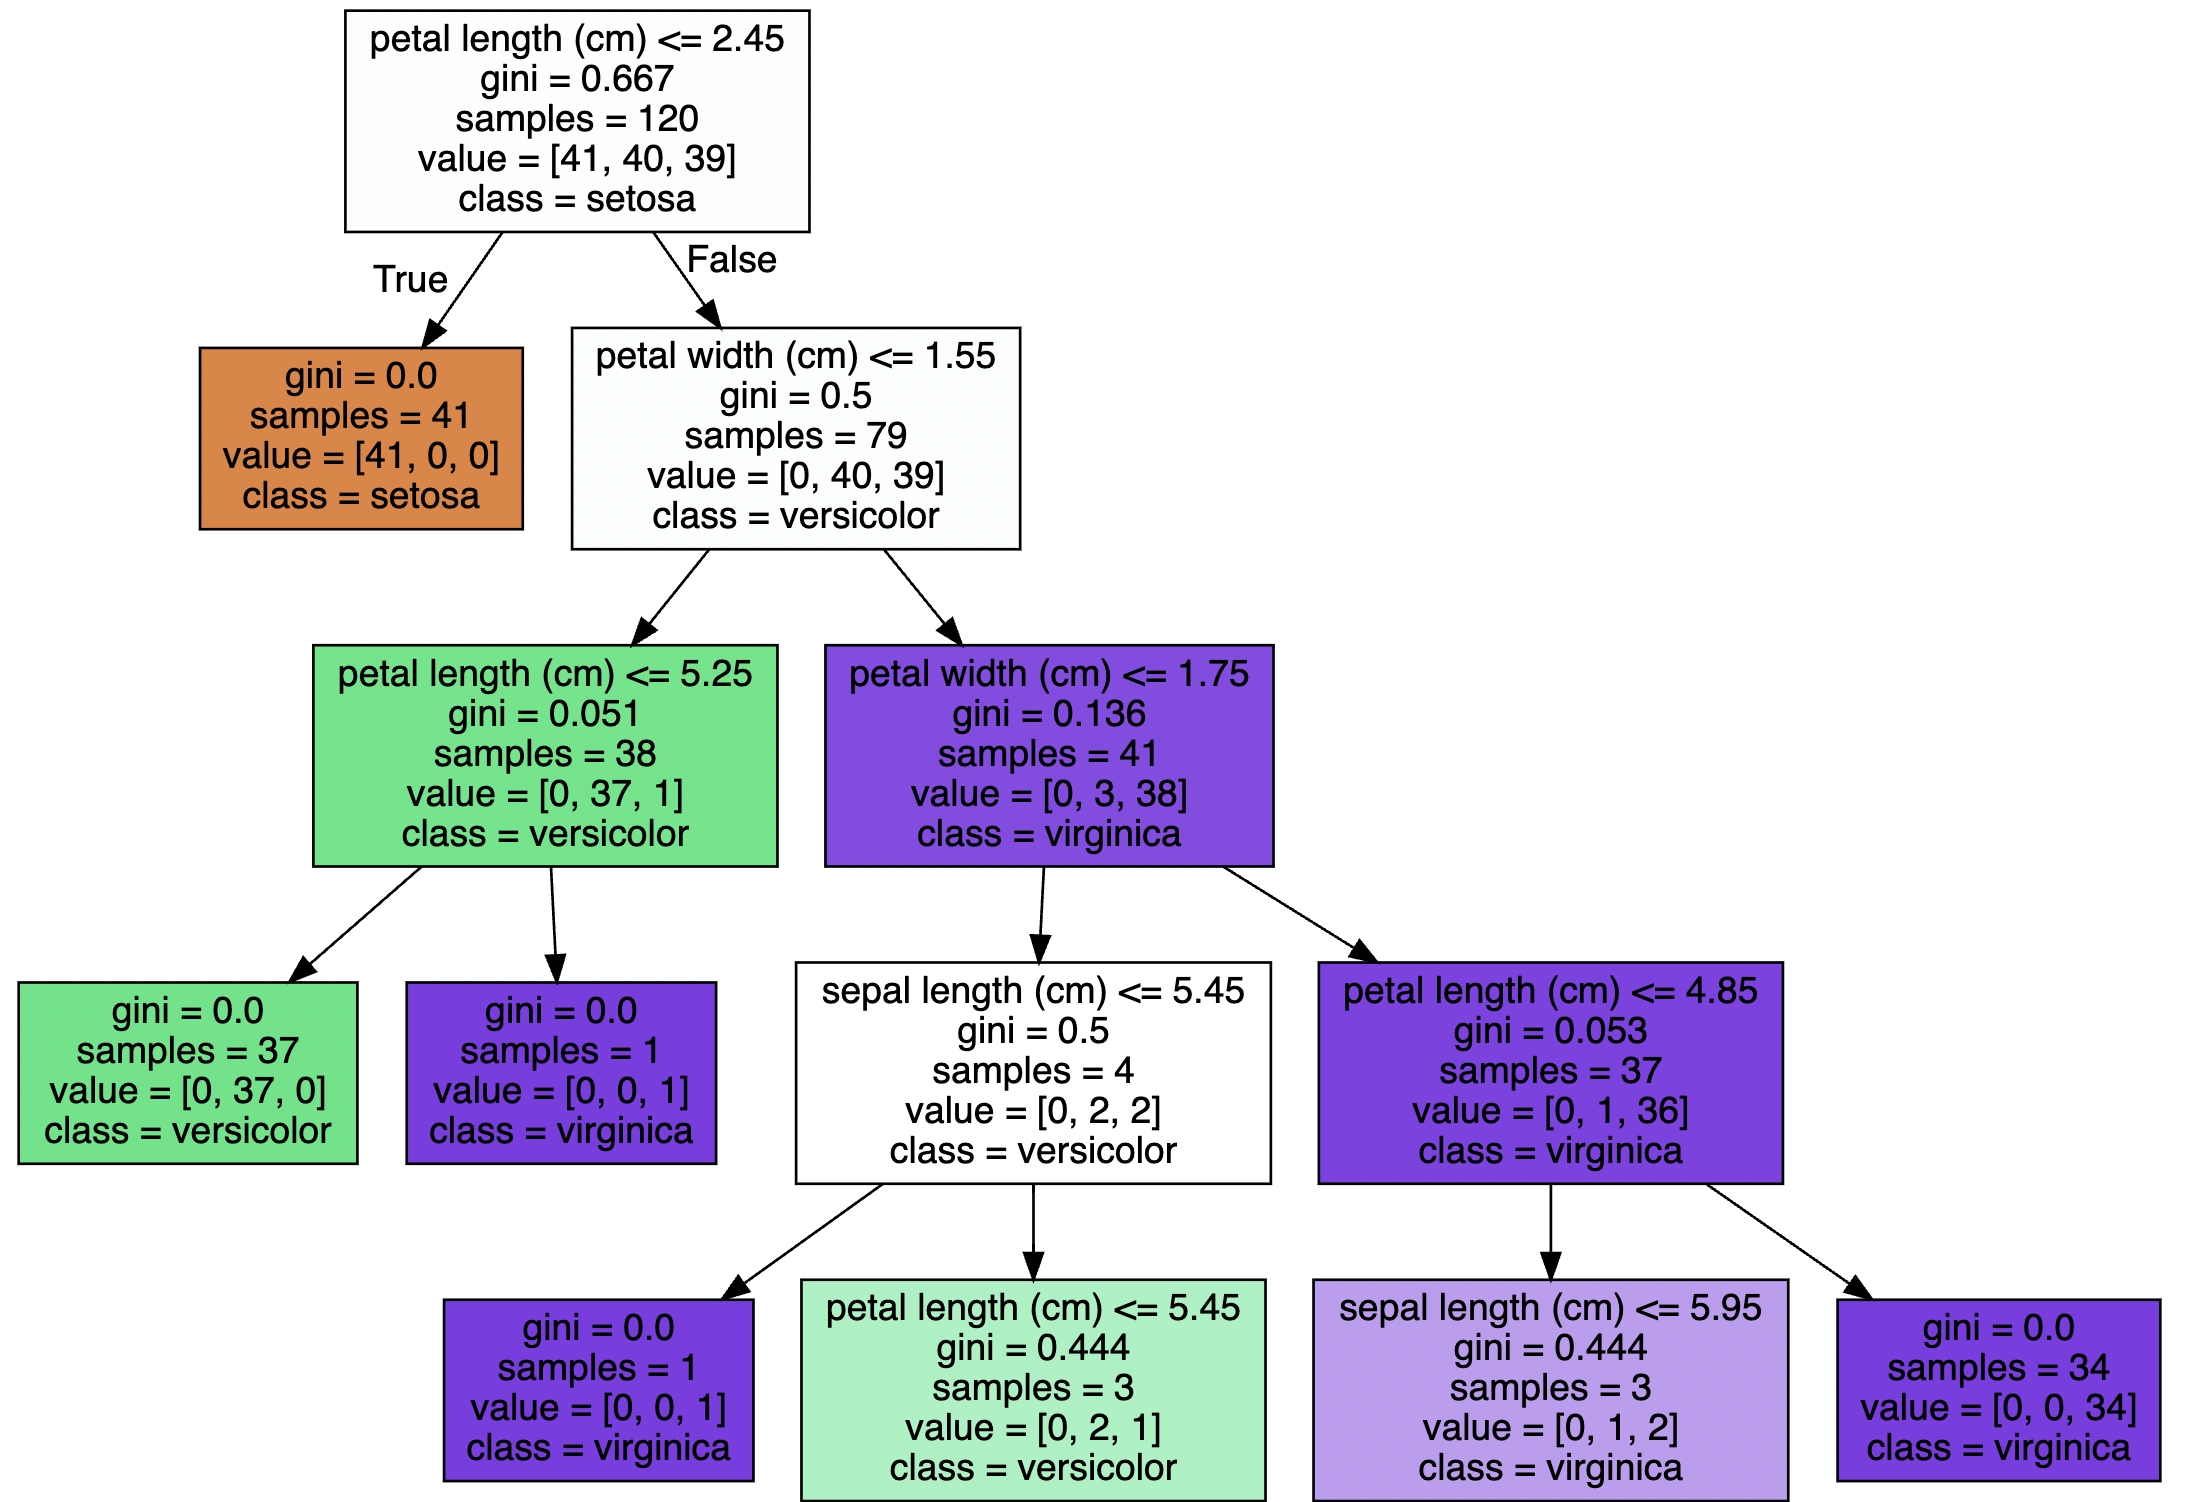

리프 노드
- 더 이상 자식 노드가 없는 노드
- 최종 클래스(레이블) 값이 결정되는 노드
- 리프 노드가 되려면 오직 하나의 클래스 값으로 최종 데이터가 구성되거나
- 리프 노드가 될 수 있는 하이퍼 파라미터 조건을 충족하면 됨


브랜치 노드
- 자식 노드가 있는 노드
- 자식 노드를 만들기 위한 분할 규칙 조건을 갖고 있음

지표들의 의미
- petal length(cm) <= 2.45와 같이 피처의 조건이 있는 것은 자식 노드를 만들기 위한 규칙 조건임(이 조건 없으면 리프 노드)
- gini : 다음의 value = []로 주어진 데이터 분포에서의 지니 계수
- samples : 현 규칙에 해당하는 데이터 건수
- value = [] : 클래스 값 기반의 데이터 건수


- petal length(cm) <= 2.45 : 해당 규칙으로 자식 노드 생성
- samples = 120 : 전체 데이터 120개
- value = [41, 40, 39] : Setosa 41개, Versicolor 40개, Virginica 39개로 데이터 구성
- gini = 0.667 : sample 120 / values = [41, 40, 39] 분포도로 되어 있으므로 지니 계수 0.667
- class = setosa : 하위 노드를 가질 경우에 setosa의 개수가 41개로 제일 많음


- 각 노드의 색깔을 붗꽃 데이터의 레이블 값을 의미
- 주황색 0 : Setosa, 초록색 1 : Versicolor, 보라색 2 : Virginica
- 색깔이 짙어질수록 지니 계수가 낮고 해당 레이블에 속하는 샘플 데이터가 많음


- 결정 트리는 규칙 생성 로직을 미리 제어하지 않으면 완벽하게 클래스 값을 구별해내기 위해 트리 노드를 계속해서 만듦
- 이로 인해 매우 복잡한 규칙 트리 만들어져 모델이 쉽게 과적합되는 문제점을 가짐
- 따라서 결정 트리는 과적합이 상당히 높은 ML 알고리즘임

max_depth 하이퍼 파라미터
- 결정 트리의 최대 트리 깊이를 제어함

min_samples_split 하이퍼 파라미터
- 자식 규칙 노드를 분할해 만들기 위한 최소한의 샘플 데이터 개수
- min_sample_split = 4 지정 시 samples가 3개이면 서로 class 값이 있어도 split 하지 않음

min_samples_leaf 하이퍼 파라미터
- 분할될 경우 왼쪽과 오른쪽 자식 노드 각각이 가지게 될 최소 데이터 건수 지정
- 어떤 노드가 분할할 경우, 왼쪽과 오른쪽 자식 노드 중에 하나라도 min_samples_leaf로 지정된 최소 데이터 건수보다 더 작은 샘플 데이터 건수를 갖게 되면, 해당 노드는 더 이상 분할하지 않음

> - min_samples_leaf의 값을 키우면 분할될 수 있는 조건이 어렵게 되므로, 리프 노드가 될 수 있는 조건이 상대적으로 완화됨
> - 보통 분할 시, 왼쪽 or 오른쪽 중 어느 한 쪽 샘플 데이터 건수는 크고 다른 쪽 건수는 작아지기 쉬움
> - min_samples_leaf를 큰 값으로 지정하면 분할될 때 자식 노드들 모두가 해당 조건을 만족하기에 어려워짐


- 결정트리는 균일도에 기반해 어떠한 속성을 규칙 조건으로 선택하느냐가 중요한 요건임
- 중요한 몇 개의 피처가 명확한 규칙 트리를 만드는 데 크게 기여하며,
- 모델을 좀 더 간결하고 이상치에 강한 모델을 만들 수 있기 때문임
- featureimportances 속성은 피러별로 중요도 값을 알려줌

Feature importances : [0.017 0.017 0.89  0.077]
sepal length (cm) : 0.01667708984782155
sepal width (cm) : 0.01667708984782155
petal length (cm) : 0.8897524292072354
petal width (cm) : 0.07689339109712143


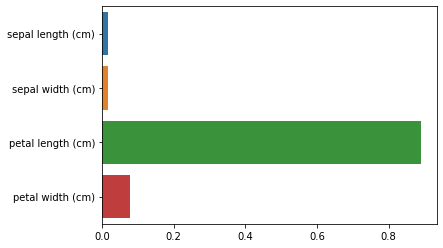

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 156)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

# feature importance 추출
print(f'Feature importances : {np.round(dt_clf.feature_importances_, 3)}')

# features 별 importance 매핑
for name, value in zip(iris.feature_names, dt_clf.feature_importances_):
    print(f'{name} : {value}')

# feature importance를 column 별로 시각화 하기
sns.barplot(x = dt_clf.feature_importances_, y = iris.feature_names)

### 결정 트리 과적합(Overfitting)

- 일부 이상치 데이터까지 분할하면 결정 기준 경계가 매우 많아짐
- 결정 트리의 기본 하이퍼 파라미터 설정은 리프 노드 안에 데이터가 모두 균일하거나 하나만 존재해야 하는 엄격한 분할 기준으로 인해 결정 기준 경계가 많아지고 복잡해짐
- 복잡한 모델은 학습 데이터 세트의 특성과 약간만 다른 형태의 데이터 세트를 예측하면 예측 정확도가 떨어짐


- 이상치에 크게 반응하지 않으면서 좀 더 일반화된 분류 규칙의 성능이 더 좋음
- 테스트 데이터 세트는 학습 데이터 세트와는 다른 데이터 세트인데, 학습 데이터에만 지나치게 최적화된 분류 기준은 오히려 테스트 데이터 세트에서 정확도를 떨어뜨릴 수 있기 때문임


## 2. 앙상블 학습

- 앙상블 학습을 통한 분류는 여러 개의 분류기를 생성하고 그 예측을 결합함으로써 보다 정확한 최종 예측을 도출하는 기법임
- 대부분의 정형 데이터 분류 시 앙상블이 뛰어난 성능을 나타내고 있음
- 앙상블 알고리즘의 대표적인 랜덤 포레스트와 그래디언트 부스팅이 많이 사용됨
> - XGBoodt, LightGBM, Stacking

- 앙상블 학습의 유형은 **보팅(Voting), 배깅(Bagging), 부스팅(Boosting)**으로 나눌 수 있음
이 외에도 다양한 앙상블 방법이 있음
> - **보팅** : 일반적으로 서로 다른 알고리즘을 가진 분류기를 결합하는 것
> - **배깅** : 각각의 분류기가 모두 같은 유형의 알고리즘 기반이지만, 데이터 샘플링을 다르게 가져가면서 학습을 수행
> - 대표적인 배깅 방식이 랜덤 포레스트임
> - **부스팅** : 여러 개의 분류기가 순차적으로 학습을 수행하되, 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에 가중치를 부여하면서 학습과 예측을 진행하는 것

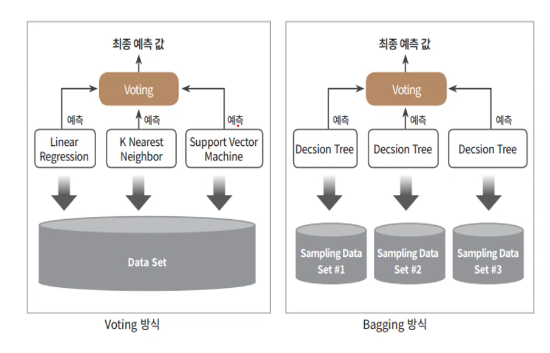

### 보팅 유형 - 하드 보팅과 소프트 보팅

- **하드 보팅**을 이용한 분류는 다수결 원칙과 비슷함
- 예측한 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 보팅 결괏값으로 설정하는 것


- **소프트 보팅**은 분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균해서 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결괏값으로 선정
- 일반적으로 소프트 보팅 방법으로 적용됨
- 일반적으로 하드 보팅보다는 소프트 보팅이 예측 성능이 더 좋아서 많이 사용됨

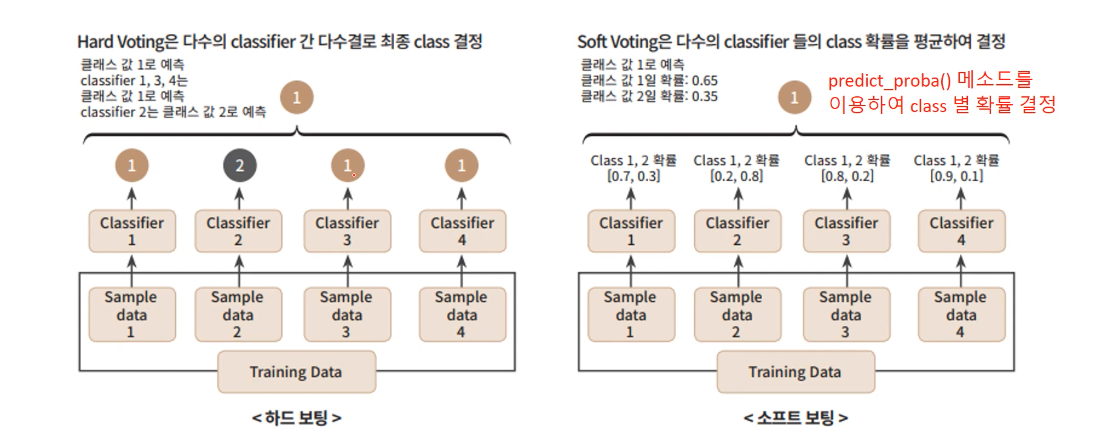

### 보팅 분류기(Voting Classifier)

In [ ]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
# 개별 모델은 로지스틱 회귀와 KNN임
lr_clf = LogisticRegression(solver = 'liblinear')
knn_clf = KNeighborsClassifier(n_neighbors = 8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf)], voting = 'soft', verbose = 3)

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size = .2, random_state = 156)

# VotingClassifier 학습/예측/평가
vo_clf.fit(X_train, y_train)

pred = vo_clf.predict(X_test)
print(f'Voting 분류기 정확도 : {accuracy_score(y_test, pred)}')

# 개별 모델의 학습/예측/평가
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print(f'{class_name} 정확도 : {accuracy_score(y_test, pred)}')

[Voting] ....................... (1 of 2) Processing LR, total=   0.0s
[Voting] ...................... (2 of 2) Processing KNN, total=   0.0s
Voting 분류기 정확도 : 0.956140350877193
LogisticRegression 정확도 : 0.9473684210526315
KNeighborsClassifier 정확도 : 0.9385964912280702


- 보팅 분류기가 정확도가 조금 높게 나옴
- 보팅으로 여러 개의 기반 분류기를 결합한다고 해서 무조건 기반 분류기보다 예측 성능이 향상되지는 않음
- 데이터의 특성과 분포 등 다양한 요건에 따라 오히려 기반 분류기 중 가장 좋은 분류기의 성능이 보팅했을 때보다 나을 수도 있음


- 보팅, 배깅, 부스팅 등의 앙상블 방법은 전반적으로 다른 단일 ML 알고리즘보다 뛰어난 예측 성능을 가지는 경우가 많음
- 고정된 데이터 세트에서 단일 ML 알고리즘이 뛰어난 성능을 발휘하더라고 현실 세계는 다양한 변수와 예측이 어려운 규칙으로 구성돼있음
- 다양한 관점을 가진 알고리즘이 서로 결합해 더 나은 성능을 실제 환경에서 끌어낼 수 있음
- ML 모델의 성능은 이렇게 다양한 테스트 데이터에 의해 검증되므로 어떻게 높은 유연성을 가지고 현실에 대처할 수 있는가가 중요한 ML 모델의 평가요소가 됨


- 이런 관점에서 편향-분산 트레이드오프는 ML 모델이 극복해야 할 중요 과제임
- 보팅과 스태킹 등은 서로 다른 알고리즘을 기반으로 하고 있지만,
- 배깅과 부스팅은 대부분 결정 트리 알고리즘을 기반으로 함


- 결정 트리 알고리즘은 쉽고 직관적인 분류 기준을 가지고 있지만 정확한 예측을 위해 학습 데이터의 예외 상황에 집착한 나머지 오히려 과적합이 발생해 실제 테스트 데이터에서 예측 성능이 떨어지는 현상 발생하기 쉬움
- 하지만 앙상블 학습에서는 이 같은 결정 트리 알고리즘의 단점을 수십~수천 개의 매우 많은 분류기를 결합해 다양한 상황을 학습하게 함으로써 극복하고 있음
- 결정 트리 알고리즘의 장점은 그대로 취하고 단점은 보완하면서 편향-분산 트레이드오프의 효과를 극대화할 수 있음


## 3. 랜덤 포레스트

### 배깅
- 같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 최종 결정하는 알고리즘
> - 대표적인 알고리즘 : 랜덤 포레스트

### 랜덤 포레스트
- 랜덤 포레스트는 앙상블 알고리즘 중 비교적 빠른 수행 속도를 가지고 있으며, 다양한 영역에서 높은 예측 성능을 보이고 있음
- 랜덤 포레스트는 여러 개의 결정 트리 분류기가 전체 데이터에서 배깅 방식으로 각자의 데이터를 샘플링해 개별적으로 학습을 수행한 뒤 최종적으로 모든 분류기가 보팅을 통해 예측 결정함
- 랜덤 포레스트는 개별적인 분류기의 기반 알고리즘은 결정 트리임
> - 개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 샘플링 된 데이터 세트임
> - 이렇게 여러 개의 데이터 세트를 중첩되게 분리하는 것을 '부트스트래핑(bootstrapping)' 분할 방식이라고 함
> - 랜덤 포레스트의 서브세트(Subset) 데이터는 이러한 부트스트래핑으로 데이터가 임의로 만들어짐

- 서브세트의 데이터 건수는 전체 데이터 건수와 동일하지만, 개별 데이터가 중첩되어 만들어짐

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

feature_name_df = pd.read_csv('./human_activity/features.txt', sep = '\s+',
                              header = None, names = ['column_index', 'column_name'])

feature_name = feature_name_df.iloc[:, 1].values.tolist()
feature_name[:10]

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y',
 'tBodyAcc-std()-Z',
 'tBodyAcc-mad()-X',
 'tBodyAcc-mad()-Y',
 'tBodyAcc-mad()-Z',
 'tBodyAcc-max()-X']

In [ ]:
## 원본 피터명에 _1 또는 _2 추가로 부여해 새로운 피처명을 가지고는 DataFrame 반환

def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1])
                                                                                         if x[1] >0 else x[0],  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [ ]:
import pandas as pd

def get_human_dataset( ):

    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv('./human_activity/features.txt',sep='\s+',
                        header=None,names=['column_index','column_name'])

    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성.
    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv('./human_activity/train/X_train.txt',sep='\s+', names=feature_name )
    X_test = pd.read_csv('./human_activity/test/X_test.txt',sep='\s+', names=feature_name)

    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv('./human_activity/train/y_train.txt',sep='\s+',header=None,names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt',sep='\s+',header=None,names=['action'])

    # 로드된 학습/테스트용 DataFrame을 모두 반환
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_human_dataset()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 결정 트리에서 사용한 dataset 이용해 학습/테스트용 DataFrame 전환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state = 0, max_depth = 8)
rf_clf.fit(X_train, y_train)

pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)
print(f'랜덤 포레스트 정확도 : {accuracy}')

랜덤 포레스트 정확도 : 0.9195792331184255


### 랜덤 포레스트 하이퍼 파라미터 및 튜닝
- 트리 기반의 앙상블 알고리즘의 단점 : 하이퍼 파라미터가 너무 많고 그로 인해서 튜닝을 위한 시간 소모가 많음

- 많은 시간을 소모했음에도 튜닝 후 예측 성능이 크게 향상되는 경우가 많지 않음

랜덤 포레스트 파라미터
> - n_estimators : 랜덤 포레스트에서 결정 트리의 개수를 지정(default = 10), 많이 설정할 수록 좋은 성능 기대할 수 있으나 계속 증가시킨다고 성능이 무조건 향상되는 것은 아님 / 늘릴수록 수행 시간 오래 걸림

> - max_features : 결정 트리에 사용된 max_features 파라미터와 같음 / 랜덤 포레스트의 트리를 분할하는 피처를 참조할 때 전체 피처가 아니라 sqrt 만큼 참조함(전체 피처가 16개라면 분할을 위해 4개 참조)

> - max_depth나 min_samples_leaf, min_samples_split와 같이 결정 트리에서 과적합을 개선하기 위해 사용되는 파라미터가 랜덤 포레스트에도 똑같이 적용될 수 있음

In [ ]:
rf_clf = RandomForestClassifier(n_estimators = 200, random_state = 0, n_jobs = -1,
                               min_samples_split = 3)
rf_clf.fit(X_train, y_train)

pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)
print(f'랜덤 포레스트 정확도 : {accuracy}')

랜덤 포레스트 정확도 : 0.9267051238547676


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [8, 16, 24],
    'min_samples_leaf' : [1, 6, 12],
    'min_samples_split' : [2, 8, 6]
}

# RandomForesClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 0, n_jobs = -1)

grid_cv = GridSearchCV(rf_clf, param_grid = params, cv = 2, n_jobs = -1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터 : \n', grid_cv.best_params_)
print(f'최고 예측 정확도 : {grid_cv.best_score_}')

최적 하이퍼 파라미터 : 
 {'max_depth': 16, 'min_samples_leaf': 6, 'min_samples_split': 2}
최고 예측 정확도 : 0.9164853101196953


In [ ]:
rf_clf1 = RandomForestClassifier(n_estimators = 100, random_state = 0, min_samples_split = 2,
                                 min_samples_leaf = 6, max_depth = 16, n_jobs = -1)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
accuracy_score(y_test, pred)

0.9260264675941635

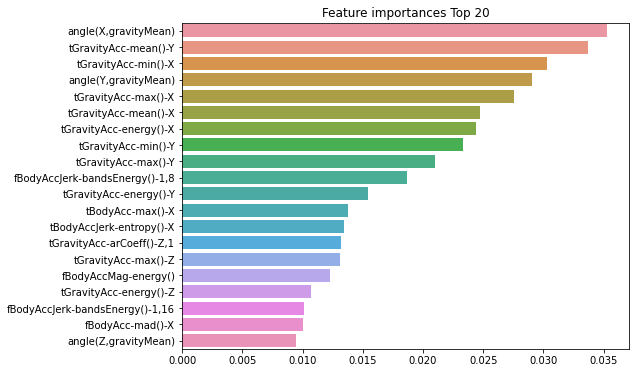

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values,index=X_train.columns  )
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20 , y = ftr_top20.index)
plt.show()

## 5. GBM(Gradient Boosting Machine)

GBM(Gradient Boosting Machine)
- 부스팅 알고리즘은 여러 개의 약한 학습기를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식임
- 부스팅의 대표적인 구현은 AdaBoost(Adaptive Boosting)와 그래디언트 부스트가 있음
- 에이다 부스트 : 오류 데이터에 가중치를 부여하면서 부스팅을 수행하는 대표적인 알고리즘

> 1. 분류
> 2.잘못 분류된 오류 데이터에 대해서 가중치 값을 부여(다음 약한 학습기가 더 잘 분류할 수 있게 크기가 커짐)
> 3. 분류 후 또 다시 오류 데이터에 가중치를 부여
> 4. 약한 학습기가 순차적으로 오류 값에 대해 가중치를 부여한 예측 결정 기준을 모두 결합해 예측 수행



- GBM도 에이다부스트와 유사하나, 가중치 업데이트를 경사 하강법(Gradient Descent)을 이용하는 것이 큰 차이임
- 오류 값은 실제 - 예측값임

- 분류의 실제 값을 y

- 피처를 x1, x2, x3, ... xn
- 피처에 기반한 예측 함수 F(x) 함수라고 하면

> - 오류식은 h(x) = y - F(x)임

- 이 오류식을 최소화하는 방향성을 가지고 반복적으로 가중치 값을 업데이트 하는 것이 경사 하강법임

- **경사 하강법** : 반복 수행을 통해 오류를 최소화할 수 있도록 가중치의 업데이트 값을 도출하는 기법

In [ ]:
## GBM
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정 위함. 시작 시간 설정
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state = 0)
gb_clf.fit(X_train, y_train)

gb_pred = gb_clf.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도 : ', gb_accuracy)
print(f'GBM 수행 시간 : {time.time() - start_time} 초')

GBM 정확도 :  0.9385816084153377
GBM 수행 시간 : 695.115237236023 초


GBM 하이퍼 파라미터 소개
> - loss : 경사 하강법에서 사용할 비용 함수를 지정함. 특별한 이유 없으면 기본값인 'deviance'를 그대로 적용함

> - learning_rate : GBM이 학습을 진행할 때마다 적용하는 학습률임. Weak learner가 순차적으로 오류 값을 보정해나가는 데 적용하는 계수 (0 ~ 1 사이) - 너무 작은 값 적용 시 최소 오류 값을 찾아 예측 성능이 높아질 가능성 있음

> - n_estimators : weak learner의 개수(기본값 100) - learning_rate와 상호 보완적으로 조합해 사용

> - subsample : weak learner가 학습에 사용하는 데이터의 샘플링 비율 (기본값 1, 이는 전체 학습 데이터를 기반으로 학습한다는 의미임) - 과적합 염려 시, subsample을 1보다 작은 값으로 설정

## 6. XGBoost(eXtra Gradient Boost)

- 분류에 있어서 일반적으로 다른 머신러닝보다 뛰어난 예측 성능을 나타냄
- GBM 기반이나 GBM의 단점이 느린 수행 시간 및 과저합 규제 부재 등의 문제를 해결해서 각광 받고있음
장점
- 뛰어난 예측 성능
- GBM 대비 빠른 수행 시간
- 과적합 규제 - 자체 과적합 규제 기능이 있어 강한 내구성 가질 수 있음
- Tree Pruning(가지치기)
- 자체 내장된 교차 검증 - 반복 수행 시마다 내부적으로 학습 데이터 세트와 평가 데이터 세트에 대한 교차 검증을 수행해 최적화 된 반복 수행 횟수를 가질 수 있음
- 결손값 자체 처리

In [ ]:
## XG Boost
!pip install xgboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
xgb.__version__

'0.90'

### 파이썬 래퍼 XGBoost 하이퍼 파라미터
- 일반 파라미터 : 일반적으로 실행 시 스레드의 개수나 silent 모드 등의 선택을 위한 파라미터로서 디폴트 파라미터 값을 바꾸는 경우는 거의 없음
- 부스터 파라미터 : 트리 최적화, 부스팅, regularization 등과 관련된 파라미터 등을 지칭함
- 학습 태스크 파라미터 : 학습 수행 시 객체 함수, 평가를 위한 지표 등을 설정하는 파라미터

주요 일반 파라미터
- booster : gbtree(tree based model) 또는 gblinear(linear model) 선택
- silent : 디폴트느 ㄴ0이며, 출력 메시지를 나타내고 싶지 않을 때 1 선택
- nthread : CPU의 실행 스레드 개수를 조정하는 것

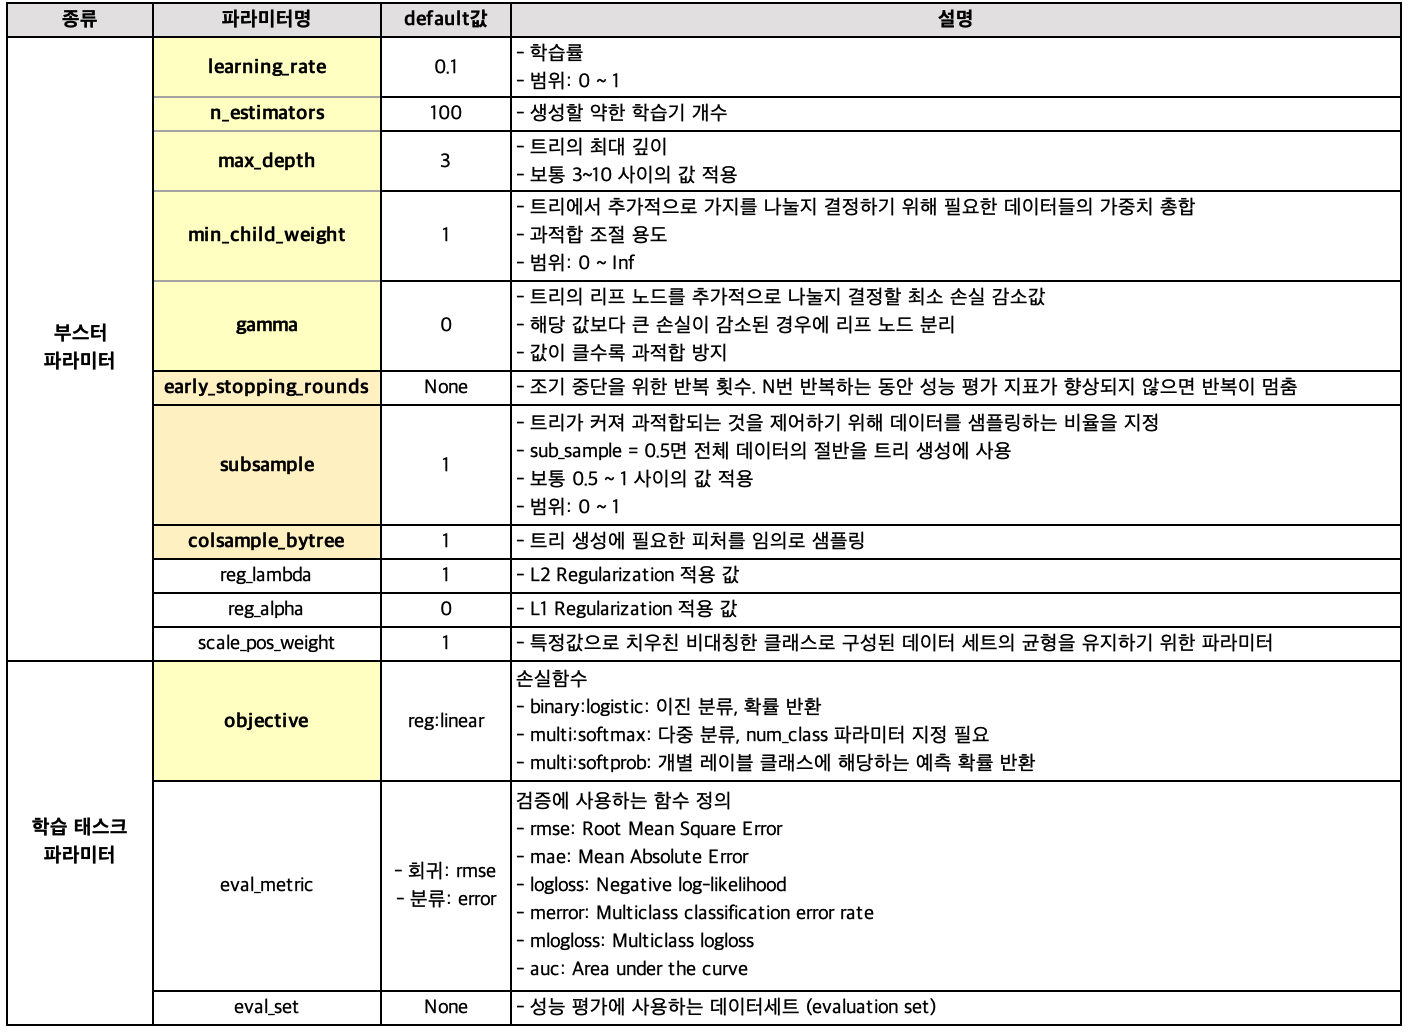

뛰어난 알고리즘일수록 파라미터를 튜닝할 필요 없음

파라미터 튜닝하는 경우의 수는 여러 가지 상황에 따라 달라짐

피처의 수가 매우 많거나 피처 간 상관되는 정도가 많거나 데이터 세트에 따라 여러 가지 특성이 있을 수 있음

과적합 문제가 심각하다면 다음과 같이 적용하기
- eta값 낮추기(0.01 ~ 0.1) eta 값을 낮출 경우 num_round(또는 n_estimator)는 반대로 높여줘야 함
- max_depth 값 낮추기
- min_child_weight 값 높이기
- gamma 값 높이기
- subsample과 colsample_bytree를 조정하는 것도 트리가 너무 복잡하게 생성되는 것을 막아 과적합 문제에 도움이 될 수 있음

조기 중단 관련 파라미터

> - 평가 지표가 향상될 수 있는 반복 횟수를 정의하는 early_stopping_rounds
> - 조기 중단을 위한 평가 지표인 eval_metric
> - 성능 평가를 수행할 데이터 세트인 eval_set

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 156)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .1, random_state = 156)

In [ ]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력
xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05,
                            max_depth = 3, eval_metric = 'logloss')

xgb_wrapper.fit(X_train, y_train, verbose = True)

w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [ ]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870,    F1: 0.9744, AUC:0.9954


In [ ]:
xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05, max_depth = 3)
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds = 50, eval_metric = 'logloss',
               eval_set = evals, verbose = True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.650162	validation_1-logloss:0.661831
Multiple eval metrics have been passed: 'validation_1-logloss' will be used for early stopping.

Will train until validation_1-logloss hasn't improved in 50 rounds.
[1]	validation_0-logloss:0.611314	validation_1-logloss:0.636086
[2]	validation_0-logloss:0.57563	validation_1-logloss:0.611436
[3]	validation_0-logloss:0.543099	validation_1-logloss:0.592036
[4]	validation_0-logloss:0.513234	validation_1-logloss:0.573291
[5]	validation_0-logloss:0.484475	validation_1-logloss:0.550371
[6]	validation_0-logloss:0.457959	validation_1-logloss:0.529295
[7]	validation_0-logloss:0.434357	validation_1-logloss:0.51534
[8]	validation_0-logloss:0.411503	validation_1-logloss:0.497179
[9]	validation_0-logloss:0.390274	validation_1-logloss:0.481542
[10]	validation_0-logloss:0.371284	validation_1-logloss:0.469904
[11]	validation_0-logloss:0.352541	validation_1-logloss:0.45474
[12]	validation_0-logloss:0.335278	validation_1-logloss:0.442294
[13

조기 중단 관련 파라미터

> - 평가 지표가 향상될 수 있는 반복 횟수를 정의하는 early_stopping_rounds
> - 조기 중단을 위한 평가 지표인 eval_metric
> - 성능 평가를 수행할 데이터 세트인 eval_set

In [ ]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9933


- 조기 중단값을 너무 급격하게 줄이면 예측 성능이 저하될 수 있음
- 만약 early_stopping_rounds를 10으로 하면 아직 성능이 향상될 여지가 있음에도 불구하고 10번 반복하는 동안 성능 평가지표가 향상되지 않으면 반복이 멈춰 버려서 충분한 학습이 되지 않아 예측 성능이 나빠질 수 있음

In [ ]:
xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05, max_depth = 3)
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds = 10, eval_metric = 'logloss',
               eval_set = evals, verbose = True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]


[0]	validation_0-logloss:0.650162	validation_1-logloss:0.661831
Multiple eval metrics have been passed: 'validation_1-logloss' will be used for early stopping.

Will train until validation_1-logloss hasn't improved in 10 rounds.
[1]	validation_0-logloss:0.611314	validation_1-logloss:0.636086
[2]	validation_0-logloss:0.57563	validation_1-logloss:0.611436
[3]	validation_0-logloss:0.543099	validation_1-logloss:0.592036
[4]	validation_0-logloss:0.513234	validation_1-logloss:0.573291
[5]	validation_0-logloss:0.484475	validation_1-logloss:0.550371
[6]	validation_0-logloss:0.457959	validation_1-logloss:0.529295
[7]	validation_0-logloss:0.434357	validation_1-logloss:0.51534
[8]	validation_0-logloss:0.411503	validation_1-logloss:0.497179
[9]	validation_0-logloss:0.390274	validation_1-logloss:0.481542
[10]	validation_0-logloss:0.371284	validation_1-logloss:0.469904
[11]	validation_0-logloss:0.352541	validation_1-logloss:0.45474
[12]	validation_0-logloss:0.335278	validation_1-logloss:0.442294
[13

In [ ]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[34  3]
 [ 3 74]]
정확도: 0.9474, 정밀도: 0.9610, 재현율: 0.9610,    F1: 0.9610, AUC:0.9933


## 7. LightGBM

- LightGBM의 가장 큰 장점은 XGBoost보다 학습에 걸리는 시간이 훨씬 적다는 점임
- 메모리 사용량도 상대적으로 적음
- LightGBM과 XGBoost의 예측 성능은 별다른 차이가 없음
- 기능상의 다양성은 LightGBM이 약간 더 많음


- LightGBM의 한 가지 단점으로 알려진 것은 적은 데이터 세트에 적용할 경우 과적합기 발생하기 쉽다는 점임
- 정확도가 매우 높음을 의미함


- LightGBM은 일반 GBM 계열의 트리 분할 방법과 다르게 리프 중심 트리 분할(Leaf Wise) 방식을 사용
- LightGBM의 리프 중심 트리 분할 방식은 트리의 균형을 맞추지 않고, 최대 손실값(max delta loss)을 가지는 리프 노드를 지속적으로 분할하면서 트리의 깊이가 깊어지고 비대칭적인 규칙 트리가 생성됨
- 하지만 이렇게 최대 손실값을 갖는 리프 노드를 지속적으로 분할해 생성된 규칙 트리는 학습을 반복할수록 결국은 균형 트리 분할 방식보다 예측 오류 손실을 최소화할 수 있다는 것이 LightGBM 구현 사상임


LightGBM의 XGBoost 대비 장점

> - 더 빠른 학습과 예측 수행 시간
> - 더 작은 메모리 사용량
> - 카테고리형 피처의 자동 변환과 최적 분할(원-핫 인코딩 등을 사용하지 않고 카테고리형 피처를 최적으로 변환하고 이에 따른 노드 분할 수행)

In [ ]:
pip install lightgbm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


### LightGBM 하이퍼 파라미터
주요 파라미터

> - num_iterations[default = 100] : 반복 수행하려는 트리의 개수를 지정(크게 지정할수록 예측 성능이 높아질 수 있으나, 너무 크게 지정하면 오히려 과적합으로 성능이 저하될 수 있음)

> - learning_rate[default = 0.1] : 0과 1 사이의 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값

> - max_depth[default = 1] : 트리 기반의 알고리즘의 max_depth와 같음. 0보다 작게 지정하면 제한 없음

> - min_data_in_leaf[default = 20] : 결정 트리의 min_samples_leaf와 같은 파라미터임(분할될 경우 왼쪽과 오른쪽 자식 노드 각각이 갖게 될 최소 데이터 건수)

> - num_leaves[default = 31] : 하나의 트리가 가질 수 있는 최대 리프 개수

> - boosting[default = gbdt] : 부스팅의 트리를 생성하는 알고리즘 기술 (gbdt : 일반적인 그랜드 부스팅 결정 트리, rf : 랜덤 포레스트)

> - bagging_fraction[default = 1.0] : 트리가 커져서 과적합되는 것을 제어하기 위해서 데이터를 샘플링하는 비율을 지정

> - feature_fraction[defualt = 1.0] : 개별 트리를 학습할 때마다 무작위로 선택하는 피처의 비율

> - lambda_l2 : L2 regulation 제어를 위한 값

> - lambda_l1 : L1 regulation 제어를 위한 값



Learning Task 파라미터

> - objective : 최솟값을 가져야 할 손실함수를 정의

### 하이퍼 파라미터 튜닝 방안
- num_leaves는 개별 트리가 가질 수 있는 최대 리프의 개수임
- LightGBM 모델의 복잡도를 제어하는 주요 파라미터임
- 일반적으로 num_leaves의 개수를 높이면 정확도가 높아지지만, 반대로 트리의 깊이가 깊어지고 모델이 복잡도가 커져서 과적합 영향도가 커짐


- min_data_in_leaf는 사이킷런 래퍼 클래스에서는 min_child_samples로 이름이 바뀜
과적합을 개선하기 위한 중요 파라미터임


- num_leaves와 학습 데이터의 크기에 따라 달라지지만, 보통 큰 값으로 설정하면 트리가 깊어지는 것을 방지함


- max_depth는 명시적으로 깊이의 크리를 제한함


- num_leaves, min_data_in_leaf와 결합해 과적합을 개선하는 데 사용함


- learning_rate를 작게 하면서 n_estimators를 크게 하는 것은 부스팅 계열 튜닝에서 가장 기본적인 튜닝 방안임


- n_estimators를 너무 크게하는 것은 과적합으로 오히려 성능이 저하될 수 있음

### LightGBM 적용 - 위스콘신 유방암 예측
- 검증 데이터셋(validation set) : 학습과정에서 모델의 성능을 확인하고, 하이퍼 파라미터를 튜닝하는데 사용됩니다. 여러 하이퍼 파라미터로 생성된 모델 중 어떤 것이 성능이 좋은지 평가합니다.

- 검증데이터셋을 활용하여 학습 중인 모델이 과적합되었는지 확인하여, 학습을 조기에 종료(early stopping)하고, 하이퍼 파라미터를 튜닝하는 등의 조치를 취합니다.

- 그 후, 학습셋과 검증데이터셋 전체를 다시 학습하여 테스트셋에 대해 예측을 수행합니다. 이를 통해 학습하지 않은 데이터에 대해서도 모델의 성능이 잘 나오는지 확인합니다.

사이킷란 래퍼 XGBoost와 LightGBM은 조기 중단 기능을 지원하며 아래의 파라미터를 입력합니다.

> - 평가 지표가 향상될 수 있는 반복 횟수를 정의하는 early_stopping_rounds
> - 성능 평가를 수행할 데이터 세트인 eval_set
> - 조기 중단을 위한 평가지표인 eval_metric

In [ ]:
import lightgbm

In [ ]:
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)

cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = .2, random_state = 156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .1, random_state = 156)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정
lgbm_wrapper = LGBMClassifier(n_estimators = 400, learning_rate = 0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, early_stopping_rounds = 50, eval_metric = 'logloss',
                eval_set = evals, verbose = True)

preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[1]	training's binary_logloss: 0.625671	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248	valid_1's binary_logloss: 0.628248
Training until validation scores don't improve for 50 rounds.
[2]	training's binary_logloss: 0.588173	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	training's binary_loglos

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [ ]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9888


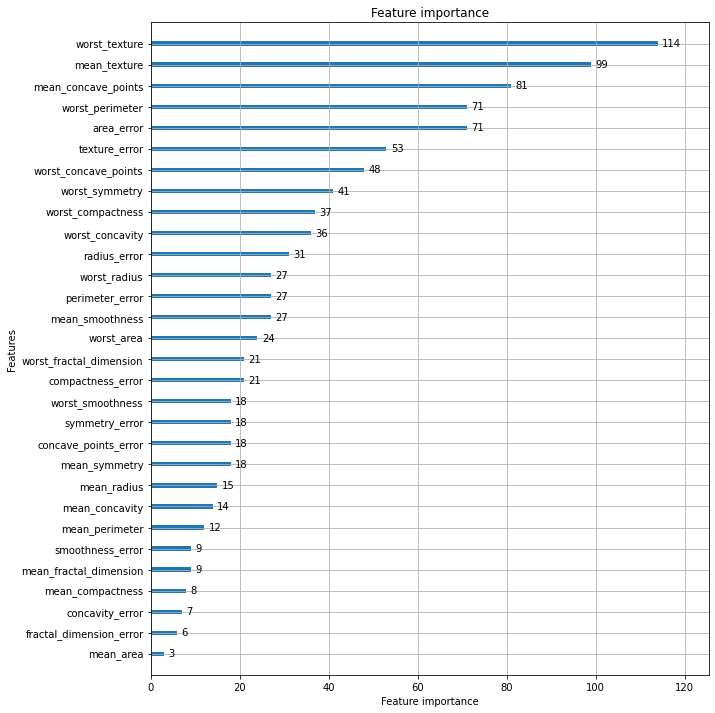

In [ ]:
# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline
##  %matplotlib inline 의 역할은 notebook을 실행한 브라우저에서 바로 그림을 볼 수 있게 해주는 것


fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(lgbm_wrapper, ax = ax)

## 8. 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

지금까지 하이퍼 파라미터 튜닝을 위해 Grid Search 방식을 적용함

Grid Search 방식은 튜닝해야 할 파라미터 개수가 많을 경우 최적화 수행 시간이 오래 걸린다는 단점이 있음

개별 하이퍼 파라미터 값의 범위가 넓거나 학습 데이터가 대용량일 경우 최적화 시간이 더욱 늘어남

실무의 대용량 학습 데이터에 XGBoost나 LightGBM의 하이퍼 파라미터 튜닝 시에 Grid Search 방식보다는 다른 방식을 적용하곤 함

대표적으로 베이지안 최적화 기법이 있음


### 베이지안 최적화 개요
- 베이지안 최적화는 목적 함수 식을 제대로 알 수 없는 블랙 박스 형태의 함수에서 최대 또는 최소 함수 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으로 찾아주는 방식
- 베이지안 확률에 기반을 둔 최적화 기법
- 베이지안 확률이 새로운 사건의 관측이나 새로운 샘플 데이터를 기반으로 사후 확률을 개선해 나가듯이, 베이지안 최적화는 새로운 데이터를 입력받았을 때 최적 함수를 예측하는 사후 모델을 개선해 나가면서 최적 함수 모델을 만들어냄



- 베이지안 최적화 구성 요소 메인 2개 : 대체 모델(Surrogate Model), 획득 함수(Acquisition Function)
- 대체 모델 : 획득 함수로부터 최적 함수를 예측할 수 있는 입력값을 추천받은 뒤 이를 기반으로 최적 함수 모델을 개선해나감
- 획득 함수 : 개선된 대체 모델을 기반으로 최적 입력값 계산

대체 모델은 획득 함수가 계산한 하이퍼 파라미터를 입력받으면서 점차적으로 개선되며, 개선된 대체 모델을 기반으로 획득 함수는 더 정확한 하이퍼 파라미터를 계산할 수 있음



베이지안 최적화 단계

> - step 1) 최초에 랜덤하게 하이퍼 파라미터들을 샘플링하고 성능 결과 관측
> - step 2) 관측된 값을 기반으로 대체 모델은 최적 함수를 추정함
> - step 3) 추정된 최적 함수를 기반으로 획득 함수는 다음으로 관측할 하이퍼 파라미터 값을 계산함(이전 최적 관측값보다 더 큰 최댓값을 가질 가능성이 높은 지점을 찾아서 다음에 관측할 하이퍼 파라미터를 대체 모델에 전달함
> - step 4) 획득 함수로부터 전달된 하이퍼 파라미터를 수행하여 관측된 값을 기반으로 대체 모델은 갱신되어 다시 최적 함수를 예측

### HyperOpt 사용하기
베이지안 최적화를 머신러닝 모델의 하이퍼 파라미터 튜닝에 적용할 수 있게 제공되는 여러 파이썬 패키지들이 있는데 대표적으로는 HyperOpt, Bayesian Optimization, Optuna 등이 있음


HyperOpt 주요 로직

> - 입력 변수명과 입력값의 검색 공간 설정(Search Space) - 변수 범위 정함
> - 둘째는 목적 함수(Objective Function)의 설정 - 목적함수 = 비용함수 = 손실함수
> - 마지막으로 목적 함수의 반환 최솟값을 가지는 최적 입력값을 유추하는 것


HyperOpt를 사용할 때 유의할 점은 다른 패키지와 다르게 목적 함수 반환값의 최댓값이 아닌 최솟값을 가지는 최적 입력값을 유추한다는 점


In [ ]:
pip install hyperopt

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
##### 1. 범위 설정 #####
#########################

from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정
# hp모듈을 이용하여 입력 변수명과 입력값의 검색 공간을 설정하는 함수 hp.quniform
# hp.quniform('x', -10, 10, 1) --> x = [-10, -9, -8, -7, ... 8, 9, 10]

search_space = {'x' : hp.quniform('x', -10, 10, 1), 'y' : hp.quniform('y', -15, 15, 1)}

입력값의 검색 공간 제공하는 함수들
> - hp.quniform(label, low, high, q) : label로 지정된 입력값 변수 검색 공간을 최솟값 low에서 최댓값 high까지 q의 간격을 가지고 설정

> - hp.uniform(label, low, high) : 최솟값 low에서 최댓값 high까지 정규 분포 형태의 검색 공간 설정

> - hp.randint(label, upper) : 0부터 최댓값 upper까지 random한 정숫값으로 검색 공간 설정

> - hp.loguniform(label, low, high) : exp(uniform(low, high))값을 반환하며, 반환 값의 log 변환된 값은 정규 분포 형태를 가지는 검색 공간 설정

> - hp.choice(label, options) : 검색 값이 문자열 또는 문자열과 숫자값이 섞여 있을 경우 설정. Options는 리스트나 튜플 형태로 제공되며 hp.choice('tree_critrion', ['gini', 'entropy'])과 같이 설정하면 입력 변수 tree_criterion의 값을 'gini'와 'entropy'로 설정하여 입력함

In [ ]:
##### 2. 목적 함수 설정 #####
##############################

def objective_func(search_space) :
    x = search_space['x']  ### dictionary였기 때문에 대괄호로 접근
    y = search_space['y']
    retval = x ** 2 - 20 * y

    return retval

- 목적 함수는 반드시 변숫값과 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환하는 구조로 만들어져야 함

- 목적 함수의 반환값은 숫자형 단일값 외에도 딕셔너리 형태로 반환할 수 있음

- 딕셔너리 형태로 반환할 경우에 {'loss' : retval, 'status' : STATUS_OK}와 같이 loss와 status 키 값을 설정해서 반환해야 함

In [ ]:
############## 3. fmin()으로 x, y 값 찾기 #############
#최적의 입력값을 베이지안 최적화 기법에 기반하여 찾기 #
######################################################

from hyperopt import fmin, tpe, Trials

# 입력 결괏값을 저장한 Trials 객체값 생성
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도(max_evals = 5)로 찾아냄
best_01 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 5,
              trials = trial_val)

print('best: ', best_01)

100%|██████████| 5/5 [00:00<00:00, 181.44it/s, best loss: -195.0]
best:  {'x': 5.0, 'y': 11.0}


In [ ]:
# max_evals를 100회로 늘려서 재테스트
best_03 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 100,
              trials = trial_val)

print('best: ', best_03)

100%|██████████| 95/95 [00:02<00:00, 46.79it/s, best loss: -299.0]
best:  {'x': 1.0, 'y': 15.0}


- gridsearch를 돌리지 않아도 x와 y의 범위를 줄여줌

fmin() 함수의 주요 인자
- fn : 위에서 생성한 objective_func와 같은 목적 함수

- space : 위에서 생성한 search_space와 같은 검색 공간 딕셔너리

- algo : 베이지안 최적화 적용 알고리즘. 기본적으로 tpe.suggest이며 이는 HyperOpt의 기본 최적화 알고리즘인 TPE(Tree of Parzen Estimator)를 의미함

- max_evals : 최적 입력값을 찾기 위한 입력값 시도 횟수

- trials : 최적 입력값을 찾기 위해 시도한 입력값 및 해당 입력값의 목적 함수 반환값 결과를 저장하는 데 사용함. Trials 클래스를 객체로 생성한 변수명을 입력

- rstate : fmin()을 수행할 때마다 동일한 결과값을 가질 수 있도록 설정하는 랜덤 시드(seed) 값

In [ ]:
best_03.items()

dict_items([('x', 1.0), ('y', 15.0)])

In [ ]:
# fmin()에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 변환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss' : 함수 반환값, 'status' : 반환 상태값}과 같은 딕셔너리임

trial_val.results[:5]

[{'loss': -51.0, 'status': 'ok'},
 {'loss': 156.0, 'status': 'ok'},
 {'loss': 76.0, 'status': 'ok'},
 {'loss': 189.0, 'status': 'ok'},
 {'loss': -195.0, 'status': 'ok'}]

In [ ]:
# Trials 객체의 vals 속성에 {'입력변수명' : 개별 수행 시마다 입력된 값 리스트} 형태로 저장됨

trial_val.vals

{'x': [-7.0,
  -6.0,
  -4.0,
  -3.0,
  5.0,
  -4.0,
  9.0,
  -6.0,
  -3.0,
  -9.0,
  -3.0,
  1.0,
  -1.0,
  -4.0,
  -8.0,
  -7.0,
  9.0,
  -5.0,
  -3.0,
  -4.0,
  0.0,
  1.0,
  3.0,
  6.0,
  1.0,
  -1.0,
  3.0,
  6.0,
  3.0,
  3.0,
  7.0,
  2.0,
  4.0,
  8.0,
  -1.0,
  5.0,
  1.0,
  4.0,
  -2.0,
  2.0,
  10.0,
  7.0,
  5.0,
  0.0,
  -2.0,
  -10.0,
  -6.0,
  2.0,
  4.0,
  -2.0,
  10.0,
  -5.0,
  1.0,
  8.0,
  6.0,
  -7.0,
  -0.0,
  -5.0,
  -1.0,
  3.0,
  -3.0,
  5.0,
  -8.0,
  -4.0,
  2.0,
  -0.0,
  0.0,
  1.0,
  1.0,
  4.0,
  -2.0,
  -1.0,
  3.0,
  7.0,
  2.0,
  2.0,
  2.0,
  4.0,
  -3.0,
  6.0,
  9.0,
  5.0,
  2.0,
  -1.0,
  3.0,
  1.0,
  1.0,
  -2.0,
  8.0,
  -3.0,
  -4.0,
  -6.0,
  -5.0,
  4.0,
  -0.0,
  -1.0,
  5.0,
  3.0,
  1.0,
  -1.0],
 'y': [5.0,
  -6.0,
  -3.0,
  -9.0,
  11.0,
  8.0,
  -14.0,
  6.0,
  11.0,
  -1.0,
  -2.0,
  -0.0,
  13.0,
  13.0,
  4.0,
  -12.0,
  -2.0,
  -2.0,
  2.0,
  -12.0,
  14.0,
  15.0,
  9.0,
  14.0,
  14.0,
  10.0,
  7.0,
  3.0,
  15.0,
  11.0,
  -5.0,

In [ ]:
## 직관적으로 보기위해 results와 vals 속성값들을 dataframe으로
import pandas as pd

# results에서 loss 키값에 해당하는 value들을 추출하여 list로 생성
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# Dataframe을 생성
result_df = pd.DataFrame({'x' : trial_val.vals['x'], 'y' : trial_val.vals['y'], 'losses' : losses})
result_df

,x,y,losses
0,-7.0,5.0,-51.0
1,-6.0,-6.0,156.0
2,-4.0,-3.0,76.0
3,-3.0,-9.0,189.0
4,5.0,11.0,-195.0
...,...,...,...
95,-1.0,-6.0,121.0
96,5.0,5.0,-75.0
97,3.0,12.0,-231.0
98,1.0,-1.0,21.0


### HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화

In [ ]:
dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

In [ ]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = .2, random_state = 156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .1, random_state = 156)

In [ ]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로
# colsample_bytree는 0.5에서 1 사이, learning_rate는 0.01에서 0.2 사이 정규 분포된 값으로 검색

xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                   }

In [ ]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 search_space 값으로 입력된 모든 값은 실수형임.
# XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야 함.
# 정확도는 높을수록 더 좋은 수치임. -1 * 정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변환

def objective_func(search_space):
    # 수행 시간 절약을 위해 nestimators는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # accuracy는 cv=3 개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함.
    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

유의사항

- 검색 공간에서 목적 함수로 입력되는 모든 인자들은 실수형 값이므로 이들을 XGBoostClassifier의 정수형 하이퍼 파라미터값으로 설정할 때는 정수형으로 형변환을 해야 함 ex) XGBoostClassifier(max_depth = int(search_space['max_depth']))

- HyperOpt의 목적 함수는 최솟값을 반환할 수 있도록 최적화해야 하기 때문에 정확도와 같이 값이 클수록 좋은 성능 지표일경우 -1을 곱한 뒤, 반환하여 더 큰 성능 지표가 더 작은 반환값이 되도록 만들어줘야 함

In [ ]:
## 유의사항 적용해 목적 함수 만들기
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 serach_space 값으로 입력된 모든 값은 실수형임
# XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야 함
# 정확도는 높을수록 더 좋은 수치임. -1*정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변함
def objective_func(search_space):
    # 수행 시간 절약을 위해 nestimators는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators = 100,
                            max_depth = int(search_space['max_depth']),
                           min_child_weight = int(search_space['min_child_weight']),
                           learning_rate = search_space['learning_rate'],
                           colsample_bytree = search_space['colsample_bytree'],
                           eval_metric = 'logloss')

    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring = 'accuracy', cv = 3)

    # accuracy는 cv = 3 개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함
    return {'loss' : -1 * np.mean(accuracy), 'status' : STATUS_OK}

In [ ]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trial_val)
print('best:', best)

100%|██████████| 50/50 [00:06<00:00,  8.24it/s, best loss: -0.9692546764261647]
best: {'colsample_bytree': 0.5883252850632604, 'learning_rate': 0.16640595754385704, 'max_depth': 19.0, 'min_child_weight': 1.0}


도출된 최적 하이퍼 파라미터들을 이용해서 XGBClassifier를 재학습한 후, 성능 평가 결과 확인

In [ ]:
xgb_wrapper = XGBClassifier(n_estimators = 400,
                           learning_rate = round(best['learning_rate'], 5),
                           max_depth = int(best['max_depth']),
                           min_child_weight = int(best['min_child_weight']),
                           colsample_bytree = round(best['colsample_bytree'], 5)
                           )

evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds = 50, eval_metric = 'logloss',
               eval_set = evals, verbose = True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.555929	validation_1-logloss:0.602433
Multiple eval metrics have been passed: 'validation_1-logloss' will be used for early stopping.

Will train until validation_1-logloss hasn't improved in 50 rounds.
[1]	validation_0-logloss:0.458525	validation_1-logloss:0.547884
[2]	validation_0-logloss:0.382319	validation_1-logloss:0.484058
[3]	validation_0-logloss:0.321018	validation_1-logloss:0.435297
[4]	validation_0-logloss:0.271891	validation_1-logloss:0.410527
[5]	validation_0-logloss:0.23112	validation_1-logloss:0.380812
[6]	validation_0-logloss:0.198163	validation_1-logloss:0.353957
[7]	validation_0-logloss:0.17187	validation_1-logloss:0.33348
[8]	validation_0-logloss:0.150302	validation_1-logloss:0.314313
[9]	validation_0-logloss:0.130679	validation_1-logloss:0.298641
[10]	validation_0-logloss:0.114597	validation_1-logloss:0.286151
[11]	validation_0-logloss:0.102157	validation_1-logloss:0.278631
[12]	validation_0-logloss:0.090536	validation_1-logloss:0.269794
[13

## 9. 스태킹 앙상블

- 스태킹(Stacking)은 개별적인 여러 알고리즘을 서로 결합해 예측 결과를 도출한다는 점에서 앞에 소개한 배깅(Bagging) 및 부스팅(Boosting)과 공통점을 갖고 있음
- 하지만 가장 큰 차이점은 개별 알고리즘으로 예측한 데이터를 기반으로 다시 예측을 수행한다는 점임

즉, 개별 알고리즘이 예측 결과 데이터 세트를 최종적인 메타 데이터 세트로 만들어 별도의 ML 알고리즘으로 최종 학습을 수행하고 테스트 데이터를 기반으로 다시 최종 예측을 수행하는 방식임
> 이렇게 개별 모델의 에측된 데이터 세트를 다시 기반으로 하여 학습하고 예측하는 방식을 메타 모델이라고 함

스태킹은 두 종류의 모델이 필요함
- 개별적인 기반 모델
- 이 개별 기반 모델의 예측 데이터를 학습 데이터로 만들어서 학습하는 최종 메타 모델

스태킹 모델의 핵심은 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합해 최종 메타 모델의 학습용 피처 데이터 세트와 테스트용 데이터 세트를 만든 것

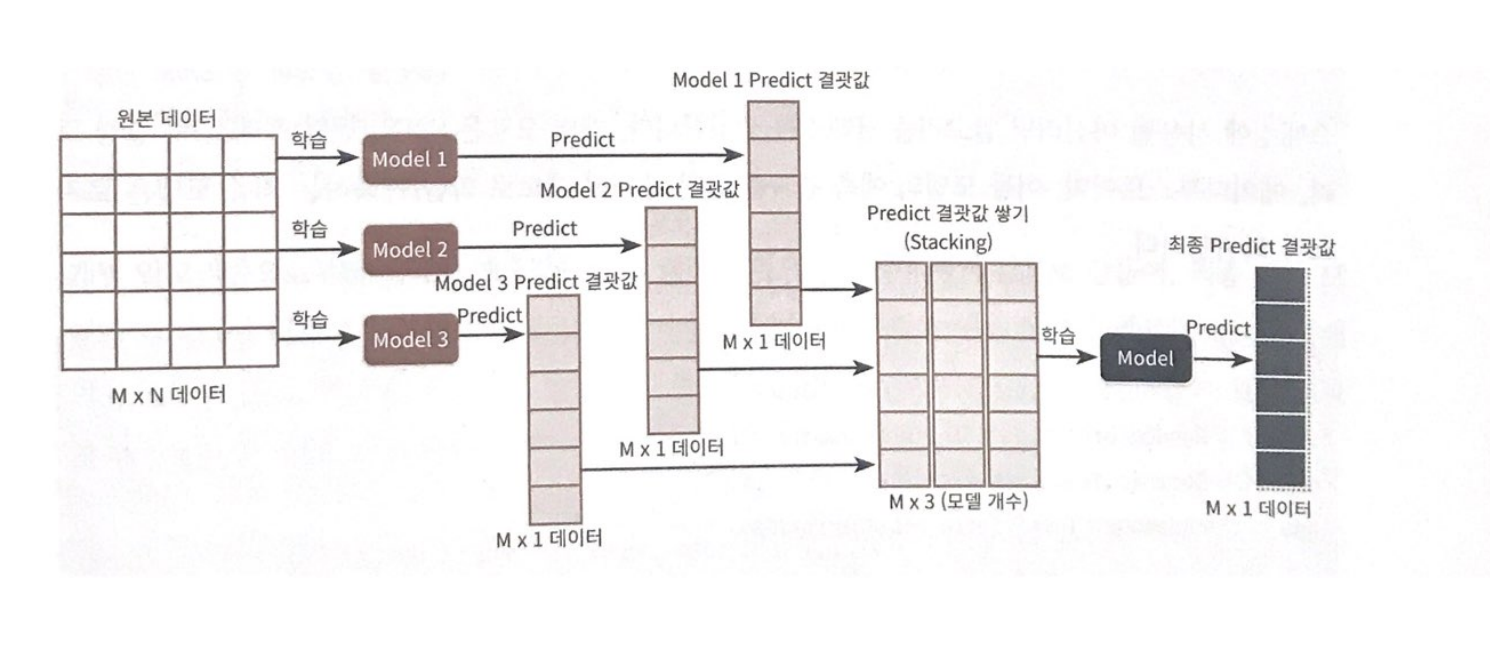

In [ ]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size = 0.2, random_state = 0)

In [ ]:
# 개별 ML 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors = 4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state = 0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators = 100)
gbm_clf = GradientBoostingClassifier()

# 스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델
lr_final = LogisticRegression()

In [ ]:
# 개별 모델들을 학습
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)
gbm_clf.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
# 학습된 개별 모델들이 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)
gbm_pred = gbm_clf.predict(X_test)

In [ ]:
# 개별 알고리즘으로부터 예측된 예측값을 칼럼 레벨로 옆으로 붙여서 피처 값을 만들어, 최종 메타 모델인 로지스틱 회귀에서 학습 데이터로 다시 사용
pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

pred = np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


In [ ]:
# 예측 데이터로 생성된 데이터 세트를 기반으로 최종 메타 모델인 로지스틱 회귀를 학습하고 예측 정확도 측정
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)

accuracy_score(y_test, final)

0.9736842105263158

### CV 세트 기반의 스태킹

CV 세트 기반의 스태킹 모델은 과적합을 개선하기 위해 최종 메타 모델을 위한 데이터 세트를 만들 때 교차 검증 기반으로 예측된 결과 데이터 세트를 이용함

CV 세트 기반의 스태킹은 과적합 문제 개선을 위해 개별 모델들이 각각 교차 검증으로 메타 모델을 위한 학습용 스태킹 데이터 생성과 예측을 위한 테스트용 스태킹 데이터를 생성한 뒤 이를 기반으로 메타 모델이 학습과 예측을 수행함

2단계 스텝
> - 스텝 1: 각 모델별로 원본 학습/테스트 데이터를 예측한 결과 값을 기반으로 메타 모델을 위한 학습용/테스트용 데이터를 생성
> - 스텝 2 : 스텝 1에서 개별 모델들이 생성한 학습용 데이터를 모두 스태킹 형태로 합쳐서 메타 모델이 예측할 최종 테스트 데이터 세트를 생성. 메타 모델은 최종적으로 생성된 학습 데이터 세트와 원본 학습 데이터의 레이블 데이터를 기반으로 학습한 뒤, 최종적으로 생성된 테스트 데이터 세트를 예측하고, 원본 테스트 데이터의 레이블 데이터를 기반으로 평가

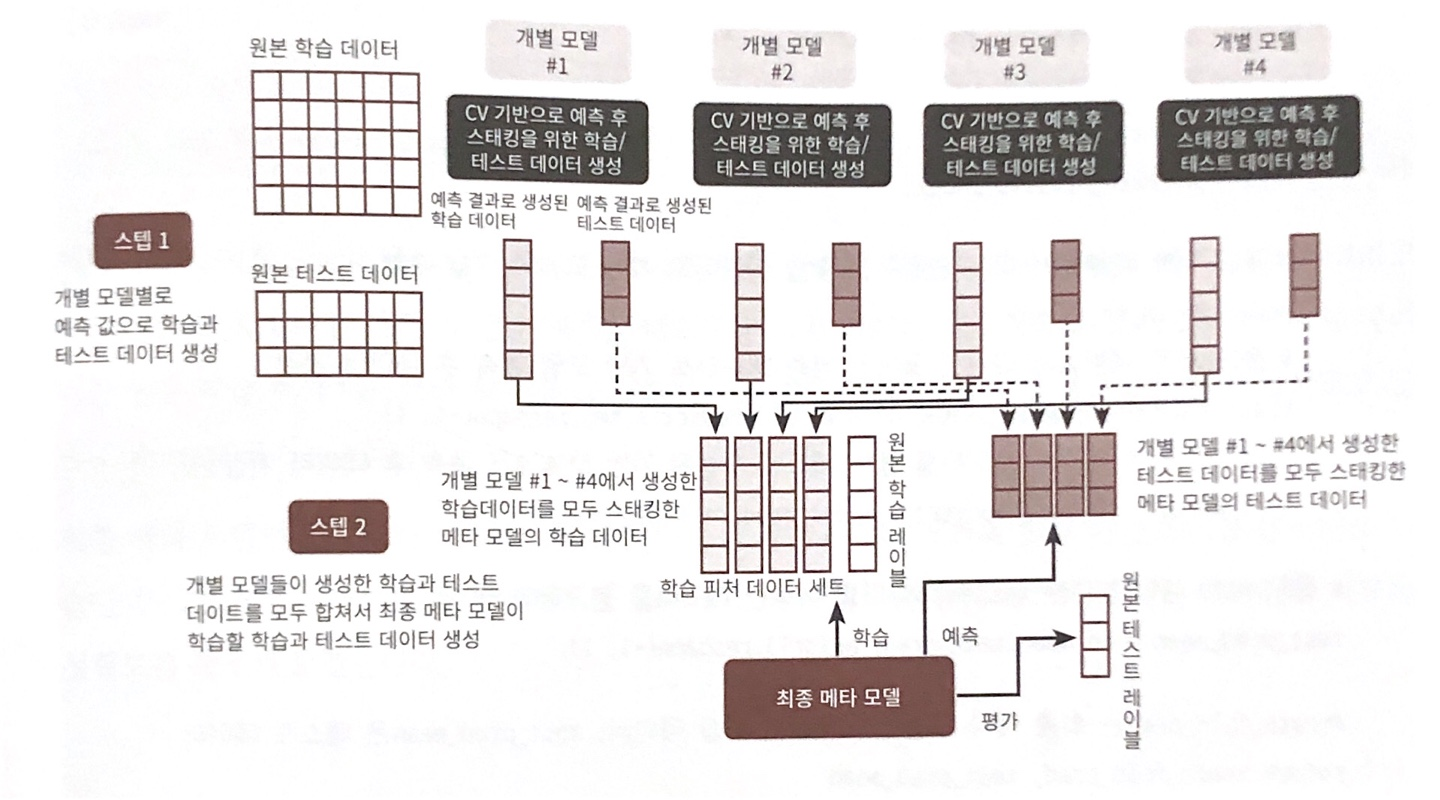

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
  # 지정된 n_folds값으로 KFold 생성
  kf = KFold(n_splits = n_folds, shuffle = False)
  # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
  train_fold_pred = np.zeros((X_train_n.shape[0], 1))
  test_pred = np.zeros((X_test_n.shape[0], n_folds))
  print(model.__class__.__name__, 'model 시작 ')

  for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
    # 입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출
    print('\t 폴드 세트 : ', folder_counter, '시작')
    X_tr = X_train_n[train_index]
    y_tr = y_train_n[train_index]
    X_te = X_train_n[valid_index]

    # 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
    model.fit(X_tr, y_tr)
    # 폴드 세트 네부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장
    train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1, 1)
    # 입력된 원본 테스트 데이터를 폴드 세트내 학습된 기반 모델이서 예측 후 데이터 저장
    test_pred[:, folder_counter] = model.predict(X_test_n)

  #폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
  test_pred_mean = np.mean(test_pred, axis = 1).reshape(-1, 1)

  # train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
  return train_fold_pred, test_pred_mean

In [ ]:
# 여러 개의 분류 모델별로 stack_base_model()함수 적용
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier model 시작 
	 폴드 세트 :  0 시작
	 폴드 세트 :  1 시작
	 폴드 세트 :  2 시작
	 폴드 세트 :  3 시작
	 폴드 세트 :  4 시작
	 폴드 세트 :  5 시작
	 폴드 세트 :  6 시작
RandomForestClassifier model 시작 
	 폴드 세트 :  0 시작
	 폴드 세트 :  1 시작
	 폴드 세트 :  2 시작
	 폴드 세트 :  3 시작
	 폴드 세트 :  4 시작
	 폴드 세트 :  5 시작
	 폴드 세트 :  6 시작
DecisionTreeClassifier model 시작 
	 폴드 세트 :  0 시작
	 폴드 세트 :  1 시작
	 폴드 세트 :  2 시작
	 폴드 세트 :  3 시작
	 폴드 세트 :  4 시작
	 폴드 세트 :  5 시작
	 폴드 세트 :  6 시작
AdaBoostClassifier model 시작 
	 폴드 세트 :  0 시작
	 폴드 세트 :  1 시작
	 폴드 세트 :  2 시작
	 폴드 세트 :  3 시작
	 폴드 세트 :  4 시작
	 폴드 세트 :  5 시작
	 폴드 세트 :  6 시작


In [ ]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis = 1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis = 1)
print(f'원본 학습 피처 데이터 Shape : {X_train.shape}, 원본 테스트 피처 Shape : {X_test.shape}')
print('스태킹 학습 피처 데이터 Shape : ', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape : ', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape : (455, 30), 원본 테스트 피처 Shape : (114, 30)
스태킹 학습 피처 데이터 Shape :  (455, 4) 스태킹 테스트 피처 데이터 Shape :  (114, 4)


In [ ]:
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)

accuracy_score(y_test, stack_final)

0.9736842105263158

# [4] 회귀

- 지도학습은 두 가지 유형으로 나뉘는데, 바로 분류와 회귀임
- 이 두 가지 기법의 가장 큰 차이는 분류는 예측값이 카테고리와 같은 이산형 클래스 값이고 회귀는 연속형 숫자라는 것

회귀 : 수치형

> - 단순회귀
> - 다중회귀
> - 로지스회귀
> - 다항회귀
> - 라쏘, 릿지 회귀



회귀는 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법

- 독립변수 : 피처
- 종속변수 : 결정 값
- 회귀계수(Regression coefficients) : 독립변수의 값에 영향을 미치는 계수



회귀에서 가장 중요한 것은 회귀 계수임

- 회귀 계수가 선형인지에 따라 선형 회귀와 비선형 회귀로 나눌 수 있음
- 독립 변수가 한 개인지 여러 개인지에 따라 단일 회귀, 다중 회귀로 나뉨


지도 학습은 분류와 회귀, 두 가지 유형으로 나뉨

- 분류 : 예측값이 카테고리와 같은 이산형 클래스
- 회귀 : 연속형 숫자값이 예측값임

선형 회귀는 실제 값과 예측값 차이(오류의 제곱 값)를 최소화하는 직선형 회귀선을 최적화하는 방식임


선형 회귀 모델은 규제(Regularization) 방법에 따라 다시 별도의 유형으로 나뉠 수 있음


규제는 일반적인 선형 회귀의 과적합 문제를 해결하기 위해서 회귀 계수에 페널티 값을 적용하는 것


<대표적인 선형 회귀 모델>

- 일반 선형 회귀 : 예측값과 실제 값의 RSS를 최소화 할 수 있도록 회귀 계수 최적화하며 규제 적용하지 않은 모델

- 릿지 : 선형 회귀에 L2 규제를 추가한 회귀 모델(L2 규제는 상대적으로 큰 회귀 계수의 예측 영향도를 감소시키기 위해 회귀 계수값을 더 작게 만드는 규제 모델)

- 라쏘 : 선형 회귀에 L1 규제를 적용한 방식(L1 규제는 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않게 하는 것으로 피처 선택 기능으로도 불림)

- 엘라스틱넷 : L2, L1 규제를 함께 결합한 모델(L2, L1 규제를 함께 결합한 모델)

- 로지스틱 회귀 : 사실은 분류에 사용되는 선형 모델임

## 1. 단순 션형 회귀를 통한 회귀 이해

단순 선형 회귀는 독립변수도 하나, 종속변수도 하나인 선형 회귀임

<1차 함수식 모델링>

y = w0 + w1 * X

> - 독립변수가 1개인 단순 선형 회귀에서는 이 기울기 w1과 절편 w0을 회귀 계수로 지칭함
> - 실제 값(Y)는 함수 값에서 실제 값만큼의 오차를 더한 값(w0 + w1 * X + 오류값)
> - 실제 값과 회귀 모델의 차이에 따른 오류 값을 남은 오류, 즉 잔차라고 부름

최적의 회귀 모델을 만든다는 것은 바로 전체 데이터의 잔차(오류값) 합이 최소가 되는 모델을 만든다는 의미

동시에 오류 값 합이 최소가 될 수 있는 최적의 회귀 계수를 찾는다는 의미임

> - 오류 값은 + 나 -가 될 수 있음
> - 전체 데이터의 오류 합을 구하기 위해 단순히 더했다가는 뜻하지 않게 오류 합이 크게 줄어들 수 있음
> - 보통 오류 합을 계산할 때는 절댓값을 취해서 더하거나(Mean Absolute Error),
> - 오류 값의 제곱을 구해서 더하는 방식을 취함(RSS, Residual Sum of Square)


RSS는 회귀식의 독립변수 X, 종속변수 Y가 중심 변수가 아니라 w 변수(회귀 계수)가 중심 변수임

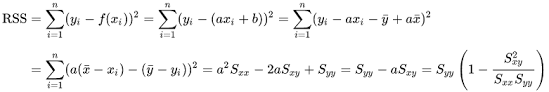

- 회귀에서 이 RSS는 비용(Cost)이며 w 변수(회귀 계수)로 구성되는 RSS를 비용 함수라고 함

- 머신러닝 회귀 알고리즘은 데이터를 계속 학습하면서 이 비용 함수가 반환하는 값(즉, 오류 값)을 지속해서 감소시키고 최종적으로는 더 이상 감소하지 않는 최소의 오류 값을 구하는 것

- 비용함수(Cost function) = 손실함수(Loss function) = 오차함수(Error function) = 목적함수(Objective function)

## 2. 비용 최소화하기 - 경사하강법(Gradient Descent)소개(313p 참고)

경사 하강법은 고차원 방정식에 대한 문제를 해결해 주면서 비용 함수 RSS를 최소화하는 방법을 직관적으로 제공하는 방식

점진적으로 반복적인 계산을 통해 W 파라미터 값을 업데이트하면서 오류 값이 최소가 되는 W 파라미터를 구하는 방식


- 경사 하강법은 반복적으로 비용함수의 반환 값(예측값 - 실제 값)이 작아지는 방향성을 가지고 W 파라미터를 지속해서 보정

- 오류 값이 더 이상 작아지지 않으면 그 오류 값을 최소 비용으로 판단하고 그 때의 W 값을 최적 파라미터로 반환



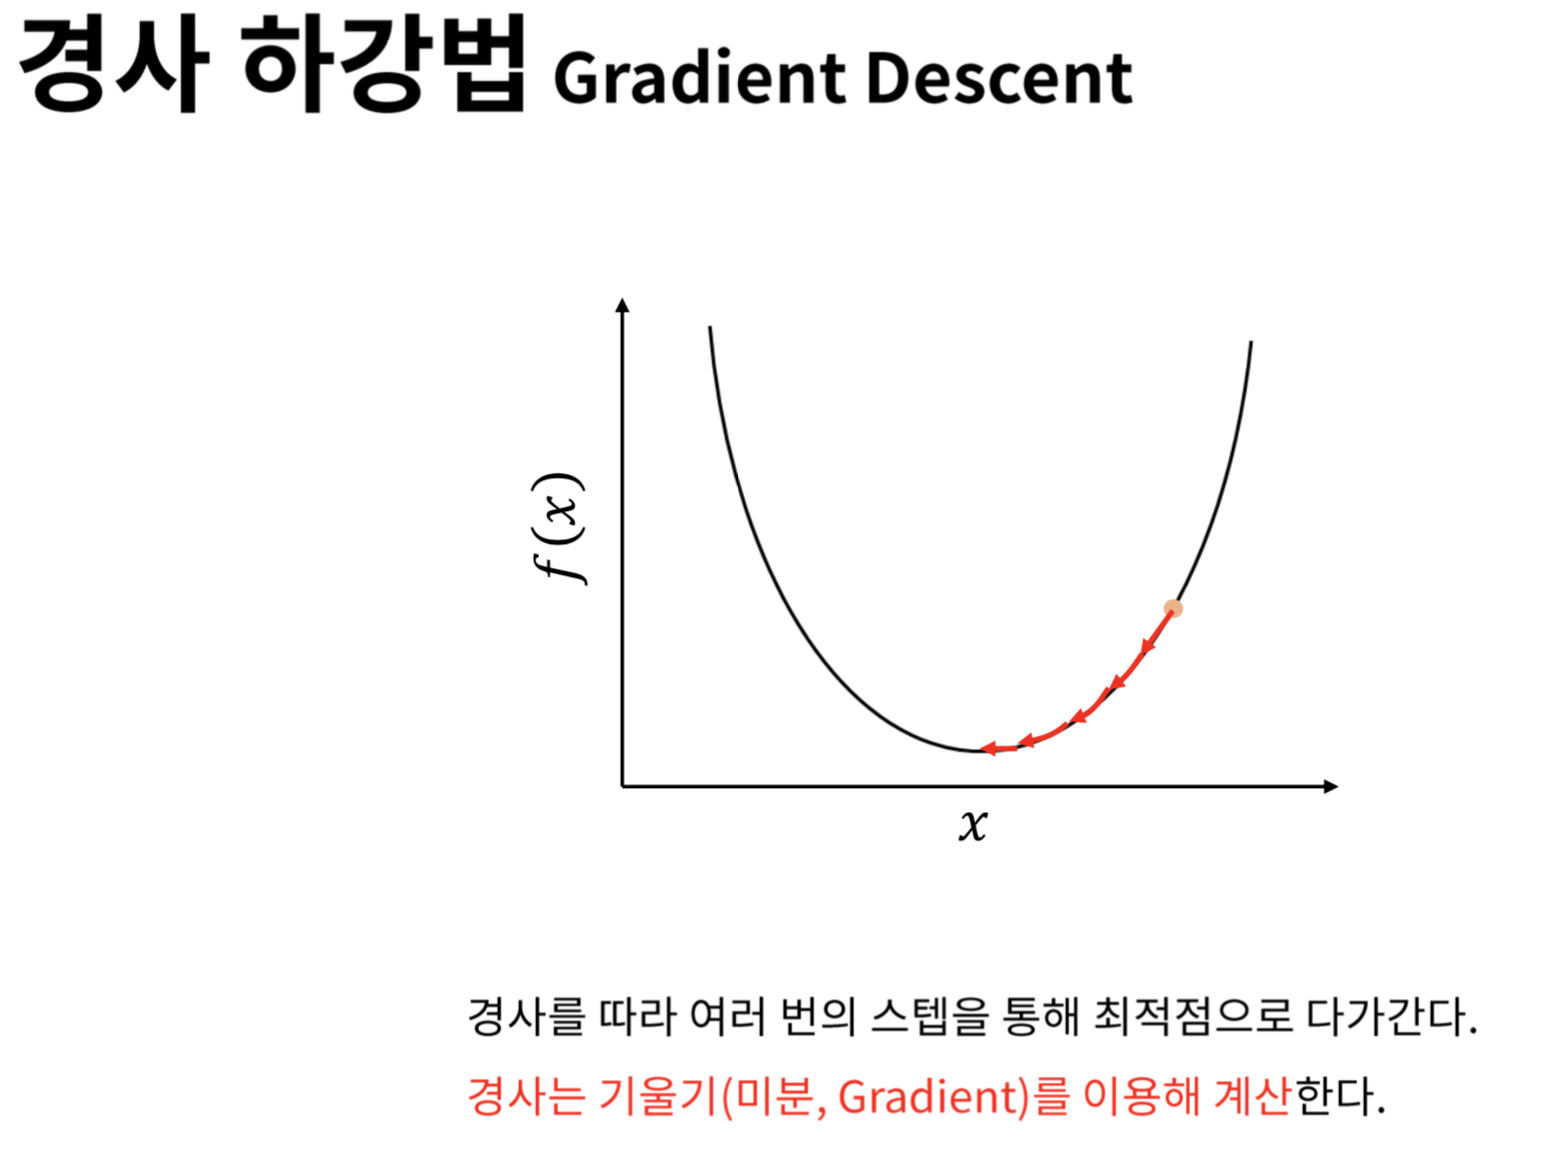

### 단순선형회귀

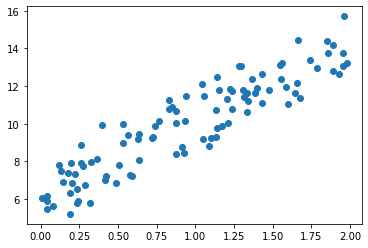

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4X + 6을 근사(w1 = 4, w0 = 6). 임의의 값은 노이즈를 위해 만듦
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)

# X, y 데이터 세트 산점도로 시각화
plt.scatter(X, y)

In [ ]:
# 비용 함수 정의하기 (실제값 - 예측값의 제곱들의 평균을 반환)
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)/N)
    return cost

In [ ]:
# 경사 하강법 구현하기
# w1과 w0를 업데이트 할 w1_update, w0_update를 반환
def get_weight_updates(w1, w0, X, y, learning_rate = 0.01):
    N = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y - y_pred

    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N, 1))

    # w1과 w0을 업데이트 할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))

    return w1_update, w0_update

In [ ]:
# get_weight_updates()를 경사 하강 방식으로 반복적으로 수행하여 w1과 w0를 업데이트하는 함수 생성
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함
def gradient_descent_steps(X, y, iters = 10000):
    # w0와 w1 모두 0으로 초기화
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate = 0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [ ]:
# gradient_descent_steps 호출해 w1과 w0 구하기
# 최종적으로 예측값과 실제값의 RSS 차이를 계산하는 get_cost() 함수 생성하고 이용해 경사 하강법의 예측 오류 계산하기
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters = 1000)
print(f'w1 : {w1[0, 0]}, w0 : {w0[0, 0]}')

y_pred = w1[0, 0] * X + w0

print(f'Gradient Descent Total Cost : {get_cost(y, y_pred)}')

w1 : 4.021813642697164, w0 : 6.162031224717461
Gradient Descent Total Cost : 0.9934784315632568


- 실제 선형식인 y = 4X + 6과 유사하게 w1 = 4.022, w0 = 6.162가 도출됨
- 예측 오류 비용은 약 0.9935임

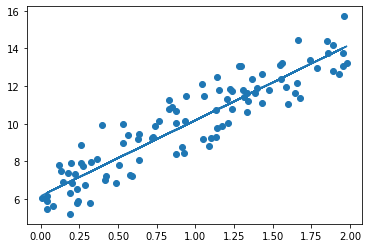

In [ ]:
# 앞에서 구한 y_pred에 기반해 회귀선 그리기
plt.scatter(X, y)
plt.plot(X, y_pred)

In [ ]:
# 확률적 경사 하강법 (stochastic_gradient_descent_steps())
def stochastic_gradient_descent_steps(X, y, batch_size = 10, iters = 1000):
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    prev_cost = 100000
    iter_index = 0

    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]

        # 랜덤하게 batch_size 만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate = 0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [ ]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters = 1000)
print(f'w1 : {round(w1[0, 0], 3)}, w0 : {round(w0[0, 0], 3)}')

y_pred = w1[0, 0] * X + w0
print('Stochastic Gradient Descent Total Cost : ', get_cost(y, y_pred))

w1 : 4.028, w0 : 6.156
Stochastic Gradient Descent Total Cost :  0.9937111256675345


- 경사 하강법은 수행 시간이 매우 오래 걸리므로 대부분 확률적 경사 하강법을 이용함
- 예측상의 성능 차이 없음

## 3. 사이킷런 LinearRegression

LinearRegression 클래스는 예측갑과 실제 값의 RSS(Residual Sum of Squares)를 최소화해 OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스임
- LinearRegression 클래스는 fit()메서드로 X, y 배열을 입력받으면 회귀계수(Coefficients)인 W를 coef_속성에 저장함

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept = True)  ## intercept y 절편으로 절편을 맞춰서 찾아주라는 의미

lr = model.fit(X, y)
lr

LinearRegression()

In [ ]:
lr.coef_   ## fit() 메서드를 수행했을 때 회귀 계수가 배열 형태로 저장하는 속성

array([[3.96846751]])

In [ ]:
X.shape

(100, 1)

<입력 파라미터>
- fit_intercept : 불린 값으로 intercept 값을 계산할 것인지 말지를 지정함. False일 때는 intercept가 사용되지 않고 0으로 지정됨
- normalize : 불린 값으로 fit_intercept가 False인 경우에는 이 파라미터가 무시됨. 만일 True이면 회귀를 수행하기 전에 입력 데이터 세트를 정규화 함

<속성>
- coef_ : fit() 메서드를 수행했을 때 회귀 계수가 배열 형태로 저장하는 속성
- intercept_ : intercept 값

Ordinaty Least Square 기반의 회귀 계수 계산은 입력 피처의 독립성에 많은 영향을 받음

피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져서 오류에 매우 민감해짐

이러한 현상을 다중 공선성(multi-collinearity) 문제라고 함

### 회귀 평가 지표
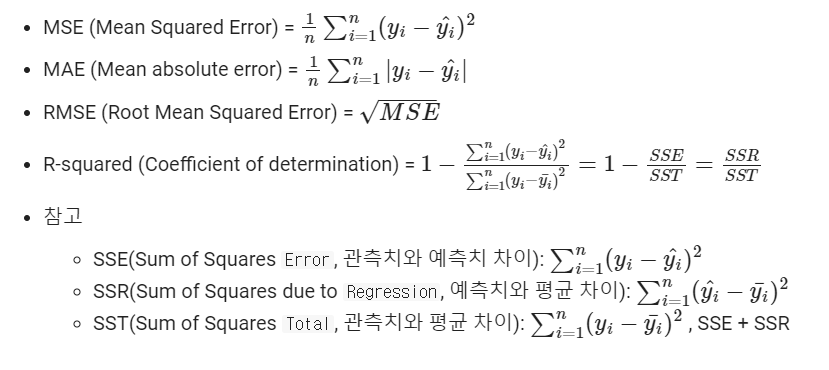

### LinearRegressoin을 이용해 보스턴 주택 가격 회귀 구현


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
# 데이터셋 로드
boston = load_boston()

# 데이터 세트를 데이터 프레임으로 반환
boston_df = pd.DataFrame(boston.data, columns = boston.feature_names)

# boston 데이터 세트의 target 배열은 주택 가격임. 이를 PRICE 칼름으로 df에 추가
boston_df['PRICE'] = boston.target
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


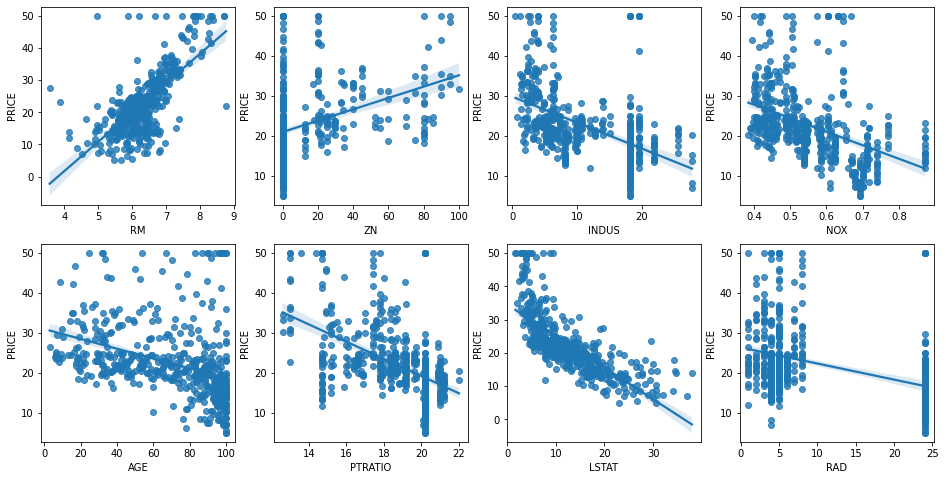

In [ ]:
# 2개의 행과 4개의 열을 가진 subplot를 이용 axs는 4x2개의 ax 가짐
fig, axs = plt.subplots(figsize = (16, 8), ncols = 4, nrows = 2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x = feature, y = 'PRICE', data = boston_df, ax = axs[row][col])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = boston_df['PRICE']
X_data = boston_df.drop(['PRICE'], axis = 1, inplace = False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size = .3, random_state = 156)

# 선형 회귀 OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train, y_train)

y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print(f'MSE : {mse}, RMSE : {rmse}')
print('Variance Score : ', r2_score(y_test, y_preds))

MSE : 17.296915907902022, RMSE : 4.158956107955699
Variance Score :  0.7572263323138939


In [ ]:
print('절편 값 : ', lr.intercept_)
print('회귀 계수값 : ', np.round(lr.coef_, 1))

절편 값 :  40.99559517216477
회귀 계수값 :  [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [ ]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series 생성 (인덱스 칼럼명에 유의)
coeff = pd.Series(data = np.round(lr.coef_, 1), index = X_data.columns)
coeff.sort_values(ascending = False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
AGE         0.0
TAX        -0.0
B           0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [ ]:
from sklearn.model_selection import cross_val_score

y_target = boston_df['PRICE']
X_data = boston_df.drop(['PRICE'], axis = 1, inplace = False)
lr = LinearRegression()

# cross_val_score로 5폴드 세트로 MSE 구한뒤 이를 기반으로 RMSE 구함
# cross_val_score은 클수록 좋고 mean_squared_error는 작을수록 좋으므로 negative을 붙임
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring = 'neg_mean_squared_error')로 반환된 값은 모두 음수
print(f'5 folds 의 개별 Negative MSE scores : {np.round(neg_mse_scores, 2)}')
print(f'5 folds 의 개별 RMSE scores : {np.round(rmse_scores, 2)}')
print(f'5 folds 의 평균 RMSE : {avg_rmse}')

5 folds 의 개별 Negative MSE scores : [-12.46 -26.05 -33.07 -80.76 -33.31]
5 folds 의 개별 RMSE scores : [3.53 5.1  5.75 8.99 5.77]
5 folds 의 평균 RMSE : 5.828658946215802


## 4. 다항 회귀와 과(대)적합/과소적합 이해

w0 + w1x1 + w2x2 + w3x3 + w4x4 : 다중회귀

w0 + w1x^1 + w2x^2 + w3x^3 + w4x^4 : 다항회귀

- degree : 치수

- 다항 회귀도 선형 회귀임
- 회귀에서 선형 회귀/비선형 회귀를 나누는 기준은 회귀 계수가 선형/비선형인지에 따르는 것이지 독립변수의 선형/비선형 여부와는 무관함

In [ ]:
## [x1, x2]를 2차 다항값으로 변환 [1, x1, x2, x1^2, x1x2, x2^2]
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0, 1], [2, 3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처 :\n', X)

# degree = 2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures(degree = 2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 피처 :\n', poly_ftr)

일차 단항식 계수 피처 :
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처 :
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [ ]:
def polynomial_func(X):
    y = 1 + 2*X[:, 0] + 3*X[:, 0]**2 + 4*X[:, 1]**3
    return y

X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처 :\n', X)

y = polynomial_func(X)
print('3차 다항식 결정값 :\n', y)

일차 단항식 계수 피처 :
 [[0 1]
 [2 3]]
3차 다항식 결정값 :
 [  5 125]


In [ ]:
# 3차 다항식 변환
# [x1, x2] -> [1, x1, x2, x1^2, x1x2, x2^2, x1^3, x1^2x2, x1x2^2, x1^3]
poly_ftr = PolynomialFeatures(degree = 3).fit_transform(X)
print('3차 다항식 계수 :\n', poly_ftr)

# LinearRegression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr, y)
print(f'Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print(f'Polynomial 회귀 Shape : ', model.coef_.shape)

3차 다항식 계수 :
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape :  (10,)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline   ## 순서대로 적혀진 것들이 실행되게 만들어주는 클래스임
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:, 0] + 3*X[:, 0]**2 + 4*X[:, 1]**3
    return y

# Pipeline 객체로 Streamline하게 Polynomial Feature 변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree = 3)),
                 ('linear', LinearRegression())])

X = np.arange(4).reshape(2, 2)
y = polynomial_func(X)

model = model.fit(X, y)

print('Polynomial 회귀 계수 : ', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수 :  [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해
다항 회귀는 피처의 직선적 관계가 아닌 복잡한 다항 관계를 모델링할 수 있음

다항식 차구가 높아질수록 매우 복잡한 피처 간의 관계까지 모델링이 가능함

하지만 다항 회귀의 차수(degree)를 높일수록 학습 데이터에만 너무 맞춘 학습이 이뤄져서 정작 테스트 데이터 환경에서는 오히려 예측 정확도가 떨어짐

즉, 차수가 높아질수록 과적합 문제가 크게 발생함

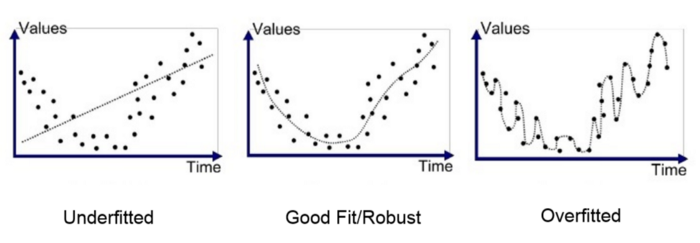

### 편향-분산 트레이드오프(Bias-Variance Trade Off)

일반적으로 편향과 분산은 한 쪽이 높으면 한 쪽이 낮아지는 경향이 있음

즉, 편향이 높으면 분산은 낮아지고(과소적합) 반대로 분산이 높으면 편항이 낮아짐(과적합)

높은 편향/낮은 분산에서 과소적합되기 쉬우며 낮은 편향/높은 분산에서 과적합되기 쉬움

편향과 분산이 서로 트레이드오프를 이루면서 오류 Cost 값이 최대로 낮아지는 모델을 구축하는 것이 가장 효율적인 머신러닝 예측 모델을 만드는 방법임

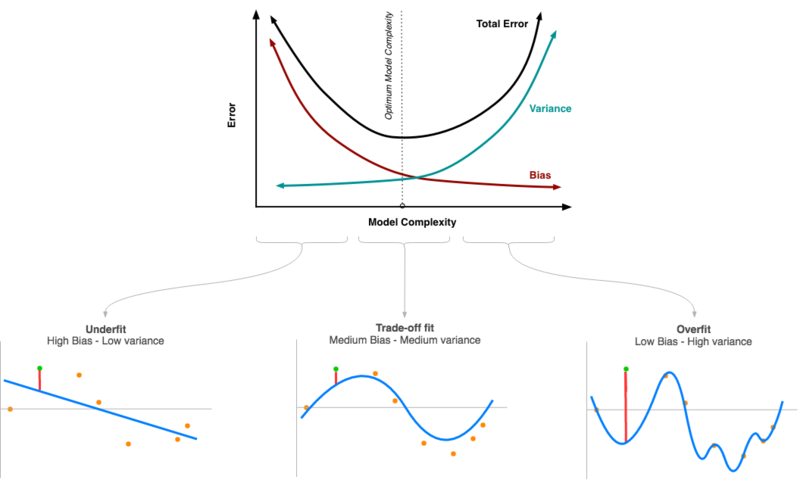

## 5. 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

### 릿지 회귀
- L2 규제 적용한 회귀
- W 제곱에 페널티를 부여하는 방식

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha = 10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(neg_mse_scores)
print(rmse_scores)
print(avg_rmse)

[-11.4217962  -24.29446706 -28.14355069 -74.59916618 -28.51714218]
[3.3796148  4.92894178 5.30504955 8.63708088 5.3401444 ]
5.518166280868968


### 라쏘 회귀
- L1 규제 적용한 회귀
- 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거
- 적절한 피처만 회귀에 포함시키는 피처 선택의 특성을 갖고 있음

In [ ]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):
  coeff_df = pd.DataFrame()
  if verbose : print('######', model_name, '######')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha = param)
    elif model_name == 'Lasso' : model = Lasso(alpha = param)
    elif model_name == 'ElasticNet' : model = ElasticNet(alpha = param, l1_ratio = 0.7)
    neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = 'neg_mean_squared_error', cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print(f'alpha {param}일 때 5 폴드 세트의 평균 RMSE : {avg_rmse}')
    # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

    model.fit(X_data_n, y_target_n)
    if return_coeff:
      # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
      coeff = pd.Series(data = model.coef_, index = X_data_n.columns)
      colname = 'alpha:'+str(param)
      coeff_df[colname] = coeff

  return coeff_df

In [ ]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params = lasso_alphas, X_data_n = X_data, y_target_n = y_target)
coeff_lasso_df

###### Lasso ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.612284267526676
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.615116035266935
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.6691234095948975
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.776020813823375
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.188763210800905


,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
CRIM,-0.098193,-0.097894,-0.083289,-0.063437,-0.000000
ZN,0.049059,0.049211,0.049544,0.049165,0.037231
INDUS,-0.042120,-0.036619,-0.005253,-0.000000,-0.000000
CHAS,1.434343,0.955190,0.000000,0.000000,0.000000
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
RM,3.789725,3.703202,2.498212,0.949811,0.000000
AGE,-0.011706,-0.010037,0.003604,0.020910,0.042495
DIS,-1.176583,-1.160538,-0.936605,-0.668790,-0.000000
RAD,0.270936,0.274707,0.277451,0.264206,0.061864
TAX,-0.014290,-0.014570,-0.015442,-0.015212,-0.008602


### 엘라스틱넷 회귀
- L2 규제와 L1 규제 결합한 회귀
- 엘라스틱넷은 라쏘 회귀가 서로 상관관계가 높은 피처들의 경우에 이들 중에서 중요 피처만을 셀렉션하고 다른 피처들은 모두 회귀 계수를 0으로 만드는 성향이 강함
- 이러한 성향으로 alpha 값에 따라 회귀 계수의 값이 급격히 변동할 수도 있는데, 엘라스틱넷 회귀는 이를 완화하기 위해 L2 규제를 라쏘 회귀에 추가한 것

In [ ]:
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params = elastic_alphas, X_data_n = X_data, y_target_n = y_target)
coeff_elastic_df

###### ElasticNet ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.541654347348139
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.52592849629491
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.466748649445586
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.596874445109748
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.068121638621163


,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
CRIM,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
ZN,0.050107,0.050617,0.052878,0.052136,0.038268
INDUS,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
CHAS,1.330724,0.979706,0.000000,0.000000,0.000000
NOX,-0.175072,-0.000000,-0.000000,-0.000000,-0.000000
RM,3.574162,3.414154,1.918419,0.938789,0.000000
AGE,-0.010116,-0.008276,0.007760,0.020348,0.043446
DIS,-1.189438,-1.173647,-0.975902,-0.725174,-0.031208
RAD,0.278880,0.283443,0.300761,0.289299,0.146846
TAX,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417


다양한 규제 선형 회귀들 중 어떤 것이 가장 좋은 지는 상황에 따라 다름

각각의 알고리즘에서 하이퍼 파라미터를 변경해가면서 최적의 예측 성능을 찾아내야 함

선형 회귀의 경우 최적의 하이퍼 파라미터를 찾아내는 것 못지않게 먼저 데이터 분포도의 정규화와 인코딩 방법이 매우 중요함

### 선형 회귀 모델을 위한 데이터 변환

선형 회귀 모델과 같은 선형 모델은 일반적으로 피처와 타깃값 간에 선형 관계가 있다고 가정하고, 이러한 최적의 선형함수를 찾아내 결괏값을 예측

- 선형 회귀 모델은 피처값과 타깃값의 분포가 정규 분포 형태를 선호함
- 특정값의 분포가 치우친 왜곡된(skew) 형태의 분포도일 경우 예측 성능에 부정적인 영향을 미칠 가능성이 높음
- 따라서 선형 회귀 모델을 적용하기 전에 먼저 데이터에 대한 스케일링/정규화 작업을 수행하는 것이 일반적임


일반적으로 피처 데이터 세트와 타깃 데이터 세트에 이러한 스케일링/정규화 작업을 수행하는 방법이 조금은 다름

<피처 데이터 세트에 적용하는 변환 작업>

- StandardScaler OR MinMaxScaler
- 스케일링/정규화를 수행한 데이터 세트에 다히 다항 특성을 적용하여 반환
- 원래 값에 log 함수를 적용하면 정규 분포에 가까운 형태로 값이 분포됨(많이 이용되는 방법)

In [ ]:
# method는 표준 정규 분포 변환(Standard), 최대값/최솟값 정규화(MinMax), 로그변환(log) 결정
# p_degree는 다항식 특성을 추가할 때 적용. p_degree는 2 이상 부여하지 않음
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def get_scaled_data(method = 'None', p_degree = None, input_data = None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree = p_degree, include_bias = False).fit_transform(scaled_data)

    return scaled_data

In [ ]:
from sklearn.linear_model import Lasso, ElasticNet, Ridge

# alpha 값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):
    coeff_df = pd.DataFrame()

    if verbose : print('###### ', model_name, '######')

    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha = param)
        elif model_name == 'Lasso' : model = Lass(alpha = param)
        elif model_name == 'ElasticNet' : model = ElasticNet(alpha = param, l1_ratio = 0.7)

        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = 'neg_mean_squared_error', cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))

        print(f'alpha {param}일 때 5 폴드 세트의 평균 RMSE : {avg_rmse}')
        # corss_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
            coeff = pd.Series(data = model.coef_, index = X_data_n.columns)
            colname = 'alpha:' + str(param)
            coeff_df[colname] = coeff

        return coeff_df

In [ ]:
from sklearn.datasets import load_boston

boston = load_boston()

boston_df = pd.DataFrame(boston.data, columns = boston.feature_names)
boston_df['PRICE'] = boston.target

y_target = boston_df['PRICE']
X_data = boston_df.drop(['PRICE'], axis = 1, inplace = False)

In [ ]:
#### Ridge 클래스의 alpha 값을 변화시키면서 피치 데이터 세트를 여러 가지 방법으로 변환한 데이터 세트를 입력받을 경우 RMSE 값이 어떻게 변하는지 살펴보기

# Ridge의 alpha 값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규 분포, 표준정규 분포 + 다항식 특성
# 최대/최소 정규화, 최대/최소 정규화 + 다항식 특성, 로그변환
scale_methods = [(None, None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax', 2), ('Log', None)]

for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method = scale_method[0], p_degree = scale_method[1], input_data = X_data)

    print(f'\n## 변환 유형 : {scale_method[0]}, Polynomial Degree : {scale_method[1]}')
    get_linear_reg_eval('Ridge', params = alphas, X_data_n = X_data_scaled, y_target_n = y_target, verbose = False, return_coeff = False)


## 변환 유형 : None, Polynomial Degree : None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.7884866270324125

## 변환 유형 : Standard, Polynomial Degree : None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.825992799389438

## 변환 유형 : Standard, Polynomial Degree : 2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 8.827235873000179

## 변환 유형 : MinMax, Polynomial Degree : None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.763570225288303

## 변환 유형 : MinMax, Polynomial Degree : 2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.297560003127215

## 변환 유형 : Log, Polynomial Degree : None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 4.77042961468166


일반적으로 선형 회귀를 적용하려는 데이터 세트에 데이터 값의 분포가 심하게 왜곡되어 있을 경우에 이처럼 로그 변환을 적용하는 것이 좋은 결과를 기대할 수 있음


## 6. 로지스틱 회귀

로지스틱 회귀는 선형 회귀 방식을 분류에 적용한 알고리즘임 (선형 회귀 계열)

선형 함수가 아닌 시그모이드 함수 최적선을 찾고 이 시그모이드 함수의 반환값을 확률로 간주해 확률에 따라 분류를 결정함
> - S자 커브를 가짐
> - 시그모이드 함수의 정의는 y = 1/1 + e^(-1)
> - 시그모이드 함수는 X 값이 아무리 커지거나 작아져도 y값은 항상 0과 1 사이의 값을 반환함
> - x값이 커지면 1에 근사하며 x값이 작아지면 0에 근사함
> - x값이 0일 때에는 0.5임

로지스틱 회귀는 이처럼 선형 회귀 방식을 기반으로 하되 시그모이드 함수를 이용해 분류를 수행하는 회귀임

사이킷런은 로지스틱 회귀를 위해서 LogisticRegression 클래스를 제공함

<solver 파라미터>

> - lbfgs
> - liblinear
> - newton-cg
> - sag
> - saga

일반적으로 lbfgs 또는 liblinear를 선택하는 것이 대부분임

In [ ]:
# LogisticRegression 클래스 사용을 통한 암 여부 판단
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
## 표준 스케일링 후 데이터 세트 분리
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size= .3, random_state = 0)

In [ ]:
## 로지스틱 회귀를 이용해 학습 및 예측을 수행하고, 정확도와 ROC-AUC 값을 구하기
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행
# solver 인자값을 생성자로 입력하지 않으면 solver = 'lbfgs'
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

lr_preds = lr_clf.predict(X_test)

# accuracy와 roc-auc 측정
print(accuracy_score(y_test, lr_preds))
print(roc_auc_score(y_test, lr_preds))

0.9766081871345029
0.9715608465608465


- 사이킷런 LogisticRegression 클래스의 주요 하이퍼 파라미터로 penalty와 C가 있습니다.
- penalty는 규제(Regularization)의 유형을 설정하여 'l2'로 설정 시 L2 규제를, 'l1'으로 설정 시 L1 규제를 뜻함.
- C는 규제 강도를 조절하는 alpha 값의 역수임(C 값이 작을수록 규제 강도가 큼)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'solver' : ['liblinear', 'lbfgs'],
         'penalty' : ['l1', 'l2'],
         'C' : [0.01, 0.1, 1, 1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = 'accuracy', cv = 3)
grid_clf.fit(data_scaled, cancer.target)

print(grid_clf.best_params_)
print(grid_clf.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.9789102385593614


- 로지스틱 회귀는 가볍고 빠르지만, 이진 분류 예측 성능도 뛰어남
- 이 때문에 로지스틱 회귀를 이진 분류의 기본 모델로 사용하는 경우가 많음
- 또한 로지스틱 회귀는 희소한 데이터 세트 분류에도 뛰어난 성능을 보여서 텍스트 분류에서도 자주 사용됨


## 7. 회귀 트리(355p 참조)

결정 트리와 같이 트리를 기반으로 하는 회귀 방식

결정 트리, 랜덤 포레스트, GBM, XGBoost, LightGBM 등의 앞에서 소개한 모든 트리 기반의 알고리즘은 분류 뿐만 아니라 회귀도 가능함

사이킷런에서는 결정 트리, 랜덤 포레스트, GBM에서 CART 기반의 회귀 수해을 할 수 있는 Estimator 제공
트리 기반 회귀와 분류의 Estimator 클래스

- 알고리즘 - 회귀 Estimator 클래스 - 분류 Estimator 클래스 순

> - Decision Tree - DecisionTreeRegressor - DecisionTreeClassifier
> - Gradient Boosting - GradientBoostingRegressor - GradientBoostingClassifier
> - XGBoost - XGBRegressor - XGBClassifier
> - LightGBM - LGBMRegressor - LGBMClassifier


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 0, n_estimators = 100)
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(neg_mse_scores)
print(rmse_scores)
print(avg_rmse)

[ -8.04382131 -13.57626003 -18.16442825 -47.62156459 -20.45226132]
[2.83616313 3.68459768 4.26197469 6.90083796 4.52241764]
4.441198220092327


In [ ]:
## 입력 모델과 데이터 세트를 입력받아 교차 검증으로 평균 RMSE를 계산해주는 함수
def get_model_cv_prediction(model, X_data, y_target):
    neg_mse_scores = cross_val_score(model, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print('######', model.__class__.__name__, '######')
    print(f'5 교차 검증의 평균 RMSE : {avg_rmse}')


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state = 0, max_depth = 4)
rf_reg = RandomForestRegressor(random_state = 0, n_estimators = 1000)
gb_reg = GradientBoostingRegressor(random_state = 0, n_estimators = 1000)
xgb_reg = XGBRegressor(n_estimators = 1000)
lgb_reg = LGBMRegressor(n_estimators = 1000)

# 트리 기반의 회귀 모델을 반복하면서 평가 수행
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
    get_model_cv_prediction(model, X_data, y_target)

###### DecisionTreeRegressor ######
5 교차 검증의 평균 RMSE : 5.977957424580515
###### RandomForestRegressor ######
5 교차 검증의 평균 RMSE : 4.422538982804892
###### GradientBoostingRegressor ######
5 교차 검증의 평균 RMSE : 4.26899822168126
[15:58:17] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:58:17] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:58:18] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:58:18] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:58:18] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
###### XGBRegressor ######
5 교차 검증의 평균 RMSE : 4.088922560380566
###### LGBMRegressor ######
5 교차 검증의 평균 RMSE : 4.646441191925675


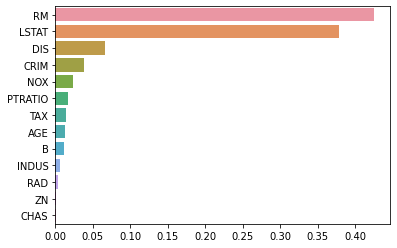

In [ ]:
### 보스턴 주택 가격 모델의 피처별 중요도 시각화
import seaborn as sns
%matplotlib inline

rf_reg = RandomForestRegressor(n_estimators = 1000)

# 앞 예제에서 만들어진 X_data, y_target 데이터 세트를 적용해 학습
rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data = rf_reg.feature_importances_, index = X_data.columns)
feature_series = feature_series.sort_values(ascending = False)
sns.barplot(x = feature_series, y = feature_series.index)

# [5] 차원축소

차원 축소는 매우 많은 피처로 구성된 다차원 데이터 세트의 차원을 축소해 새로운 차원의 데이터 세트를 생성하는 것

- 일반적으로 차원이 증가할수록 데이터 포인트 간의 거리가 기하급수적으로 멀어지게 되고, 희소(sparse)한 구조를 가짐
- 수백 개 이상의 피처로 구성된 데이터 세트의 경우 상대적으로 적은 차원에서 학습된 모델보다 예측 신뢰도 떨어짐
- 피처가 많을 경우 개별 피처 간의 상관관계가 높은 가능성이 큼
- 선형 회귀와 같은 선형 모델에서는 입력 변수 간의 상관관계가 높을 경우 이로 인한 다중 공선성 문제로 모델의 예측 성능이 저하됨

이렇게 매우 많은 다차원의 피처를 차원 축소해 피처 수를 줄이면 더 직관적으로 데이터를 해석할 수 있음



일반적으로 차원 축소는 피처 선택(feature selection)과 피처 추출(feature extraction)으로 나눌 수 있음

- 피처 선택(특성 선택) : 특정 피처에 종속성이 강한 불필요한 피처는 아예 제거하고, 데이터의 특징을 잘 나타내느 주요 피처만 선택하는 것
- 피처(특성) 추출 : 기존 피처를 저차원의 중요 피처로 압축해서 추출하는 것


피처 추출은 기존 피처를 단순 압축이 아닌, 피처를 함축적으로 더 잘 설명할 수 있는 또 다른 공간으로 매핑해 추출하는 것임

대표적으로 PCA, SVD, NMF는 데이터를 잘 설명할 수 있는 잠재적인 요소를 추출하는 대표적인 차원 축소 알고리즘임

SVD와 NMF은 시맨틱 통픽(Semantic Topic) 모델링을 위한 기반 알고리즘으로 사용됨

## 1. PCA(Principal Component Analysis)

PCA(Principal Component Analysis)는 가장 대표적인 차원 축소 기법으로 여러 변수 간에 존재하는 상관관계를 이용해 이를 대표하는 주성분(Principa Component)을 추출해 차원을 축소하는 기법임
- 정보 유실 최소화
- 가장 높은 분산을 가지는 데이터의 축을 찾아 이 축으로 차원을 축소하는데, 이것이 PCA의 주성분이 됨
- 분산이 데이터 특성을 가장 잘 나타내는 것으로 간주함
- 데이터 변동성이 가장 큰 방향으로 축을 생성하고, 새롭게 생성된 축으로 데이터를 투영하는 방식

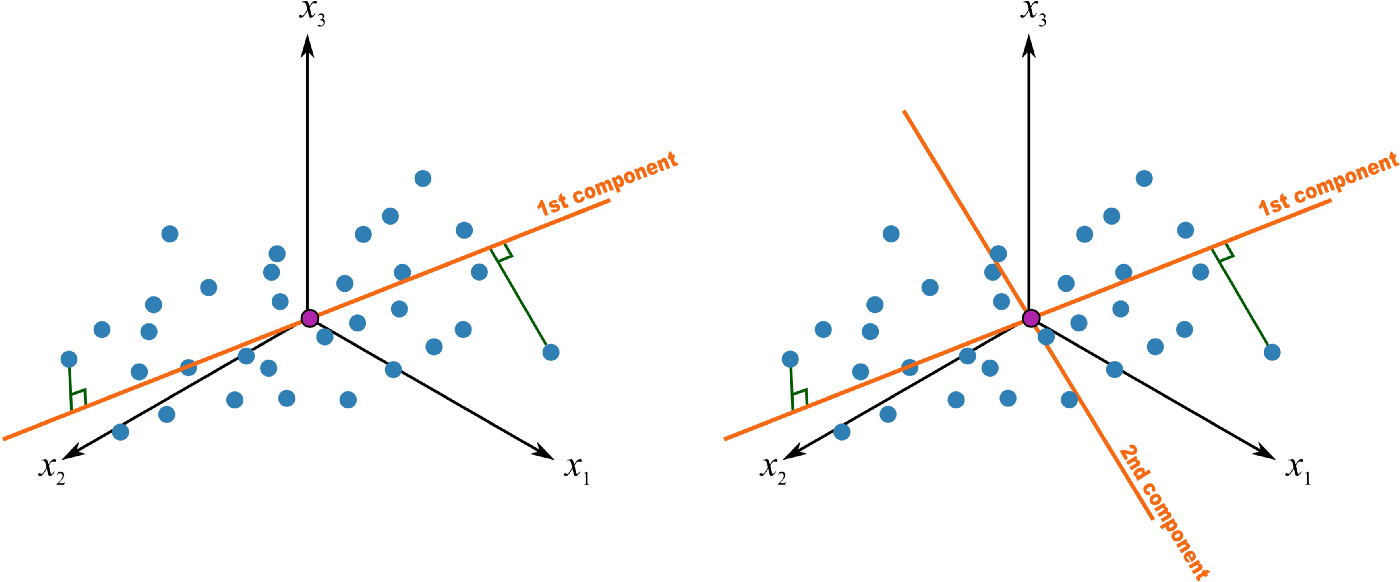

- 제일 먼저 가장 큰 데이터 변동성(Variance)를 기반으로 첫 번째 축을 생성
- 두 번째 축은 이 벡터 축에 직각이 되는 벡터(직교 벡터)를 축으로 함
- 세 번째 축은 다시 두 번째 축과 직각이 되는 벡터를 설정하는 방식으로 축을 생성

PCA는 원본 데이터의 피처 개수에 비해 매우 작은 주성분으로 원본 데이터의 총 변동성을 대부분 설명할 수 있는 분석법
- 입력 데이터의 공분산 행렬(Covariance Matrix)을 고유값 분해하고, 이렇게 구한 고유벡터에 입력 데이터를 선형 변환하는 것

> - 고유값 : 고유 벡터의 크기
> - 선형 변환 : 특정 벡터에 행렬 A를 곱해 새로운 벡터로 변환하는 것을 의미
> - 공분산 행렬 : 여러 변수와 공분산을 포함하는 정방형 행렬(2개의 확률 변수의 선형 관계를 나타내는 값)
> - 고유 벡터 : 행렬 A를 곱하더라고 방향이 변하지 않고 그 크기만 변하는 벡터

입력 데이터의 공분산 행렬이 고유벡터와 고유값으로 분해될 수 있으며, 이렇게 분해된 고유벡터를 이용해 입력 데이터를 선형 변환하는 방식이 PCA임
> 1. 입력 데이터 세트의 공분산 행렬을 생성
> 2. 공분산 행렬의 고유벡터와 고유값을 계산
> 3. 고유값이 가장 큰 순으로 K개(PCA 변환 차수만큼)만큼 고유벡터를 추출
> 4. 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터를 변환

In [ ]:
## 차원 축소 PCA 기법
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()

X = iris.data
y = iris.target

# scaling 하기 (target 값을 제외하고 StandardScaler를 이용해 표준 정규 분포를 가지는 값들로 변환)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [ ]:
## PCA 클래스 불러와서 변환하기
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)
X_pca[:5]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538]])

In [ ]:
## explained_variance_ratio_ 속성은 전체 변동성에서 개별 PCA 컴포넌트별로 차지하는 변동성 비율을 제공
## 앞 4개 차원의 데이터를 2개 차원으로 줄이면서 두 데이터의 변동성 비율을 기반으로 첫 번째 주 축(긴 축) 설정

pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [ ]:
## 분류하고 결과 반환하기
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state = 156)
scores = cross_val_score(rcf, X_scaled, y, scoring = 'accuracy', cv = 3)
print(f'원본 데이터 교차 검증 개별 정확도 : {scores}')
print(f'원본 데이터 평균 정확도 : {np.mean(scores)}')


pca_scores = cross_val_score(rcf, X_pca, y, scoring = 'accuracy', cv = 3)
print(f'PCA 변환 데이터 교차 검증 개별 정확도 : {pca_scores}')
print(f'PCA 변환 데이터 평균 정확도 : {np.mean(pca_scores)}')

원본 데이터 교차 검증 개별 정확도 : [0.98 0.94 0.96]
원본 데이터 평균 정확도 : 0.96
PCA 변환 데이터 교차 검증 개별 정확도 : [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도 : 0.88


## 2. LDA(Linear Discriminant Analysis)

LDA(Linear Discriminant Analysis)는 선형 판별 분석법으로 불리며, PCA와 매우 유사함
- 입력 데이터의 결정 값 클래스를 최대한으로 분리할 수 있는 축을 찾음
- 클래스 간 분산(between-class scatter)과 클래스 내부 분산(within-class scatter)의 비율을 최대화하는 방식으로 차원을 축소
- 클래스 간 분산은 최대한 크게 가져가고, 클래스 내부의 분산은 최대한 작게 가져가는 방식임
- 한 클래스 간 분산과 클래스 내부 분산 행렬을 생성한 뒤, 이 행렬에 기반해 고유벡터를 구하고 입력 데이터를 투영함

LDA 프로세스
> 1. 클래스 내부와 클래스 간 분산 행렬을 구함. 이 두 개의 행렬은 입력 데이터의 결정값 클래스별로 개별 치의 평균 벡터를 기반으로 구함
> 2. 클래스 내부 분산 행렬을 고유 벡터롤 분해함
> 3. 고유값이 가장 큰 순으로 K개(LDA변황 차수만큼) 추출함
> 4. 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터를 변환



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data)

lda = LinearDiscriminantAnalysis(n_components = 2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
iris_lda.shape

(150, 2)

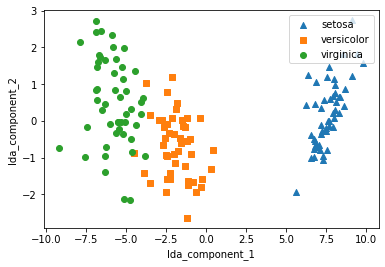

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

lda_columns = ['lda_component_1', 'lda_component_2']
irisdf_lda = pd.DataFrame(iris_lda, columns = lda_columns)
irisdf_lda['target'] = iris.target

# setosa는 세모, versicolor는 네모, virginica는 동그라미
markers = ['^', 's', 'o']

# setosa의 target 값은 0, versicolor는 1, virginicaSMS 2. 각 target 별로 다른 모양으로 산점도 표시
for i, marker in enumerate(markers):
  x_axis_data = irisdf_lda[irisdf_lda['target'] == i]['lda_component_1']
  y_axis_data = irisdf_lda[irisdf_lda['target'] == i]['lda_component_2']

  plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])

plt.legend(loc = 'upper right')
plt.xlabel('lda_component_1')
plt.ylabel('lda_component_2')
plt.show()

## 3. SVD(Singular Value Decomposition)

SVD도 PCA와 유사한 행렬 분해 기법을 이용함
- PCA의 경우 정방행렬(행과 열의 크기가 같은 행렬)만을 고유 벡터로 분해할 수 있었음
- SVD는 정방행렬 뿐만 아니라 행과 열의 크기가 다른 행렬에도 적용할 수 있음

SVD는 특이값 분해로 불리며 모든 특이 벡터는 서로 직교하는 성질을 가짐

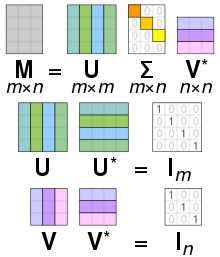

In [ ]:
# 넘파이의 svd 모듈 임포트
import numpy as np
from numpy.linalg import svd

# 4x4 랜덤 행렬 a 생성
np.random.seed(121)
a = np.random.randn(4, 4)
a

array([[-0.21203317, -0.28492917, -0.57389821, -0.44031017],
       [-0.33011056,  1.18369457,  1.61537293,  0.36706247],
       [-0.01411931,  0.6296418 ,  1.70964074, -1.32698736],
       [ 0.40187312, -0.19142667,  1.40382596, -1.96876855]])

In [ ]:
U, Sigma, Vt = svd(a)
print(U)
print(Sigma)
print(Vt)

[[-0.07913928 -0.31822729  0.86653217  0.37628494]
 [ 0.38294523  0.78655287  0.12002097  0.46934262]
 [ 0.65640669  0.02243181  0.35668848 -0.66437971]
 [ 0.64515128 -0.52873697 -0.32785711  0.44353889]]
[3.4229581  2.02287339 0.46263157 0.07935069]
[[ 0.04100747  0.22367823  0.78643002 -0.57429458]
 [-0.20019867  0.56209596  0.37041464  0.71187191]
 [-0.77847455  0.3945136  -0.33259252 -0.3573774 ]
 [-0.5934781  -0.69164673  0.36565426  0.18895901]]


In [ ]:
# sigma를 다시 0을 포함한 대칭행렬로 반환
Sigma_mat = np.diag(Sigma)
a_ = np.dot(np.dot(U, Sigma_mat), Vt)
print(a_)

[[-0.21203317 -0.28492917 -0.57389821 -0.44031017]
 [-0.33011056  1.18369457  1.61537293  0.36706247]
 [-0.01411931  0.6296418   1.70964074 -1.32698736]
 [ 0.40187312 -0.19142667  1.40382596 -1.96876855]]


- 분해된 U, Sigma, Vt는 다시 원본 행렬로 정확히 복원 가능함

In [ ]:
import numpy as np
from scipy.sparse.linalg import svds
from scipy.linalg import svd

# 원본 행렬을 출력하고 SVD를 적용할 경우, U, Sigma, Vt의 차원 확인
np.random.seed(121)
matrix = np.random.random((6, 6))
print('원본 행렬 :\n', matrix)
U, Sigma, Vt = svd(matrix, full_matrices = False)
print('\n분해 행렬 차원 : ', U.shape, Sigma.shape, Vt.shape)
print('\nSigma값 : ', Sigma)

# Truncated SVD로 Sigma 행렬의 특이값을 4개로 하여 Truncated SVD 수행
num_components = 4
U_tr, Sigma_tr, Vt_tr = svds(matrix, k = num_components)
print('\nTruncated SVD 분해 행렬 차원:', U_tr.shape, Sigma_tr.shape, Vt_tr.shape)
print('\nTruncated SVD Sigma값 행렬:', Sigma_tr)
matrix_tr = np.dot(np.dot(U_tr, np.diag(Sigma_tr)), Vt_tr) # Output of TruncatedSVD

print('\nTruncated SVD로 분해 후 복원 행렬:\n', matrix_tr)

원본 행렬 :
 [[0.11133083 0.21076757 0.23296249 0.15194456 0.83017814 0.40791941]
 [0.5557906  0.74552394 0.24849976 0.9686594  0.95268418 0.48984885]
 [0.01829731 0.85760612 0.40493829 0.62247394 0.29537149 0.92958852]
 [0.4056155  0.56730065 0.24575605 0.22573721 0.03827786 0.58098021]
 [0.82925331 0.77326256 0.94693849 0.73632338 0.67328275 0.74517176]
 [0.51161442 0.46920965 0.6439515  0.82081228 0.14548493 0.01806415]]

분해 행렬 차원 :  (6, 6) (6,) (6, 6)

Sigma값 :  [3.2535007  0.88116505 0.83865238 0.55463089 0.35834824 0.0349925 ]

Truncated SVD 분해 행렬 차원: (6, 4) (4,) (4, 6)

Truncated SVD Sigma값 행렬: [0.55463089 0.83865238 0.88116505 3.2535007 ]

Truncated SVD로 분해 후 복원 행렬:
 [[0.19222941 0.21792946 0.15951023 0.14084013 0.81641405 0.42533093]
 [0.44874275 0.72204422 0.34594106 0.99148577 0.96866325 0.4754868 ]
 [0.12656662 0.88860729 0.30625735 0.59517439 0.28036734 0.93961948]
 [0.23989012 0.51026588 0.39697353 0.27308905 0.05971563 0.57156395]
 [0.83806144 0.78847467 0.93868685 0.7267323

### Truncated SVD

In [ ]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
X_scaled = StandardScaler().fit_transform(X)

tsvd = TruncatedSVD(n_components = 2)
iris_tsvd = tsvd.fit_transform(X_scaled)
iris_tsvd

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

Text(0, 0.5, 'TruncatedSVD Component 2')

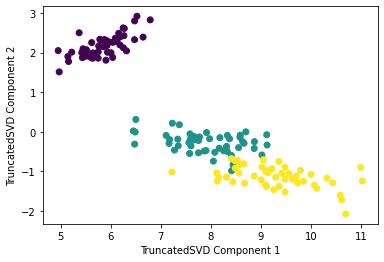

In [ ]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_ftrs = iris.data

tsvd = TruncatedSVD(n_components = 2)
tsvd.fit(iris_ftrs)
iris_tsvd = tsvd.transform(iris_ftrs)

plt.scatter(x = iris_tsvd[:, 0], y = iris_tsvd[:, 1], c = iris.target)
plt.xlabel('TruncatedSVD Component 1')
plt.ylabel('TruncatedSVD Component 2')

Text(0.5, 1.0, 'PCA Transformed')

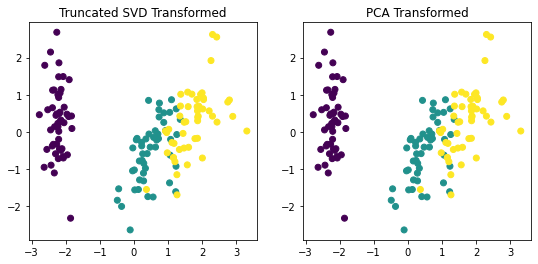

In [ ]:
from sklearn.preprocessing import StandardScaler

# 붓꽃 데이터를 StandardScaler로 변환
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_ftrs)

# 스케일링된 데이터를 기반으로 TruncatedSVD 변환 수행
tsvd = TruncatedSVD(n_components = 2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

# 스케일링 된 데이터를 기반으로 PCA 변환 수행
pca = PCA(n_components = 2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

# TruncatedSVD 변환 데이터를 왼쪽에, PCA 변환 데이터를 오른쪽에 표현
fig, (ax1, ax2) = plt.subplots(figsize = (9, 4), ncols = 2)
ax1.scatter(x = iris_tsvd[:, 0], y = iris_tsvd[:, 1], c = iris.target)
ax2.scatter(x = iris_pca[:, 0], y = iris_pca[:, 1], c = iris.target)
ax1.set_title('Truncated SVD Transformed')
ax2.set_title('PCA Transformed')

- 두 개의 변환 행렬 값과 원복 속성별 컴포넌트 비율값을 실제로 서로 비교해보면 거의 같음을 알 수 있음

In [ ]:
print((iris_pca - iris_tsvd).mean())
print((pca.components_ - tsvd.components_).mean())

2.3577494123738775e-15
7.632783294297951e-17


- 모두 0에 가까운 값이므로 2개의 변환이 서로 동일함을 알 수 있음
- 즉, 데이터 세트가 스케일링으로 데이터 중심이 동일해지면 사이킷런 SVD와 PCA는 동일한 변환을 수행함

## 4. NMF(Non-Negative Matrix Factorization)

- NMF는 Truncated SVD와 같이 낮은 랭크를 통한 행렬 근사(Low-Rank Approximation) 방식의 변형임
- NMF는 원본 행렬 내의 모든 원소 값이 모두 양수(0 이상)라는 게 보장되면 좀 더 간단하게 두 개의 기반 양수 행렬로 분해될 수 있는 기법을 지칭함


/usr/local/lib/python3.7/dist-packages/sklearn/decomposition/_nmf.py:294: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/decomposition/_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  ConvergenceWarning,


Text(0, 0.5, 'NMF Component 2')

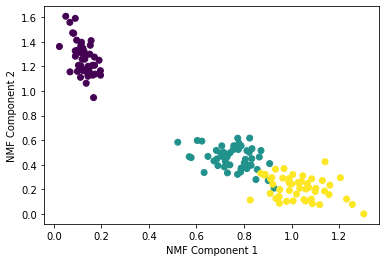

In [ ]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_ftrs = iris.data

nmf = NMF(n_components = 2)
nmf.fit(iris_ftrs)
iris_nmf = nmf.transform(iris_ftrs)

plt.scatter(x = iris_nmf[:, 0], y = iris_nmf[:, 1], c = iris.target)
plt.xlabel('NMF Component 1')
plt.ylabel('NMF Component 2')

- NMF도 SVD와 유사하게 이미지 압축을 통한 패턴 인식, 텍스트의 토픽 모델링 기법, 문서 유사도 및 클러스터링에 잘 사용됨
- 영화 추천과 같은 추천 영역에 활발하게 사용됨

# [6] 군집화

## 1. K-평균 알고리즘 이해

K-평균은 군집화(Clustering)에서 가장 일반적으로 사용되는 알고리즘

K-평균은 군집 중심점(centroid)이라는 특정한 지점을 선택해 해당 중심에 가까운 포인트를 선택하는 군집화 기법

- 군집 중심점은 선택된 포인트의 평균 지점으로 이동하고 이동된 중심점에서 다시 가까운 포인트를 선택,
- 다시 중심점을 평균 지점으로 이동하는 프로세스를 반복적으로 수행함
- 모든 데이터 포인트에서 더 이상 중심점의 이동이 없을 경우에 반복을 멈추고 해당 중심점에 속하는 데이터
포인트들을 군집화하는 기법

> 1. 먼저 군집화의 기준이 되는 중심을 구성하려는 군집화 개수만큼 임의의 위치에 가져다 놓기
> 2. 각 데이터는 가장 가까운 곳에 위치한 중심점에 소속됨.
> 3. 소속이 결정되면 군집 중심점을 소속된 데이터의 평균 중심으로 이동
> 4. 중심점이 이동했기 때문에 각 데이터는 기존에 속한 중심점보다 더 가까운 중심점이 있다면 해당 중심점으로 다시 소속을 변경
> 5. 다시 중심을 소속된 데이터의 평균 중심으로 이동
> 6. 중심점을 이동했는데 데이터의 중심점 소속 변경이 없으면 군집화를 종료. 그렇지 않다면 다시 4번 과정을 거쳐서 소속을 변경하고 이 과정을 반복

k-평균의 장점

> - 일반적인 군집화에서 가장 많이 활용되는 알고리즘
> - 알고리즘이 쉽고 간결함

k-평균의 단점

> - 거리 기반 알고리즘으로 속성의 개수가 매우 많을 경우 군집화 정확도가 떨어짐(이를 위해 pca로 차원 감소 적용해야 할 수 있음)
> - 반복을 수행하는데, 반복 횟수가 많을 경우 수행 시간이 느려짐
> - 몇 개의 군집을 선책해야할 지 가이드하기 어려움

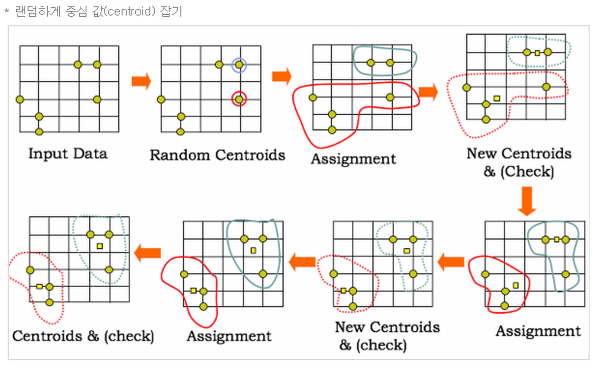

### 사이킷런 KMeans 클래스 소개

In [ ]:
## KMeans 클래스는 다음과 같은 초기화 파라미터를 가지고 있음
class sklearn.cluster.Kmenas(n_cluster = 9, init = 'k-means++', n_init = 10, max_iter = 300,
                            tol = 0.0001, precompute_distances = 'auto', verbose = 0,
                             random_state = None, copy_x = True, n_jobs = 1, algorithm = 'auto')

중요한 파라미터는 다음과 같음

> - KMeans 초기화 파라미터 중 가장 중요한 파라미터는 n_cluster : 군집화 할 개수, 즉 군집 중심점의 개수 의미
> - init : 초기에 군집 중심점의 좌표를 설정할 방식을 말하면 보통 k-means++임
> - max_inter : 최대 반복 횟수, 이 회수 이전에 모든 데이터 중심점 이동이 없으면 종료됨

KMeans도 fit(데이터 세트) 또는 fit_transform(데이터세트) 메서드를 이용해 수행하면 됨
> - labels_ : 각 데이터 포인트가 속한 군집 중심점 레이블
> - cluster_centers : 각 군집 중심점 좌표(Shape는 [군집 개수, 피처 개수])로 시각화도 가능함

### K평균을 이용한 붓꽃 데이터 세트 군집화

In [ ]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()

iris_df = pd.DataFrame(data = iris.data, columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

iris_df[:5]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)
kmeans.fit(iris_df)

kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

- target과 군집화 분류값인 cluster 값 개수 비교

In [ ]:
iris_df['target'] = iris.target
iris_df['cluster'] = kmeans.labels_

iris_result = iris_df.groupby(['target', 'cluster'])['sepal_length'].count()
iris_result

target  cluster
0       1          50
1       0          48
        2           2
2       0          14
        2          36
Name: sepal_length, dtype: int64

- 붓꽃 데이터 세트의 군집화를 시각화하려고 함
- 붓꽃 데이터 세트의 속성은 4개인데 2차원 평면에는 적합하지 않음
- PCA를 이용해 4개의 속성을 2개로 차원 축소한 뒤, X좌표와 Y좌표로 개별 데이터 표현하기

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_transformed = pca.fit_transform(iris.data)

iris_df['pca_x'] = pca_transformed[:, 0]
iris_df['pca_y'] = pca_transformed[:, 1]
iris_df[:3]

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


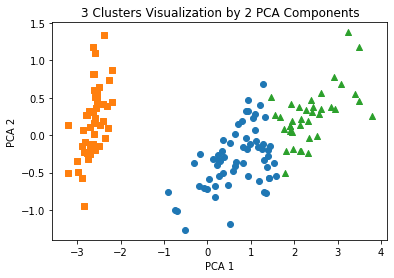

In [ ]:
# 군집값이 0, 1, 2인 경우마다 별도의 인덱스 추출
marker0_ind = iris_df[iris_df['cluster'] == 0].index
marker1_ind = iris_df[iris_df['cluster'] == 1].index
marker2_ind = iris_df[iris_df['cluster'] == 2].index

# 군집값 0, 1, 2에 해당하는 인덱스로 각 군집 레빌의 pca_x, pca_y 값 추출. o, s, ^로 마커 표시
plt.scatter(x = iris_df.loc[marker0_ind, 'pca_x'], y = iris_df.loc[marker0_ind, 'pca_y'], marker = 'o')
plt.scatter(x = iris_df.loc[marker1_ind, 'pca_x'], y = iris_df.loc[marker1_ind, 'pca_y'], marker = 's')
plt.scatter(x = iris_df.loc[marker2_ind, 'pca_x'], y = iris_df.loc[marker2_ind, 'pca_y'], marker = '^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

In [ ]:
####################################################################

In [ ]:
### 수업에서의 K-means Clustering
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [ ]:
iris = load_iris()

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)

kmeans.fit(iris.data)

KMeans(n_clusters=3, random_state=0)

In [ ]:
iris.data.shape

(150, 4)

In [ ]:
kmeans.labels_   ### 4개의 변수로 구성된 data들을 군집한 것!

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [ ]:
# 변수의 개수를 줄여도 군집을 잘 할까?
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
iris.data_pca = pca.fit_transform(iris.data)
iris.data_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)

kmeans.fit(iris.data_pca)
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

- 군집 성능 조금 떨어짐

### 군집화 알고리즘 테스트를 위한 데이터 생성
make_blobs()

- make_blobs()를 호출하면 피처 데이터 세트와 타깃 데이터 세트가 튜플(Tuple)로 반환됨

파라미터

- n_samples : 생성할 총 데이터 개수
- n_features : 데이터의 피처 개수
- centers : int값일 때에는 군집의 개수, ndarray 형태일 때는 개별 군집 중심점의 좌표를 의미
- cluster_std : 생성될 군집 데이터의 표준 편차를 의미


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)
print(X.shape, y.shape)

unique, counts = np.unique(y, return_counts = True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


## 2. 군집 평가(Cluster Evaluation)

- 비지도 학습의 특성상 어떠한 지표라도 정확하게 성능을 평가하기 어려움
- 그럼에도 불구하고 군집화 성능을 평가하는 대표적인 방법으로 실루엣 분석 이용


### 실루엣 분석

실루엣 분석은 각 군집 간의 거리가 얼마나 효율적으로 분리돼 있는지를 나타냄

효율적으로 잘 분리됐다는 것은 다른 군집과의 거리는 떨어져있고 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐 있다는 의미임

군집화가 잘 될수록 개별 군집은 비슷한 정도의 여유공간을 가지고 떨어져 있을 것임

실루엣 분석은 실루엣 계수를 기반으로 함
- 실루엣 계수는 개별 데이터가 가지는 군집화 지표임
- 개별 데이터가 가지는 셀루엣 계수는 해당 데이터가 같은 군집 내의 데이터와 얼마나 가깝게 군집화돼있고, 다른 군집에 있는 데이터와는 얼마나 멀리 분리돼 있는 지를 나타내는 지표임

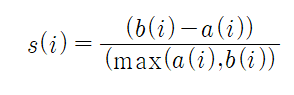

- a(i) : 해당 데이터 포인트와 같은 군집 내에 있는 다른 데이터 포인트와의 거리를 평균한 값
- b(i) : 해당 데이터 포인트가 속하지 않은 군집 중 가장 가까운 군집과의 평균 거리
- b(i) - a(i) : 두 군집 간의 거리가 얼마나 떨어져 있는 가이며,
- 이 값을 정규화하기 위해 MAX(a(i), b(i)) 값으로 나눔

- 실수엣 계수는 -1에서 1 사이의 값을 가지며,
- 1로 가까워질수록 근처의 군집과 더 멀리 떨어져 있다는 것이고
- 0에 가까울수록 근처의 군집과 가까워진다는 것임
- -값은 아예 다른 군집에 데이터 포인트가 할당됐다는 뜻

사이킷런은 실루엣 분석 메서드를 제공함


- sklearn.metrics.silhouette_samples(X, labels, metric = 'euclidean', **kwds)
> - 실루엣 계수 반환


- sklearn.metrics.silhouette_score(X, labels, metric = 'euclidean', sample_size = None, **kwds)
>  - 전체 데이터의 실루엣 계수 값을 평균해 반환
>  - 일반적으로 이 값이 높을수록 군집화가 잘 됐다고 판단할 수 있음
>  - 하지만 군집화는 정답이 있는 것이 아니므로 무조건 군집화가 잘 됐다고 판단하면 안됨


### 실루엣 계수 구하기

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score

iris = load_iris()

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)
kmeans.fit(iris.data)

KMeans(n_clusters=3, random_state=0)

In [ ]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [ ]:
# iris의 모든 개별 데이터에 실루엣 계수 값을 구함
silhouette_score(iris.data, kmeans.labels_)

0.5528190123564095

In [ ]:
silhouette_samples(iris.data, kmeans.labels_)

array([0.85295506, 0.81549476, 0.8293151 , 0.80501395, 0.8493016 ,
       0.74828037, 0.82165093, 0.85390505, 0.75215011, 0.825294  ,
       0.80310303, 0.83591262, 0.81056389, 0.74615046, 0.70259371,
       0.64377156, 0.77568391, 0.85101831, 0.70685782, 0.82030124,
       0.78418399, 0.82590584, 0.79297218, 0.7941134 , 0.77503635,
       0.79865509, 0.83346695, 0.84201773, 0.84364429, 0.81784646,
       0.81518962, 0.79899235, 0.76272528, 0.72224615, 0.82877171,
       0.83224831, 0.79415322, 0.84188954, 0.76856774, 0.85033231,
       0.84941579, 0.63900017, 0.78657771, 0.80023815, 0.74698726,
       0.80977534, 0.81340268, 0.81902059, 0.8182324 , 0.85209835,
       0.02672203, 0.38118643, 0.05340075, 0.59294381, 0.36885321,
       0.59221025, 0.28232583, 0.26525405, 0.34419223, 0.57829491,
       0.37478707, 0.58710354, 0.55107857, 0.48216686, 0.56310057,
       0.32459291, 0.55751057, 0.61072967, 0.46149897, 0.6115753 ,
       0.32909528, 0.58968904, 0.31046301, 0.49424779, 0.50004

### 군집화 알고리즘 테스트를 위한 데이터 생성

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)
print(X.shape, y.shape)
print(X[:5])
print(y)

(200, 2) (200,)
[[-1.69242695  3.62202539]
 [ 0.69794036  4.4288665 ]
 [ 1.10022802  4.60631734]
 [-1.44872404  3.38424521]
 [ 1.21486062  5.36489604]]
[2 0 0 2 0 2 1 1 0 2 0 2 0 0 0 2 1 1 0 2 2 1 0 0 2 0 1 2 2 2 0 0 2 0 1 1 0
 1 1 2 1 2 2 2 0 0 0 2 0 0 0 1 2 2 2 2 1 1 0 0 2 2 0 1 1 2 1 1 2 1 1 0 0 2
 0 2 1 1 1 2 2 0 0 1 1 0 0 2 0 1 2 2 1 0 1 0 0 2 2 1 1 0 2 0 2 0 1 0 0 1 0
 2 1 2 0 0 0 1 2 2 1 1 2 0 1 0 2 1 2 0 2 1 1 1 0 1 1 0 1 2 2 2 0 1 1 0 2 2
 1 0 1 2 2 2 0 1 1 1 0 0 2 2 2 2 0 0 1 2 1 1 0 1 0 1 2 2 0 2 0 1 0 2 1 1 1
 0 2 1 0 0 2 2 1 1 1 1 2 1 0 1]


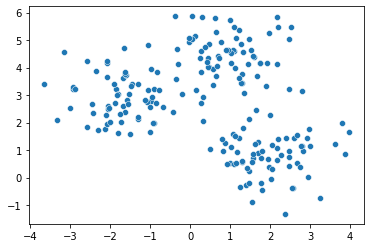

In [ ]:
import seaborn as sns

sns.scatterplot(x = X[:, 0], y = X[:, 1])

In [ ]:
unique, counts = np.unique(y, return_counts = True)
print(unique, counts)

[0 1 2] [67 67 66]


In [ ]:
kmeans = KMeans(n_clusters  = 3, init = 'k-means++', max_iter = 300, random_state = 0)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=0)

In [ ]:
kmeans.labels_

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 1, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2], dtype=int32)

In [ ]:
y

array([2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 1,
       0, 0, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 1, 2, 2, 2,
       0, 0, 0, 2, 0, 0, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       1, 1, 2, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 0, 2,
       0, 1, 2, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1,
       0, 2, 1, 2, 0, 0, 0, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 1,
       1, 1, 0, 1, 1, 0, 1, 2, 2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 2, 2, 2,
       0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0, 1, 0, 1, 2, 2,
       0, 2, 0, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 1, 2, 1,
       0, 1])

In [ ]:
kmeans.fit_predict(X)

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 1, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2], dtype=int32)

In [ ]:
## 200개의 데이터가 각각 몇 번 군집으로 할당되었는지 나타내기
kmeans.labels_

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 1, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2], dtype=int32)

In [ ]:
for i, x in enumerate(y):
    if y[i] == 1:
        y[i] = 2
    elif y[i] == 2:
        y[i] = 1
y

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 0, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2])

In [ ]:
kmeans.labels_

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 1, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2], dtype=int32)

In [ ]:
## y와 label하고 비교해서 몇 개나 같은지 나타내기
kmeans.labels_ == y

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

## 3. 평균 이동

- 평균 이동(Mean Shift)은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행
- K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해,
- 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킴

- 평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾음
- 군집 중심점은 데이터 포인트가 모여있는 곳이라는 생각에서 착안한 것이며 이를 위해 확률 밀도 함수를 이용함
- 가장 집중적으로 데이터가 모여있어 확률 밀도 함수가 피크인 점을 군집 중심점으로 선정하며 일반적으로 주인 모델의 확률 밀도 함수를 찾기 위해서 KDE(Kernel Density Estimation)을 이용함

- 평균 이동 군집화는 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위해 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식을 취함
- 이러한 방식을 전체 데이터에 반복적으로 적용하면서 데이터의 군집 중심점을 찾아냄

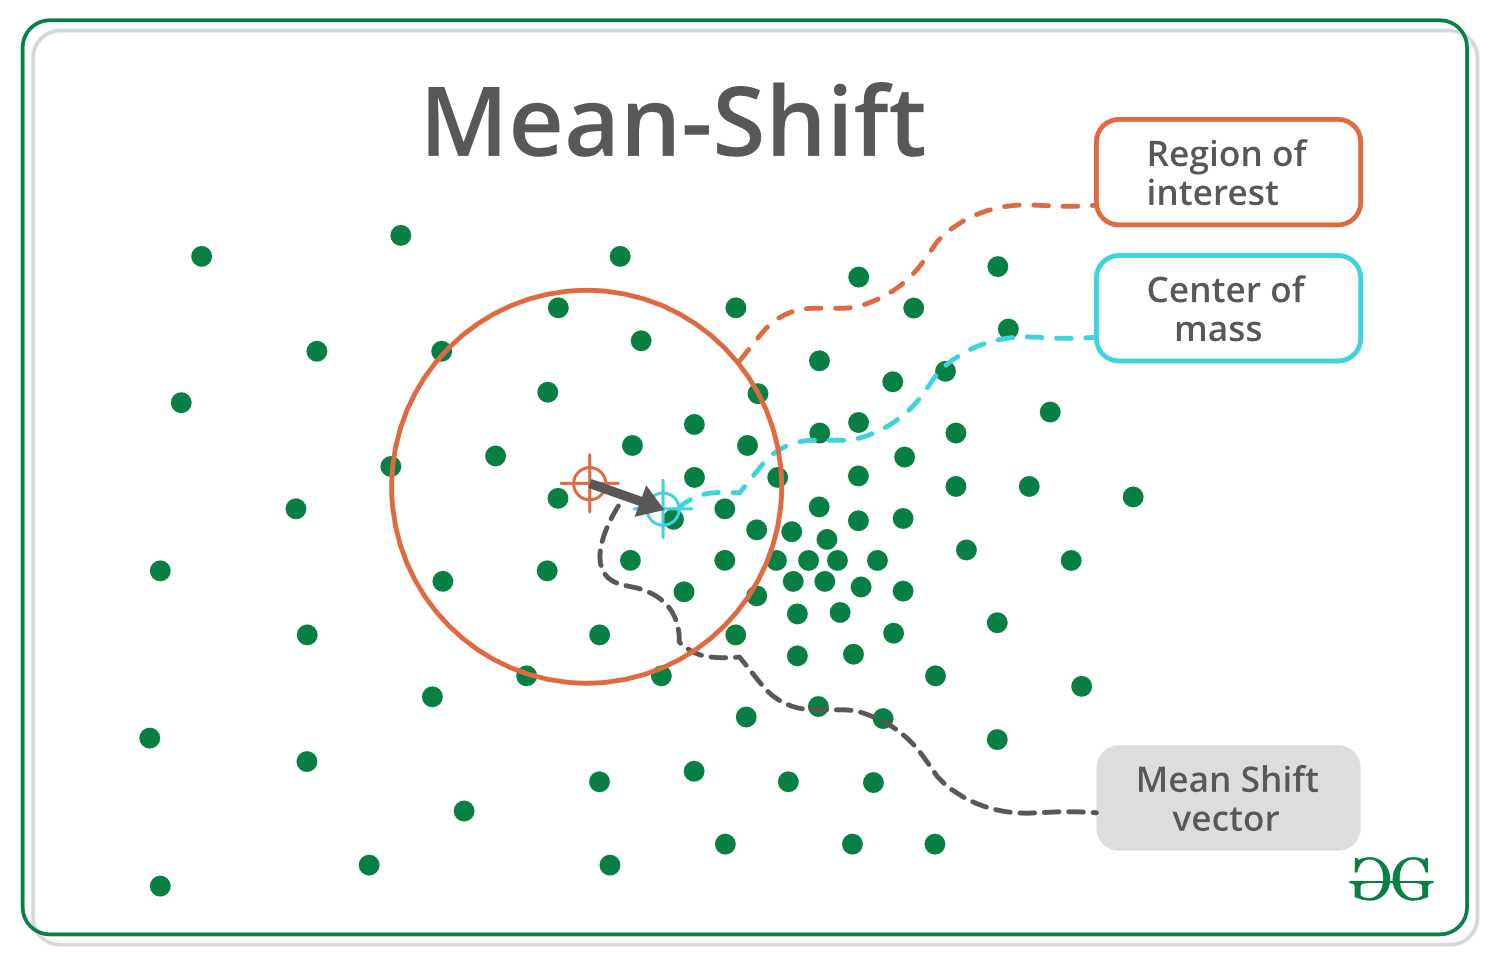

- KDE(Kernel Density Estimation)는 커널 함수를 통해 어떤 변수의 확률 밀도 함수를 추정하는 대표적인 방법임
- 확률 밀도 함수 PDF(Probability Density Function)는 확률 변수의 분포를 나타내는 함수로, 널리 알려진 정규 분포 함수를 포함해 감마 분포, t-분포 등이 있음

- KDE는 개별 관측 데이터에 커널 함수를 적용한 뒤, 이 적용값을 모두 더한 후 개별 관측 데이터의 건수로 나눠 확률 밀도 함수를 추정하며, 대표적인 커널 함수로서 가우시안 분포 함수가 사용됨

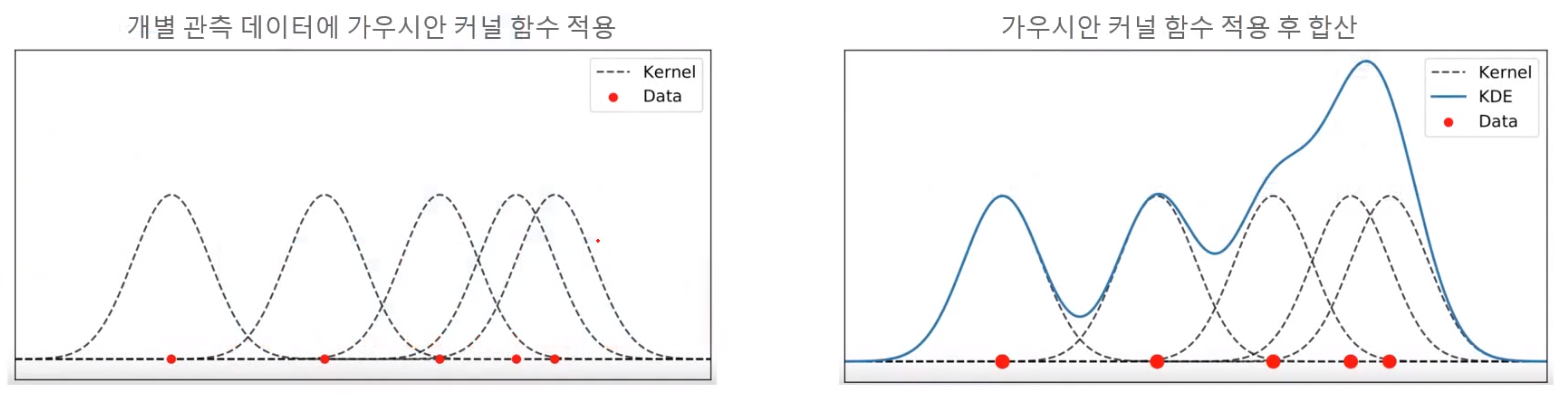

- 대역폭 h는 KDE 형태를 부드러운(또는 뾰족한) 형태로 평활화하는 데 적용되며, 이 h를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우할 수 있음
- 작은 h값은 좁고 뾰족한 KDE를 가지게 되며, 이는 변동성이 큰 방식으로 확률 밀도 함수를 추정하므로 과적합하기 쉬움
- 반대로 매우 큰 h 값은 과도하게 평활화 된 KDF로 인해 지나치게 단순화된 방식으로 확률 밀도 함수를 추정하며 결과적으로 과소 적합하기 쉬움
- 따라서 적절한 KDE의 대역폭 h를 계산하는 것은 KDE 기반의 평균 이동 군집화에서 매우 중요함

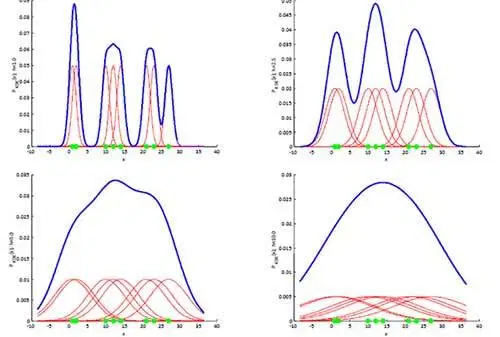

In [ ]:
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)

meanshift = MeanShift(bandwidth = 2)
meanshift.fit_predict(X)

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1])

In [ ]:
meanshift = MeanShift(bandwidth = 1)
meanshift.fit_predict(X)

array([1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 0, 2,
       0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1,
       0, 2, 2, 2, 0, 0, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 2])

- bandwidth 값의 변화는 군집화 개수에 큰 영향을 미칠 수 있음
- 따라서 MeanShift에서는 이 bandwidth를 최적화 값으로 설정하는 것이 매우 중요함
- 사이킷런은 최적화된 bandwidth 값을 찾기 위해 estimate_bandwidth()함수를 제공함

In [ ]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
bandwidth

2.0022669597980554

In [ ]:
import pandas as pd

clusterdf = pd.DataFrame(data = X, columns = ['ftr1', 'ftr2'])
clusterdf['target'] = y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth = best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
cluster_labels

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1])

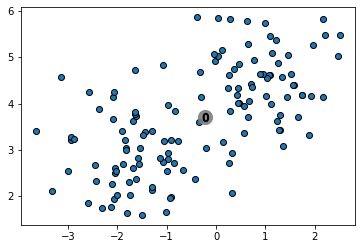

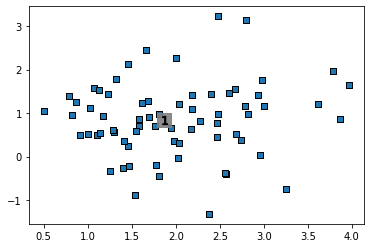

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterdf['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
  label_cluster = clusterdf[clusterdf['meanshift_label'] == label]
  center_x_y = centers[label]

  #군집별로 다른 마커로 산점도 적용
  plt.scatter(x = label_cluster['ftr1'], y = label_cluster['ftr2'], edgecolor = 'k', marker = markers[label])

  # 군집별 중심 표현
  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 200, color = 'gray', alpha = 0.9, marker = markers[label])
  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 70, color = 'k', edgecolor = 'k', marker = '$%d$' % label)
  plt.show()

In [ ]:
print(clusterdf.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  65
        1                   2
1       1                  67
2       0                  66
Name: meanshift_label, dtype: int64


- 평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정한다든가, 특정 분포도 기반의 모델로 가정하기 않기 때문에 좀 더 유연한 군집화가 가능하다는 것임
- 또한 이상치의 영향력도 크지 않으며, 미리 문집의 개수를 정할 필요도 없음
- 하지만 알고리즘의 수행 시간이 오래 걸리고 무엇보다도 bandwidth의 크기에 따라 군집화 영향도가 매우 큼
- 이 같은 특징 때문에 일반적으로 평균 이동 군집화 기법은 분석 업무 기반의 데이터 세트보다는 컴퓨터 비전 영역에서 더 많이 사용됨
- 이미지나 영상 데이터에서 특정 개체를 구분하거나 움직임을 추적하는 데 뛰어난 역할을 수행하는 알고리즘임

## 4. GMM(Gaussian Mixture Model)

- GMM(Gaussian Mixture Model) 군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정 하에 군집화를 수행하는 방식임
- 정규 분포로도 알려진 가우시안 분포는 좌우 대칭형의 종 형태를 가진 연속 확률 함수임

- GMM은 데이터를 여러 개의 가우시간 분포가 섞인 것으로 간주함
- 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출함

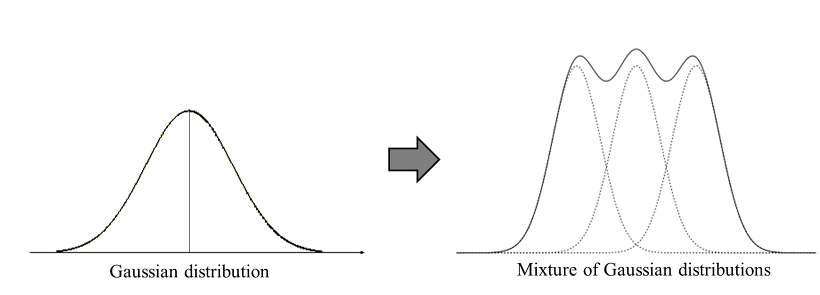

- 전체 데이터 세트는 서로 다른 정규 분포 형태를 가진 여러 가지 확률 분포 곡선으로 구성될 수 있으며 이러한 서로 다른 정규 분포에 기반해 군집화를 수행하는 것이 GMM 군집화 방식임
- 가령 1000개의 데이터 세트가 있다면 이를 구성하는 여러 개의 정규 분포 곡선을 추출하고, 개별 데이터가 이 중 어떤 정규 분포에 속하는 지 결정하는 방식임
- 이와 같은 방식은 GMM에서는 모수 추정이라고 하는데, 모수 추정은 대표적으로 2가지를 추정하는 것임
> - 개별 정규 분포의 평균과 분산
> - 각 데이터가 어떤 정규 분포에 해당하는지의 확률

- GMM은 모수 추정을 위해 EM(Expectation and Maximization) 방법을 적용함

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

gmm_cluster_labels

NameError: name 'iris' is not defined

### GMM을 이용한 붓꽃 데이터 세트 군집화

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

irisdf = pd.DataFrame(data = iris.data, columns = iris.feature_names)
irisdf['target'] = iris.target

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisdf의 'gmm_cluster' 칼럼명으로 저장
irisdf['gmm_cluster'] = gmm_cluster_labels
irisdf['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
iris_result = irisdf.groupby(['target'])['gmm_cluster'].value_counts()
iris_result

target  gmm_cluster
0       0              50
1       2              45
        1               5
2       1              50
Name: gmm_cluster, dtype: int64

In [ ]:
kmeans = KMeans(n_clusters=3, max_iter = 300, random_state = 0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisdf['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisdf.groupby(['target'])['kmeans_cluster'].value_counts()
iris_result

target  kmeans_cluster
0       1                 50
1       0                 48
        2                  2
2       2                 36
        0                 14
Name: kmeans_cluster, dtype: int64

- 붓꽃 데이터 세트는 GMM 군집화에 더 효과적임
- K-평균은 평균 거리 중심으로 중심을 이동하면서 군집화를 수행하는 방식이므로 개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화가 수행될 수 있음

### GMM과 K-평균의 비교

- KMeans는 원형의 범위에서 군집화를 수행함
- 데이터 세트가 원형의 범위를 가질수록 KMeans의 군집화 효율은 더욱 높아짐
- 데이터가 길쭉한 타원형으로 늘어선 경우 군집화를 잘 수행하지 못함

In [ ]:
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):

    # 군집별 중심 위치: K-Means, Mean Shift 등
    if iscenter:
        centers = clusterobj.cluster_centers_

    # Cluster 값 종류
    unique_labels = np.unique(dataframe[label_name].values)

    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        # 군집별 데이터 프레임
        label_cluster = dataframe[dataframe[label_name]==label]

        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else:
            cluster_legend = 'Cluster '+str(label)

        # 각 군집 시각화
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,
                    edgecolor='k', marker=markers[label], label=cluster_legend)

        # 군집별 중심 위치 시각화
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)

    if isNoise:
        legend_loc='upper center'
    else:
        legend_loc='upper right'

    plt.legend(loc=legend_loc)
    plt.show()

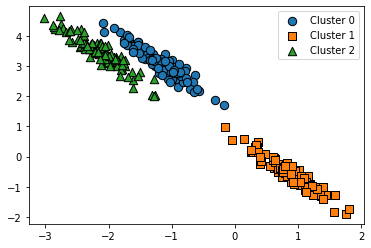

In [ ]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std = 0.5를 만듦
X, y = make_blobs(n_samples = 300, n_features = 2, centers = 3, cluster_std = 0.5, random_state = 0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)

# feature 데이터 세트와 make_blobs()의 y 결괏값을 DataFrame으로 저장
clusterdf = pd.DataFrame(data = X_aniso, columns = ['ftr1', 'ftr2'])
clusterdf['target'] = y

# 생성된 데이터 세트를 target별로 다른 마터로 표시해 시각화 함
visualize_cluster_plot(None, clusterdf, 'target', iscenter = False)

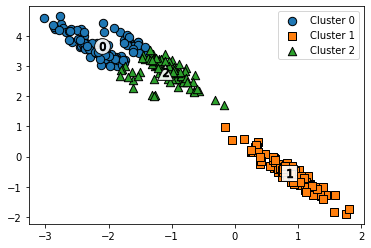

In [ ]:
# 3개의 군집 기반 Kmeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state = 0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterdf['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterdf, 'kmeans_label')

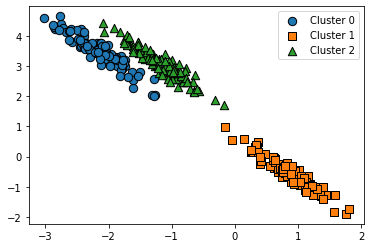

In [ ]:
# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components = 3, random_state = 0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterdf['gmm_label'] = gmm_label

visualize_cluster_plot(gmm, clusterdf, 'gmm_label', iscenter = False)

군집화 효율 비교

In [ ]:
print('### KMeans Clustering ###')
print(clusterdf.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterdf.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: kmeans_label, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: gmm_label, dtype: int64


- KMeans의 경우 군집 1번만 정확히 매핑됐지만, 나머지 군집의 경우 target 값과 어긋나는 경우가 발생함
- GMM의 경우 군집이 target과 잘 매핑됨
- GMM의 경우는 KMeans보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다는 장점이 있음

## 5. DBSCAN

- DBSCAN(Density Based Spatial Clustering of Applications with Noise) : 밀도 기반 군집화의 대표적인 알고리즘

- DBSCAN은 간단하고 직관적인 알고리즘으로 돼있음에도 데이터의 분포가 기하학적으로 복잡핮 데이터 세트에도 효과적으로 군집화가 가능함

- DBSCAN은 특정 공간 내에 데이터 밀도 차이를 기반 알고리즘으로 하고있어서 복잡한 기하학적 분포도를 가진 데이터 세트에 대해서도 군집화를 잘 수행함

DBSCAN을 구성하는 가장 중요한 두 가지
- 입실론 주변 영역(epsilon) : 개별 데이터를 중심으로 입실론 반경을 가지는 원형의 영역
- 최소 데이터 개수(min points) : 개별 데이터의 입실론 주변 영역에 포함되는 타 데이터의 개수

입실론 주변 영역 내에 포함되는 최소 데이터 개수를 충족시키는가 아닌가에 따라 데이터 포인트를 다음과 같이 정의함

- 핵심 포인트(Core Point) : 주변 영역 내에 최소 데이터 개수 이상의 타 데이터를 가지고 있을 경우 해당 데이터를 핵심 포인트라고 함
- 이웃 포인트(Neighbor Point) : 주변 영역 내에 위치한 타 데이터
- 경계 포인트(Border Point) : 주변 영역 내에 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않지만 핵심 포인트를 이웃 포인트로 가지고 있는 데이터
- 잡음 포인트(Noise Point) : 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않으며, 핵심 포인트도 이웃 포인트로 가지고 있지 않는 데이터

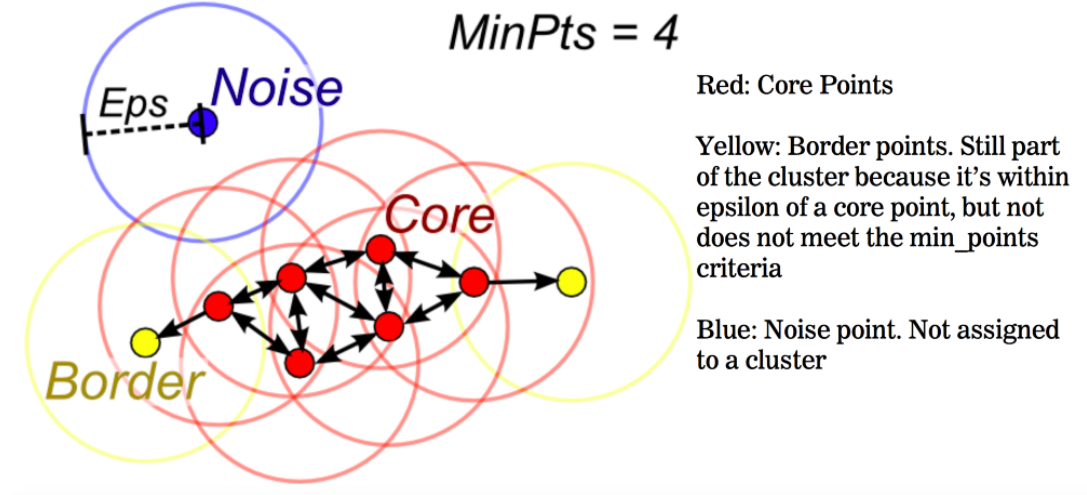

### DBSCAN 적용하기 - 붓꽃 데이터 세트

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

irisdf = pd.DataFrame(data = iris.data, columns = iris.feature_names)
irisdf['target'] = iris.target

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.6, min_samples = 8, metric = 'euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisdf['dbscan_cluster'] = dbscan_labels
irisdf['target'] = iris.target

iris_result = irisdf.groupby(['target'])['dbscan_cluster'].value_counts()
iris_result

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: dbscan_cluster, dtype: int64

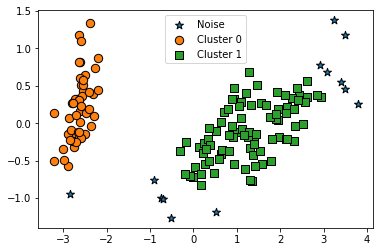

In [ ]:
from sklearn.decomposition import PCA

# 2차원으로 시각화하기 위해 PCA n_components = 2로 피처 데이터 세트 변환
pca = PCA(n_components = 2, random_state = 0)
pca_transformed = pca.fit_transform(iris.data)

# visualize_cluster_2d() 함수는 ftr1, ftr2 칼럼을 좌표에 표현하므로 PCA 변환값을 해당 칼럼으로 생성
irisdf['ftr1'] = pca_transformed[:, 0]
irisdf['ftr2'] = pca_transformed[:, 1]

visualize_cluster_plot(dbscan, irisdf, 'dbscan_cluster', iscenter = False)

- 별로 표현된 값은 모두 노이즈임
- eps를 기존의 0.6에서 0.8로 증가시키면 노이즈 데이터 수가 줄어듦

### DBSCAN 적용하기 - make_circles() 데이터 세트

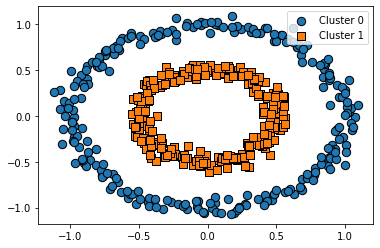

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 500, shuffle = True, noise = 0.05, random_state = 0, factor = 0.5)
clusterdf = pd.DataFrame(data = X, columns = ['ftr1', 'ftr2'])
clusterdf['target'] = y

visualize_cluster_plot(None, clusterdf, 'target', iscenter = False)

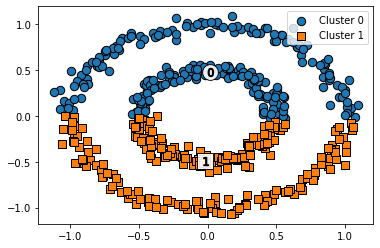

In [ ]:
# KMeans로 make_circles() 데이터 세트 군집화 수행
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, max_iter = 1000, random_state = 0)
kmeans_labels = kmeans.fit_predict(X)
clusterdf['kmeans_cluster'] = kmeans_labels

visualize_cluster_plot(kmeans, clusterdf, 'kmeans_cluster', iscenter = True)

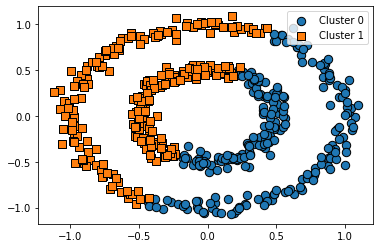

In [ ]:
# GMM로 make_circles() 데이터 세트 군집화 수행
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 2, random_state = 0)
gmm_labels = gmm.fit_predict(X)
clusterdf['gmm_cluster'] = gmm_labels

visualize_cluster_plot(gmm, clusterdf, 'gmm_cluster', iscenter = False)

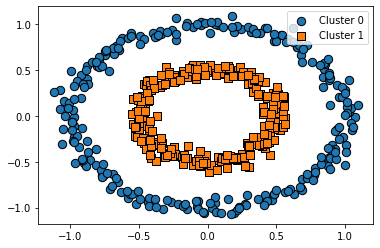

In [ ]:
# DBSCAN로 make_circles() 데이터 세트 군집화 수행
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.2, min_samples = 10, metric = 'euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterdf['dbscan_cluster'] = dbscan_labels

visualize_cluster_plot(dbscan, clusterdf, 'dbscan_cluster', iscenter = False)